## 2. Data Loading & Preprocessing

In [1]:
import pandas as pd

TRAIN_FILE = "data/train.csv"
TEST_FILE = "data/phase_1_test.csv"


df_train = pd.read_csv(TRAIN_FILE)
display(df_train.head())
print(f"✓ Loaded {len(df_train)} training samples")
print(f"Columns: {df_train.columns.tolist()}")
print(f"\nFirst sample:")
print(f"Question preview: {df_train['question'].iloc[0][:200]}...")
print(f"Answer: {df_train['answer'].iloc[0]}")
print(f"\nAnswer distribution:")
print(df_train['answer'].value_counts())

,ID,question,answer
0,ID_1P7PJMPV0R,Analyze the 5G wireless network drive-test use...,C2
1,ID_8B1D1TUTFA,Analyze the 5G wireless network drive-test use...,C1
2,ID_IGGXMA9GZH,Analyze the 5G wireless network drive-test use...,C2
3,ID_D6C9N2X295,Analyze the 5G wireless network drive-test use...,C2
4,ID_8JC15PNP3Q,Analyze the 5G wireless network drive-test use...,C5


✓ Loaded 2400 training samples
Columns: ['ID', 'question', 'answer']

First sample:
Question preview: Analyze the 5G wireless network drive-test user plane data and engineering parameters.
Identify the reason for the throughput dropping below 600Mbps in certain road sections.
From the following 8 pote...
Answer: C2

Answer distribution:
answer
C5    352
C7    349
C3    330
C2    320
C4    283
C8    277
C1    264
C6    225
Name: count, dtype: int64


## 📊 Enhanced Preprocessing with Type Safety & Feature Engineering

**Key Improvements:**
1. ✅ **Type casting** - Ensures all numeric fields are properly typed (not strings)
2. ✅ **Missing neighbor RSRP fields** - Now included in float casting
3. ✅ **Centralized field definitions** - Easy to maintain
4. ✅ **RCA-friendly features** - Computed automatically for better model learning

**Why This Matters:**
- Prevents "123.4" string vs 123.4 float bugs in calculations
- Ensures distance/ratio computations work correctly
- Makes feature engineering more reliable

In [2]:
import re
import json
import math
import pandas as pd
from statistics import mean, median, stdev
from typing import List, Dict, Any, Optional

# ============================================================================
# LABEL MAPPING
# ============================================================================
CAUSE_TO_NUM = {f"C{i}": i for i in range(1, 9)}
NUM_TO_CAUSE = {i: f"C{i}" for i in range(1, 9)}

# ============================================================================
# TYPE CONVERSION UTILITIES
# ============================================================================

def to_float(x) -> Optional[float]:
    """Safely convert to float, handling None, '-', and invalid values"""
    if x is None or x == "" or x == "-" or x == "—":
        return None
    try:
        return float(x)
    except (ValueError, TypeError):
        return None

def to_int(x) -> Optional[int]:
    """Safely convert to int, handling None, '-', and invalid values"""
    if x is None or x == "" or x == "-" or x == "—":
        return None
    try:
        return int(float(x))  # float first to handle "123.0" strings
    except (ValueError, TypeError):
        return None

def sanitize_question_text(q: str) -> str:
    """
    Convert literal '\\n' to real newlines.
    CRITICAL: Don't use unicode decoding or you corrupt '\\boxed'
    """
    if q is None:
        return ""
    return q.replace("\\n", "\n").replace("\r\n", "\n").replace("\r", "\n")

# ============================================================================
# DOMAIN-SPECIFIC CALCULATIONS
# ============================================================================

def haversine_m(lat1: float, lon1: float, lat2: float, lon2: float) -> float:
    """Calculate distance in meters between two lat/lon points"""
    R = 6371000.0  # Earth radius in meters
    phi1, phi2 = math.radians(lat1), math.radians(lat2)
    dphi = math.radians(lat2 - lat1)
    dlmb = math.radians(lon2 - lon1)
    a = math.sin(dphi/2)**2 + math.cos(phi1)*math.cos(phi2)*math.sin(dlmb/2)**2
    return 2 * R * math.asin(math.sqrt(a))

def beamwidth_deg(beam_scenario: str) -> int:
    """
    Map beam scenario to vertical beamwidth:
    - DEFAULT/SCENARIO_1-5: 6 degrees
    - SCENARIO_6-11: 12 degrees
    - SCENARIO_12+: 25 degrees
    """
    s = (beam_scenario or "").upper().strip()
    if s == "DEFAULT":
        return 6

    m = re.match(r"SCENARIO_(\d+)", s)
    if not m:
        return 6

    k = int(m.group(1))
    if 1 <= k <= 5:
        return 6
    elif 6 <= k <= 11:
        return 12
    else:  # 12+
        return 25

def electronic_tilt_deg(digital_tilt) -> float:
    """
    Convert digital tilt to degrees:
    - 255 => 6 degrees (special case)
    - Otherwise: value is degrees
    """
    try:
        v = int(float(digital_tilt))
        return 6.0 if v == 255 else float(v)
    except (ValueError, TypeError):
        return 6.0  # Default fallback

print("✓ Type conversion and domain utilities loaded")

✓ Type conversion and domain utilities loaded


In [3]:
# ============================================================================
# TABLE PARSING
# ============================================================================

def parse_pipe_table(table_text: str) -> List[Dict[str, Any]]:
    """
    Parse pipe-delimited table into list of dicts.
    Handles '-', '—', and empty values as None.
    """
    if not table_text:
        return []

    lines = [ln.strip() for ln in table_text.splitlines() if ln.strip()]
    lines = [ln for ln in lines if "|" in ln]

    if not lines:
        return []

    # Parse header
    header = [h.strip() for h in lines[0].split("|")]

    # Parse rows
    rows = []
    for ln in lines[1:]:
        parts = [p.strip() for p in ln.split("|")]

        # Normalize row length to match header
        if len(parts) < len(header):
            parts += [""] * (len(header) - len(parts))
        elif len(parts) > len(header):
            parts = parts[:len(header)]

        # Build record
        rec = {}
        for k, v in zip(header, parts):
            rec[k] = None if v in ("", "-", "—", "–") else v

        rows.append(rec)

    return rows

print("✓ Table parsing loaded")

✓ Table parsing loaded


In [4]:
# ============================================================================
# COLUMN MAPPING & TYPE CASTING (IMPROVED)
# ============================================================================

# Drive-test data column mappings
DRIVE_MAP = {
    "Timestamp": "timestamp",
    "Longitude": "longitude",
    "Latitude": "latitude",
    "GPS Speed (km/h)": "gps_speed_kmh",
    "5G KPI PCell RF Serving PCI": "serving_pci",
    "5G KPI PCell RF Serving SS-RSRP [dBm]": "ss_rsrp_dbm",
    "5G KPI PCell RF Serving SS-SINR [dB]": "ss_sinr_db",
    "5G KPI PCell Layer2 MAC DL Throughput [Mbps]": "throughput_mbps",
    "5G KPI PCell Layer1 DL RB Num (Including 0)": "dl_rb_num",

    # Neighbor PCIs
    "Measurement PCell Neighbor Cell Top Set(Cell Level) Top 1 PCI": "nei1_pci",
    "Measurement PCell Neighbor Cell Top Set(Cell Level) Top 2 PCI": "nei2_pci",
    "Measurement PCell Neighbor Cell Top Set(Cell Level) Top 3 PCI": "nei3_pci",
    "Measurement PCell Neighbor Cell Top Set(Cell Level) Top 4 PCI": "nei4_pci",
    "Measurement PCell Neighbor Cell Top Set(Cell Level) Top 5 PCI": "nei5_pci",

    # Neighbor RSRPs (CRITICAL - these were missing!)
    "Measurement PCell Neighbor Cell Top Set(Cell Level) Top 1 Filtered Tx BRSRP [dBm]": "nei1_rsrp_dbm",
    "Measurement PCell Neighbor Cell Top Set(Cell Level) Top 2 Filtered Tx BRSRP [dBm]": "nei2_rsrp_dbm",
    "Measurement PCell Neighbor Cell Top Set(Cell Level) Top 3 Filtered Tx BRSRP [dBm]": "nei3_rsrp_dbm",
    "Measurement PCell Neighbor Cell Top Set(Cell Level) Top 4 Filtered Tx BRSRP [dBm]": "nei4_rsrp_dbm",
    "Measurement PCell Neighbor Cell Top Set(Cell Level) Top 5 Filtered Tx BRSRP [dBm]": "nei5_rsrp_dbm",
}

# Engineering parameters column mappings
ENG_MAP = {
    "gNodeB ID": "gnodeb_id",
    "Cell ID": "cell_id",
    "Longitude": "longitude",
    "Latitude": "latitude",
    "Mechanical Azimuth": "mechanical_azimuth",
    "Mechanical Downtilt": "mechanical_downtilt",
    "Digital Tilt": "digital_tilt",
    "Digital Azimuth": "digital_azimuth",
    "Beam Scenario": "beam_scenario",
    "Height": "height",
    "PCI": "pci",
    "TxRx Mode": "txrx_mode",
    "Max Transmit Power": "max_tx_power",
    "Antenna Model": "antenna_model",
}

# Define fields by type for proper casting
FLOAT_FIELDS = [
    "longitude", "latitude", "gps_speed_kmh",
    "ss_rsrp_dbm", "ss_sinr_db", "throughput_mbps", "dl_rb_num",
    "mechanical_downtilt", "digital_tilt", "height", "max_tx_power",
    "mechanical_azimuth", "digital_azimuth",
    # CRITICAL: Add neighbor RSRP fields
    "nei1_rsrp_dbm", "nei2_rsrp_dbm", "nei3_rsrp_dbm",
    "nei4_rsrp_dbm", "nei5_rsrp_dbm",
]

INT_FIELDS = [
    "pci", "serving_pci",
    "nei1_pci", "nei2_pci", "nei3_pci", "nei4_pci", "nei5_pci",
]

def normalize_rows(rows: List[Dict], mapping: Dict[str, str]) -> List[Dict]:
    """
    Normalize column names and apply type casting.
    This ensures all numeric operations work correctly.
    """
    normalized = []

    for r in rows:
        nr = {}

        # Map column names
        for k, v in r.items():
            normalized_key = mapping.get(k)
            if normalized_key is None:
                continue  # Skip unmapped columns
            nr[normalized_key] = v

        # Type casting - CRITICAL for numeric operations
        for field in FLOAT_FIELDS:
            if field in nr:
                nr[field] = to_float(nr[field])

        for field in INT_FIELDS:
            if field in nr:
                nr[field] = to_int(nr[field])

        normalized.append(nr)

    return normalized

print("✓ Column mappings and type casting configured")
print(f"  - Float fields: {len(FLOAT_FIELDS)}")
print(f"  - Int fields: {len(INT_FIELDS)}")
print(f"  - Drive-test columns mapped: {len(DRIVE_MAP)}")
print(f"  - Engineering columns mapped: {len(ENG_MAP)}")

✓ Column mappings and type casting configured
  - Float fields: 18
  - Int fields: 7
  - Drive-test columns mapped: 19
  - Engineering columns mapped: 14


In [ ]:
# ============================================================================
# RCA-FRIENDLY FEATURE ENGINEERING
# ============================================================================

from typing import List, Dict, Any
import math
from statistics import mean, median, stdev

def compute_rca_features(drive_rows: List[Dict], eng_rows: List[Dict]) -> Dict[str, Any]:
    """
    Compute derived features that help the model learn root cause patterns.
    This is the KEY to good RCA performance!

    Returns dict with all computed features.

    NOTE: Per your request, NOTHING from your original function is removed.
    Only NEW features are appended (mostly stronger C4 discriminators).
    """
    features = {}

    # -------------------------------------------------------------------------
    # A) Throughput-drop signature (C8 indicator) + EFFICIENCY ANALYSIS (C3-A)
    # -------------------------------------------------------------------------
    tps = [r["throughput_mbps"] for r in drive_rows if r.get("throughput_mbps") is not None]

    if tps:
        features["tp_min_mbps"] = min(tps)
        features["tp_mean_mbps"] = mean(tps)
        features["tp_max_mbps"] = max(tps)
        features["tp_drop_ratio"] = sum(1 for x in tps if x < 600) / len(tps)
        features["tp_samples_below_600"] = sum(1 for x in tps if x < 600)
    else:
        features["tp_min_mbps"] = None
        features["tp_mean_mbps"] = None
        features["tp_max_mbps"] = None
        features["tp_drop_ratio"] = None
        features["tp_samples_below_600"] = 0

    # -------------------------------------------------------------------------
    # B) Resource constraint (C8) + EFFICIENCY (C3-A)
    # -------------------------------------------------------------------------
    rbs = [r["dl_rb_num"] for r in drive_rows if r.get("dl_rb_num") is not None]

    if rbs:
        features["rb_mean"] = mean(rbs)
        features["rb_min"] = min(rbs)
        features["rb_max"] = max(rbs)
        features["rb_below_160_flag"] = features["rb_mean"] < 160 if features["rb_mean"] else False
    else:
        features["rb_mean"] = None
        features["rb_min"] = None
        features["rb_max"] = None
        features["rb_below_160_flag"] = False
    
    # NEW: Throughput Efficiency Ratio (C3-A) - SERVING CELL
    # Efficiency = throughput per RB (accounts for scheduling/load)
    tp_rb_pairs = [(r.get("throughput_mbps"), r.get("dl_rb_num")) 
                   for r in drive_rows 
                   if r.get("throughput_mbps") is not None and r.get("dl_rb_num") is not None and r.get("dl_rb_num") > 0]
    
    if tp_rb_pairs:
        efficiencies = [tp / rb for tp, rb in tp_rb_pairs]
        features["throughput_efficiency_mbps_per_rb"] = mean(efficiencies)
        features["throughput_efficiency_min"] = min(efficiencies)
        features["throughput_efficiency_max"] = max(efficiencies)
        
        # Low efficiency despite RBs available suggests scheduling/load issue (C3 pattern)
        # Typical good efficiency: ~7-10 Mbps/RB
        features["low_efficiency_flag"] = features["throughput_efficiency_mbps_per_rb"] < 4
    else:
        features["throughput_efficiency_mbps_per_rb"] = None
        features["throughput_efficiency_min"] = None
        features["throughput_efficiency_max"] = None
        features["low_efficiency_flag"] = False
    
    # NEW: Neighbor Throughput Efficiency (C3 discriminator)
    # Compare neighbor efficiency to detect if neighbor would provide better throughput
    neighbor_tp_eff = []
    for r in drive_rows:
        for i in range(1, 6):
            tp_key = f"nei{i}_throughput_mbps"
            rb_key = f"nei{i}_dl_rb_num"
            tp = r.get(tp_key)
            rb = r.get(rb_key)
            if tp is not None and rb is not None and rb > 0:
                neighbor_tp_eff.append(tp / rb)
    
    if neighbor_tp_eff:
        features["neighbor_tp_eff_mean"] = mean(neighbor_tp_eff)
        features["neighbor_tp_eff_max"] = max(neighbor_tp_eff)
        
        # Efficiency gap - KEY C3 discriminator
        if features["throughput_efficiency_mbps_per_rb"] is not None:
            features["tp_efficiency_gap"] = features["neighbor_tp_eff_mean"] - features["throughput_efficiency_mbps_per_rb"]
            # Positive gap = neighbor would provide better efficiency (C3 signature)
            features["neighbor_more_efficient"] = features["tp_efficiency_gap"] > 1.0
        else:
            features["tp_efficiency_gap"] = None
            features["neighbor_more_efficient"] = False
    else:
        features["neighbor_tp_eff_mean"] = None
        features["neighbor_tp_eff_max"] = None
        features["tp_efficiency_gap"] = None
        features["neighbor_more_efficient"] = False

    # -------------------------------------------------------------------------
    # C) Speed rule (C7)
    # -------------------------------------------------------------------------
    speeds = [r["gps_speed_kmh"] for r in drive_rows if r.get("gps_speed_kmh") is not None]

    if speeds:
        features["speed_max_kmh"] = max(speeds)
        features["speed_mean_kmh"] = mean(speeds)
        features["speed_above_40_flag"] = features["speed_max_kmh"] > 40 if features["speed_max_kmh"] else False
    else:
        features["speed_max_kmh"] = None
        features["speed_mean_kmh"] = None
        features["speed_above_40_flag"] = False

    # -------------------------------------------------------------------------
    # D) Handover / mobility (C5)
    # -------------------------------------------------------------------------
    serving_pcis = [r["serving_pci"] for r in drive_rows if r.get("serving_pci") is not None]

    handover_count = 0
    for i in range(1, len(serving_pcis)):
        if serving_pcis[i] != serving_pcis[i - 1]:
            handover_count += 1

    features["handover_count"] = handover_count
    features["frequent_handover_flag"] = handover_count >= 3  # Threshold for "frequent"

    # -------------------------------------------------------------------------
    # E) PCI mod 30 collision (C6)
    # -------------------------------------------------------------------------
    neighbor_pcis = []
    for r in drive_rows:
        for k in ["nei1_pci", "nei2_pci", "nei3_pci", "nei4_pci", "nei5_pci"]:
            v = r.get(k)
            if v is not None:
                neighbor_pcis.append(v)

    mod30_collision = False
    if serving_pcis and neighbor_pcis:
        serving_pci = serving_pcis[-1]  # Use last serving PCI
        mod30_collision = any((n % 30) == (serving_pci % 30) for n in neighbor_pcis)

    features["pci_mod30_collision"] = mod30_collision

    # -------------------------------------------------------------------------
    # F) Coverage distance / overshoot (C2)
    # -------------------------------------------------------------------------
    pci_to_cell = {c["pci"]: c for c in eng_rows if c.get("pci") is not None}

    distances = []
    for r in drive_rows:
        spci = r.get("serving_pci")
        cell = pci_to_cell.get(spci)

        if not cell:
            continue

        if (r.get("latitude") is None or r.get("longitude") is None or
            cell.get("latitude") is None or cell.get("longitude") is None):
            continue

        dist = haversine_m(
            r["latitude"], r["longitude"],
            cell["latitude"], cell["longitude"]
        )
        distances.append(dist)

    if distances:
        features["dist_median_m"] = median(distances)
        features["dist_p95_m"] = sorted(distances)[int(0.95 * (len(distances) - 1))]
        features["dist_max_m"] = max(distances)
        features["overshoot_flag"] = features["dist_p95_m"] > 1000 if features["dist_p95_m"] else False
    else:
        features["dist_median_m"] = None
        features["dist_p95_m"] = None
        features["dist_max_m"] = None
        features["overshoot_flag"] = False

    # -------------------------------------------------------------------------
    # G) Downtilt / weak far coverage (C1) + VERTICAL GEOMETRY PHYSICS
    # -------------------------------------------------------------------------
    if serving_pcis:
        cell = pci_to_cell.get(serving_pcis[-1])

        if cell:
            mech_tilt = cell.get("mechanical_downtilt") or 0.0
            elec_tilt = electronic_tilt_deg(cell.get("digital_tilt"))
            total_tilt = float(mech_tilt) + float(elec_tilt)

            vbw = beamwidth_deg(cell.get("beam_scenario", "DEFAULT"))
            tilt_to_beamwidth_ratio = total_tilt / vbw if vbw > 0 else 0.0

            features["serving_mechanical_tilt_deg"] = mech_tilt
            features["serving_electronic_tilt_deg"] = elec_tilt
            features["serving_total_tilt_deg"] = total_tilt
            features["serving_vertical_beamwidth_deg"] = vbw
            features["tilt_to_beamwidth_ratio"] = tilt_to_beamwidth_ratio
            features["large_tilt_flag"] = total_tilt > 15  # Threshold for "too large"
            
            # NEW: Vertical Geometry Mismatch (C1-A)
            # Calculate effective vertical angle based on UE position
            site_height = cell.get("site_height") or 30.0  # Default 30m if missing
            ue_height = 1.5  # Typical UE height (meters)
            
            vertical_misalignments = []
            for r in drive_rows:
                spci = r.get("serving_pci")
                if spci != serving_pcis[-1]:  # Only for samples on this serving cell
                    continue
                    
                if (r.get("latitude") is None or r.get("longitude") is None or
                    cell.get("latitude") is None or cell.get("longitude") is None):
                    continue
                
                ue_dist = haversine_m(
                    r["latitude"], r["longitude"],
                    cell["latitude"], cell["longitude"]
                )
                
                if ue_dist > 5:  # Only calculate for meaningful distances
                    # Effective vertical angle from antenna to UE
                    effective_vertical_angle = math.degrees(math.atan((site_height - ue_height) / ue_dist))
                    # Misalignment = how much tilt exceeds optimal angle
                    misalignment = total_tilt - effective_vertical_angle
                    vertical_misalignments.append(misalignment)
            
            if vertical_misalignments:
                features["vertical_misalignment_mean_deg"] = mean(vertical_misalignments)
                features["vertical_misalignment_max_deg"] = max(vertical_misalignments)
                # Large positive misalignment = UE below main beam (C1 signature)
                features["ue_below_beam_flag"] = features["vertical_misalignment_mean_deg"] > 3
            else:
                features["vertical_misalignment_mean_deg"] = None
                features["vertical_misalignment_max_deg"] = None
                features["ue_below_beam_flag"] = False
        else:
            features["serving_mechanical_tilt_deg"] = None
            features["serving_electronic_tilt_deg"] = None
            features["serving_total_tilt_deg"] = None
            features["serving_vertical_beamwidth_deg"] = None
            features["tilt_to_beamwidth_ratio"] = None
            features["large_tilt_flag"] = False
            features["vertical_misalignment_mean_deg"] = None
            features["vertical_misalignment_max_deg"] = None
            features["ue_below_beam_flag"] = False
    else:
        features["serving_mechanical_tilt_deg"] = None
        features["serving_electronic_tilt_deg"] = None
        features["serving_total_tilt_deg"] = None
        features["serving_vertical_beamwidth_deg"] = None
        features["tilt_to_beamwidth_ratio"] = None
        features["large_tilt_flag"] = False
        features["vertical_misalignment_mean_deg"] = None
        features["vertical_misalignment_max_deg"] = None
        features["ue_below_beam_flag"] = False
    
    # -------------------------------------------------------------------------
    # H) Overlapping coverage (C4)
    # -------------------------------------------------------------------------
    # Count strong neighbors (RSRP within 5dB of strongest and > -95dBm)
    neighbor_rsrps = []
    for r in drive_rows:
        for k in ["nei1_rsrp_dbm", "nei2_rsrp_dbm", "nei3_rsrp_dbm",
                  "nei4_rsrp_dbm", "nei5_rsrp_dbm"]:
            v = r.get(k)
            if v is not None:
                neighbor_rsrps.append(v)

    if neighbor_rsrps:
        strongest_nei = max(neighbor_rsrps)
        strong_neighbors = [
            rsrp for rsrp in neighbor_rsrps
            if rsrp > -95 and abs(rsrp - strongest_nei) <= 5
        ]
        features["strong_neighbor_count"] = len(strong_neighbors)
        features["overlap_flag"] = len(strong_neighbors) >= 3  # Multiple strong neighbors
    else:
        features["strong_neighbor_count"] = 0
        features["overlap_flag"] = False

    # -------------------------------------------------------------------------
    # I) Additional features to separate C1, C3, C4
    # -------------------------------------------------------------------------
    
    # I.0) RSRP Gradient - Distance-based decay rate (C1-B)
    # Steep negative gradient = geometry issue (C1), flat = interference (C4)
    rsrp_distance_pairs = []
    pci_to_cell = {c["pci"]: c for c in eng_rows if c.get("pci") is not None}
    
    for r in drive_rows:
        spci = r.get("serving_pci")
        cell = pci_to_cell.get(spci)
        rsrp = r.get("ss_rsrp_dbm")
        
        if cell and rsrp is not None:
            if (r.get("latitude") is not None and r.get("longitude") is not None and
                cell.get("latitude") is not None and cell.get("longitude") is not None):
                dist = haversine_m(
                    r["latitude"], r["longitude"],
                    cell["latitude"], cell["longitude"]
                )
                if dist > 10:  # Avoid division by very small distances
                    rsrp_distance_pairs.append((rsrp, dist))
    
    if len(rsrp_distance_pairs) >= 2:
        # Sort by distance and calculate gradient
        rsrp_distance_pairs.sort(key=lambda x: x[1])
        # Use linear regression approach for gradient
        distances = [x[1] for x in rsrp_distance_pairs]
        rsrps = [x[0] for x in rsrp_distance_pairs]
        
        # Calculate slope (dB per meter)
        n = len(distances)
        mean_dist = mean(distances)
        mean_rsrp = mean(rsrps)
        
        numerator = sum((distances[i] - mean_dist) * (rsrps[i] - mean_rsrp) for i in range(n))
        denominator = sum((distances[i] - mean_dist) ** 2 for i in range(n))
        
        if denominator > 0:
            # Gradient in dB per 100m for readability
            features["rsrp_gradient_db_per_100m"] = (numerator / denominator) * 100
            # Steep negative gradient (< -10 dB/100m) = geometry/coverage issue (C1)
            features["steep_rsrp_decay"] = features["rsrp_gradient_db_per_100m"] < -10
        else:
            features["rsrp_gradient_db_per_100m"] = None
            features["steep_rsrp_decay"] = False
    else:
        features["rsrp_gradient_db_per_100m"] = None
        features["steep_rsrp_decay"] = False
    
    # I.1) RSRP statistics (signal strength patterns)
    serving_rsrps = [r["ss_rsrp_dbm"] for r in drive_rows if r.get("ss_rsrp_dbm") is not None]
    
    if serving_rsrps:
        features["rsrp_mean_dbm"] = mean(serving_rsrps)
        features["rsrp_min_dbm"] = min(serving_rsrps)
        features["rsrp_max_dbm"] = max(serving_rsrps)
        features["rsrp_std_dbm"] = stdev(serving_rsrps) if len(serving_rsrps) > 1 else 0.0
        features["rsrp_weak_samples"] = sum(1 for x in serving_rsrps if x < -100)  # Very weak signal
        features["rsrp_weak_ratio"] = features["rsrp_weak_samples"] / len(serving_rsrps)
        
        # C1 indicator: consistently weak far from cell
        features["weak_far_signal_flag"] = (
            features["rsrp_mean_dbm"] < -95 and 
            features["dist_median_m"] is not None and 
            features["dist_median_m"] > 100
        )
    else:
        features["rsrp_mean_dbm"] = None
        features["rsrp_min_dbm"] = None
        features["rsrp_max_dbm"] = None
        features["rsrp_std_dbm"] = None
        features["rsrp_weak_samples"] = 0
        features["rsrp_weak_ratio"] = 0.0
        features["weak_far_signal_flag"] = False
    
    # I.1.1) Path Loss Validation (C1 vs C3 discriminator)
    # C1: Abnormal path loss due to geometry, C3: Normal path loss but wrong cell
    if distances and serving_rsrps and len(distances) == len(serving_rsrps):
        path_loss_deviations = []
        for i, (dist, rsrp) in enumerate(zip(distances, serving_rsrps)):
            if dist > 10:  # Skip very close samples
                dist_km = dist / 1000
                if dist_km > 0:
                    # Expected path loss: PL = 128.1 + 37.6*log10(d_km) for urban macro
                    expected_pl = 128.1 + 37.6 * math.log10(dist_km)
                    # Actual path loss (assuming 46 dBm transmit power)
                    actual_pl = 46 - rsrp
                    deviation = abs(actual_pl - expected_pl)
                    path_loss_deviations.append(deviation)
        
        if path_loss_deviations:
            features["path_loss_deviation_mean"] = mean(path_loss_deviations)
            # Abnormal if deviation >15 dB (geometry/obstruction)
            features["abnormal_path_loss"] = features["path_loss_deviation_mean"] > 15
        else:
            features["path_loss_deviation_mean"] = None
            features["abnormal_path_loss"] = False
    else:
        features["path_loss_deviation_mean"] = None
        features["abnormal_path_loss"] = False
    
    # I.2) SINR statistics (interference/quality patterns)
    sinrs = [r["ss_sinr_db"] for r in drive_rows if r.get("ss_sinr_db") is not None]
    
    if sinrs:
        features["sinr_mean_db"] = mean(sinrs)
        features["sinr_min_db"] = min(sinrs)
        features["sinr_max_db"] = max(sinrs)
        features["sinr_std_db"] = stdev(sinrs) if len(sinrs) > 1 else 0.0
        features["sinr_poor_samples"] = sum(1 for x in sinrs if x < 10)  # Poor SINR threshold
        features["sinr_poor_ratio"] = features["sinr_poor_samples"] / len(sinrs)
        
        # C4 indicator: good RSRP but poor SINR (interference from overlap)
        features["interference_flag"] = (
            features["sinr_mean_db"] < 15 and 
            features["rsrp_mean_dbm"] is not None and 
            features["rsrp_mean_dbm"] > -90
        )
    else:
        features["sinr_mean_db"] = None
        features["sinr_min_db"] = None
        features["sinr_max_db"] = None
        features["sinr_std_db"] = None
        features["sinr_poor_samples"] = 0
        features["sinr_poor_ratio"] = 0.0
        features["interference_flag"] = False
    
    # I.3) Neighbor RSRP analysis (competitive coverage / overlap detection)
    neighbor_rsrps = []
    for r in drive_rows:
        for k in ["nei1_rsrp_dbm", "nei2_rsrp_dbm", "nei3_rsrp_dbm", "nei4_rsrp_dbm", "nei5_rsrp_dbm"]:
            v = r.get(k)
            if v is not None:
                neighbor_rsrps.append(v)
    
    if neighbor_rsrps:
        features["neighbor_rsrp_mean"] = mean(neighbor_rsrps)
        features["neighbor_rsrp_max"] = max(neighbor_rsrps)
        
        # Count strong neighbors (C4 indicator: multiple strong signals)
        features["neighbors_above_minus90"] = sum(1 for x in neighbor_rsrps if x > -90)
        features["neighbors_above_minus95"] = sum(1 for x in neighbor_rsrps if x > -95)
        features["neighbors_above_minus100"] = sum(1 for x in neighbor_rsrps if x > -100)
        
        # Strong neighbor overlap (C4 signature)
        features["strong_neighbor_count"] = features["neighbors_above_minus95"]
        features["overlap_flag"] = features["strong_neighbor_count"] >= 2
        
        # RSRP delta (neighbor vs serving)
        avg_serving_rsrp = mean(serving_rsrps) if serving_rsrps else None
        if avg_serving_rsrp is not None:
            features["rsrp_serving_to_nei_delta"] = avg_serving_rsrp - features["neighbor_rsrp_max"]
            # Competitive neighbor (C3/C4 indicator)
            features["neighbors_competitive_flag"] = features["rsrp_serving_to_nei_delta"] < 6
        else:
            features["rsrp_serving_to_nei_delta"] = None
            features["neighbors_competitive_flag"] = False
        
        # NEW: C3 Dominance Score - Single dominant neighbor vs multiple equals
        if len(neighbor_rsrps) >= 2:
            sorted_nei = sorted(neighbor_rsrps, reverse=True)
            best = sorted_nei[0]
            second_best = sorted_nei[1] if len(sorted_nei) > 1 else -999
            
            # Gap between #1 and #2 neighbor
            features["neighbor_dominance_gap"] = best - second_best
            # C3: Large gap (one clear winner), C4: Small gap (multiple equals)
            features["single_dominant_neighbor"] = features["neighbor_dominance_gap"] > 6
            
            # C3 confidence: One neighbor much better than serving AND others
            if avg_serving_rsrp is not None:
                features["neighbor_serving_dominance"] = best - avg_serving_rsrp
                features["clear_better_neighbor"] = (
                    features["neighbor_serving_dominance"] > 5 and
                    features["single_dominant_neighbor"]
                )
            else:
                features["neighbor_serving_dominance"] = None
                features["clear_better_neighbor"] = False
        else:
            features["neighbor_dominance_gap"] = None
            features["single_dominant_neighbor"] = False
            features["neighbor_serving_dominance"] = None
            features["clear_better_neighbor"] = False
    else:
        features["neighbor_rsrp_mean"] = None
        features["neighbor_rsrp_max"] = None
        features["neighbors_above_minus90"] = 0
        features["neighbors_above_minus95"] = 0
        features["neighbors_above_minus100"] = 0
        features["strong_neighbor_count"] = 0
        features["overlap_flag"] = False
        features["rsrp_serving_to_nei_delta"] = None
        features["neighbors_competitive_flag"] = False
        features["neighbor_dominance_gap"] = None
        features["single_dominant_neighbor"] = False
        features["neighbor_serving_dominance"] = None
        features["clear_better_neighbor"] = False
    
    # I.4) Signal variability (indoor vs outdoor patterns)
    if serving_rsrps and len(serving_rsrps) > 1:
        # High variability can indicate indoor/outdoor transitions (C3)
        features["rsrp_range_dbm"] = max(serving_rsrps) - min(serving_rsrps)
        features["rsrp_high_variance_flag"] = features["rsrp_std_dbm"] > 8  # Significant fluctuation
        
        # C3 indicator: high variability in signal (indoor/outdoor transitions)
        features["indoor_transition_pattern"] = (
            features["rsrp_std_dbm"] > 8 and 
            features["rsrp_weak_ratio"] > 0.3
        )
    else:
        features["rsrp_range_dbm"] = None
        features["rsrp_high_variance_flag"] = False
        features["indoor_transition_pattern"] = False
    
    # I.5) Critical C3 vs C4 discrimination - gNodeB analysis
    # C3: Neighbor from ANY site would be better (wrong cell serving)
    # C4: Multiple NON-COLOCATED neighbors (different gNodeB IDs) causing interference
    
    # Build PCI to gNodeB mapping
    pci_to_gnodeb = {}
    pci_to_cell_info = {}
    for cell in eng_rows:
        if cell.get("pci") is not None:
            pci_to_gnodeb[cell["pci"]] = cell.get("gnodeb_id")
            pci_to_cell_info[cell["pci"]] = cell
    
    # Get serving cell's gNodeB
    serving_gnodeb = None
    if serving_pcis:
        serving_pci = serving_pcis[-1]
        serving_gnodeb = pci_to_gnodeb.get(serving_pci)
    
    # Analyze neighbor gNodeB diversity (C4 key indicator)
    neighbor_gnodebs = set()
    colocated_neighbors = []
    noncolocated_neighbors = []
    
    for r in drive_rows:
        for k in ["nei1_pci", "nei2_pci", "nei3_pci", "nei4_pci", "nei5_pci"]:
            nei_pci = r.get(k)
            if nei_pci is not None:
                nei_gnodeb = pci_to_gnodeb.get(nei_pci)
                if nei_gnodeb is not None:
                    neighbor_gnodebs.add(nei_gnodeb)
                    if serving_gnodeb is not None:
                        if nei_gnodeb == serving_gnodeb:
                            colocated_neighbors.append(nei_pci)
                        else:
                            noncolocated_neighbors.append(nei_pci)
    
    features["unique_neighbor_gnodebs"] = len(neighbor_gnodebs)
    features["noncolocated_neighbor_count"] = len(set(noncolocated_neighbors))
    features["colocated_neighbor_count"] = len(set(colocated_neighbors))
    
    # C4 signature: Multiple non-colocated neighbors
    features["multiple_noncolocated_sites"] = len(neighbor_gnodebs) >= 3
    
    # C3 analysis: Is there a dominant better neighbor?
    best_neighbor_pci = None
    best_neighbor_rsrp = None
    serving_rsrp_avg = mean(serving_rsrps) if serving_rsrps else None
    
    if neighbor_rsrps:
        # Find the strongest neighbor
        max_nei_rsrp = max(neighbor_rsrps)
        best_neighbor_rsrp = max_nei_rsrp
        
        # Find which neighbor PCI has the best signal most often
        neighbor_rsrp_by_pci = {}
        for r in drive_rows:
            for idx, k in enumerate(["nei1_pci", "nei2_pci", "nei3_pci", "nei4_pci", "nei5_pci"]):
                nei_pci = r.get(k)
                rsrp_key = f"nei{idx+1}_rsrp_dbm"
                nei_rsrp = r.get(rsrp_key)
                
                if nei_pci is not None and nei_rsrp is not None:
                    if nei_pci not in neighbor_rsrp_by_pci:
                        neighbor_rsrp_by_pci[nei_pci] = []
                    neighbor_rsrp_by_pci[nei_pci].append(nei_rsrp)
        
        # Find PCI with best average RSRP
        if neighbor_rsrp_by_pci:
            best_pci = max(neighbor_rsrp_by_pci.items(), key=lambda x: mean(x[1]))
            best_neighbor_pci = best_pci[0]
            best_neighbor_rsrp = mean(best_pci[1])
    
    # C3 key indicator: Best neighbor is significantly better than serving
    if best_neighbor_rsrp is not None and serving_rsrp_avg is not None:
        features["best_neighbor_rsrp"] = best_neighbor_rsrp
        features["rsrp_advantage_of_best_neighbor"] = best_neighbor_rsrp - serving_rsrp_avg
        features["neighbor_significantly_better"] = features["rsrp_advantage_of_best_neighbor"] > 5
        
        # C3: Wrong cell serving (should be on neighbor)
        features["wrong_cell_serving"] = (
            features["neighbor_significantly_better"] and
            serving_rsrp_avg < -85  # Serving cell is weak
        )
    else:
        features["best_neighbor_rsrp"] = None
        features["rsrp_advantage_of_best_neighbor"] = None
        features["neighbor_significantly_better"] = False
        features["wrong_cell_serving"] = False
    
    # Throughput correlation with cell selection
    # Track if throughput was better when different PCI was serving
    throughput_by_pci = {}
    for r in drive_rows:
        spci = r.get("serving_pci")
        tp = r.get("throughput_mbps")
        if spci is not None and tp is not None:
            if spci not in throughput_by_pci:
                throughput_by_pci[spci] = []
            throughput_by_pci[spci].append(tp)
    
    # If multiple PCIs served, compare throughput
    if len(throughput_by_pci) > 1:
        pci_avg_tp = {pci: mean(tps) for pci, tps in throughput_by_pci.items()}
        best_tp_pci = max(pci_avg_tp.items(), key=lambda x: x[1])
        worst_tp_pci = min(pci_avg_tp.items(), key=lambda x: x[1])
        
        features["throughput_variance_across_cells"] = best_tp_pci[1] - worst_tp_pci[1]
        features["best_throughput_on_different_cell"] = best_tp_pci[0] != serving_pcis[-1]
    else:
        features["throughput_variance_across_cells"] = None
        features["best_throughput_on_different_cell"] = False
    
    # I.6) Advanced C3 vs C4 discrimination features
    # KEY: C3 = penetration loss (both RSRP and SINR drop), C4 = interference (good RSRP, poor SINR)
    
    # RSRP/SINR decoupling - C4 hallmark: good signal but bad quality
    if serving_rsrps and sinrs and features["rsrp_mean_dbm"] is not None and features["sinr_mean_db"] is not None:
        # C4: Strong signal (>-85 dBm) but poor quality (<12 dB SINR)
        features["good_rsrp_poor_sinr"] = (
            features["rsrp_mean_dbm"] > -85 and features["sinr_mean_db"] < 12
        )
        
        # Normalized RSRP-SINR gap (interference indicator)
        # In good conditions: SINR ≈ RSRP + 100 (rough approximation)
        # In interference: SINR much lower than expected
        expected_sinr = features["rsrp_mean_dbm"] + 100  # Rough baseline
        features["sinr_degradation_db"] = expected_sinr - features["sinr_mean_db"]
        features["severe_sinr_degradation"] = features["sinr_degradation_db"] > 20
        
        # RSRP-SINR correlation (C3 = correlated drop, C4 = decoupled)
        if len(serving_rsrps) > 1 and len(sinrs) > 1:
            # Calculate correlation coefficient manually
            rsrp_mean_val = mean(serving_rsrps)
            sinr_mean_val = mean(sinrs)
            n = min(len(serving_rsrps), len(sinrs))
            
            numerator = sum((serving_rsrps[i] - rsrp_mean_val) * (sinrs[i] - sinr_mean_val) for i in range(n))
            denom_rsrp = sum((serving_rsrps[i] - rsrp_mean_val)**2 for i in range(n))
            denom_sinr = sum((sinrs[i] - sinr_mean_val)**2 for i in range(n))
            
            if denom_rsrp > 0 and denom_sinr > 0:
                features["rsrp_sinr_correlation"] = numerator / (math.sqrt(denom_rsrp) * math.sqrt(denom_sinr))
                # C3: High correlation (both drop together), C4: Low correlation (decoupled)
                features["decoupled_rsrp_sinr"] = abs(features["rsrp_sinr_correlation"]) < 0.3
            else:
                features["rsrp_sinr_correlation"] = None
                features["decoupled_rsrp_sinr"] = False
        else:
            features["rsrp_sinr_correlation"] = None
            features["decoupled_rsrp_sinr"] = False
    else:
        features["good_rsrp_poor_sinr"] = False
        features["sinr_degradation_db"] = None
        features["severe_sinr_degradation"] = False
        features["rsrp_sinr_correlation"] = None
        features["decoupled_rsrp_sinr"] = False
    
    # NEW: SINR Volatility - Temporal Instability (C4 discriminator)
    # Calculate SINR changes per distance unit to detect rapid fluctuation
    # This is the hallmark of C4: interference persists because UE never escapes
    if sinrs and distances and len(sinrs) == len(distances) and len(sinrs) >= 2:
        # Pair sinrs with distances and sort by distance
        sinr_dist_pairs = list(zip(sinrs, distances))
        sinr_dist_pairs.sort(key=lambda x: x[1])
        
        sinr_gradients = []
        for i in range(1, len(sinr_dist_pairs)):
            sinr_change = abs(sinr_dist_pairs[i][0] - sinr_dist_pairs[i-1][0])
            dist_change = sinr_dist_pairs[i][1] - sinr_dist_pairs[i-1][1]
            if dist_change > 1:  # Avoid division by very small distances
                sinr_gradients.append(sinr_change / dist_change)
        
        if sinr_gradients:
            features["sinr_volatility_per_meter"] = mean(sinr_gradients)
            # High volatility = rapid SINR swings (C4 pattern)
            features["high_sinr_volatility"] = features["sinr_volatility_per_meter"] > 0.05
        else:
            features["sinr_volatility_per_meter"] = None
            features["high_sinr_volatility"] = False
        
        # Instability without handover - CRITICAL C4 signature
        # Rapid SINR changes but UE stuck (no handover relief)
        features["unstable_without_handover"] = (
            features.get("sinr_std_db", 0) > 6 and
            features.get("handover_count", 0) == 0
        )
    else:
        features["sinr_volatility_per_meter"] = None
        features["high_sinr_volatility"] = False
        features["unstable_without_handover"] = False
    
    # Neighbor dominance patterns - C4: multiple equally strong, C3: one dominant
    if neighbor_rsrps and len(neighbor_rsrps) >= 2:
        sorted_neighbors = sorted(neighbor_rsrps, reverse=True)
        strongest = sorted_neighbors[0]
        second_strongest = sorted_neighbors[1] if len(sorted_neighbors) > 1 else None
        
        # C4 indicator: Top 2 neighbors very close in strength
        # (your function left this block incomplete; we keep it as-is intentionally)
        pass

    # NEW: C4 Symmetry Score - Symmetric/uniform interference detection
    if neighbor_rsrps and len(neighbor_rsrps) >= 3:
        # Calculate variance in top 3 neighbors
        top3 = sorted(neighbor_rsrps, reverse=True)[:3]
        if len(top3) == 3:
            features["top3_neighbor_variance"] = stdev(top3)
            # C4: Low variance (symmetric), C3: High variance (one dominant)
            features["symmetric_interference"] = features["top3_neighbor_variance"] < 3
            
            # Combine with existing indicators for strong C4 signature
            features["c4_high_confidence"] = (
                features["symmetric_interference"] and
                features.get("multiple_noncolocated_sites", False) and
                features.get("unstable_without_handover", False)
            )
        else:
            features["top3_neighbor_variance"] = None
            features["symmetric_interference"] = False
            features["c4_high_confidence"] = False
    else:
        features["top3_neighbor_variance"] = None
        features["symmetric_interference"] = False
        features["c4_high_confidence"] = False
    
    # Signal consistency vs location-specific issues
    if serving_rsrps and len(serving_rsrps) > 2:
        # C3: Spotty coverage (some very weak spots), C4: More uniform
        rsrp_10th_percentile = sorted(serving_rsrps)[int(0.1 * len(serving_rsrps))]
        rsrp_90th_percentile = sorted(serving_rsrps)[int(0.9 * len(serving_rsrps))]
        features["rsrp_10th_percentile"] = rsrp_10th_percentile
        features["rsrp_90th_percentile"] = rsrp_90th_percentile
        features["rsrp_percentile_gap"] = rsrp_90th_percentile - rsrp_10th_percentile
    else:
        features["rsrp_10th_percentile"] = None
        features["rsrp_90th_percentile"] = None
        features["rsrp_percentile_gap"] = None

    # Collapses lower-tail RSRP + mobility into one causal abstraction
    if (
        features.get("rsrp_10th_percentile") is not None and
        features.get("rsrp_mean_dbm") is not None
    ):
        features["rsrp_tail_spread"] = (
            features["rsrp_mean_dbm"] - features["rsrp_10th_percentile"]
        )

        features["far_edge_degradation"] = (
            features["rsrp_10th_percentile"] < -90 and
            features["rsrp_tail_spread"] > 5 and
            features.get("speed_max_kmh") is not None and
            features["speed_max_kmh"] < 40
        )
    else:
        features["rsrp_tail_spread"] = None
        features["far_edge_degradation"] = False

    
    # C1: COVERAGE/GEOMETRY ISSUE - Weak far signal due to excessive tilt + geometry issues
    # Enhanced with path loss validation and vertical geometry
    features["c1_signature"] = (
        features.get("weak_far_signal_flag", False) and 
        features.get("ue_below_beam_flag", False) and
        features.get("abnormal_path_loss", False) and  # NEW: Path loss validation
        not features.get("clear_better_neighbor", False)  # NEW: Not C3
    )
    
    # C3: WRONG CELL SERVING - one clear better neighbor (not overlap)
    # Key pattern: Single dominant neighbor significantly better
    features["c3_signature"] = (
        features.get("clear_better_neighbor", False) and  # NEW: Strong discriminator
        features.get("single_dominant_neighbor", False) and  # NEW: One winner
        (features["wrong_cell_serving"] or features.get("neighbor_more_efficient", False)) and
        not features.get("symmetric_interference", False)  # NEW: Not C4
    )
    
    # C4: OVERLAPPING COVERAGE - symmetric interference from multiple sites
    # Key pattern: Multiple non-colocated sites with symmetric/uniform strength
    features["c4_signature"] = (
        features.get("c4_high_confidence", False) or  # NEW: High confidence indicator
        (features["multiple_noncolocated_sites"] and
         features.get("symmetric_interference", False) and  # NEW: Symmetry check
         features["strong_neighbor_count"] >= 3 and
         (features["good_rsrp_poor_sinr"] or features.get("unstable_without_handover", False)))
    )

    # =========================================================================
    # ENHANCED C1 FEATURES: Far-end coverage weakness
    # =========================================================================
    dist_rsrp_pairs = [(r.get("distance_m"), r.get("serving_rsrp_dbm")) 
                       for r in drive_rows 
                       if r.get("distance_m") and r.get("serving_rsrp_dbm")]
    
    if len(dist_rsrp_pairs) >= 3:
        far_end = [(d, rsrp) for d, rsrp in dist_rsrp_pairs if d > 100]
        if far_end:
            features["far_end_weak_ratio"] = sum(1 for d, r in far_end if r < -90) / len(far_end)
            features["far_end_avg_rsrp"] = mean([r for d, r in far_end])
        else:
            features["far_end_weak_ratio"] = 0.0
            features["far_end_avg_rsrp"] = None
        
        sorted_pairs = sorted(dist_rsrp_pairs, key=lambda x: x[0])
        dist_range = sorted_pairs[-1][0] - sorted_pairs[0][0]
        if dist_range > 10:
            rsrp_range = sorted_pairs[-1][1] - sorted_pairs[0][1]
            features["rsrp_degradation_rate_per_10m"] = (rsrp_range / dist_range) * 10
        else:
            features["rsrp_degradation_rate_per_10m"] = 0.0
        
        weights = [d / 100 for d, _ in dist_rsrp_pairs]
        features["distance_weighted_rsrp"] = (
            sum(w * rsrp for w, (d, rsrp) in zip(weights, dist_rsrp_pairs)) / sum(weights)
            if sum(weights) > 0 else None
        )
    else:
        features["far_end_weak_ratio"] = 0.0
        features["far_end_avg_rsrp"] = None
        features["rsrp_degradation_rate_per_10m"] = 0.0
        features["distance_weighted_rsrp"] = None
    
    # =========================================================================
    # ENHANCED C3 FEATURES: Cross-cell throughput comparison
    # =========================================================================
    cell_throughputs = {}
    for r in drive_rows:
        pci = r.get("serving_pci")
        tp = r.get("throughput_mbps")
        if pci and tp:
            cell_throughputs.setdefault(pci, []).append(tp)
    
    if len(cell_throughputs) >= 2:
        # Throughput change after handover
        handover_deltas = []
        prev_pci = None
        prev_tp = None
        for r in drive_rows:
            curr_pci = r.get("serving_pci")
            curr_tp = r.get("throughput_mbps")
            if prev_pci and curr_pci != prev_pci and prev_tp and curr_tp:
                handover_deltas.append(curr_tp - prev_tp)
            if curr_pci:
                prev_pci = curr_pci
            if curr_tp:
                prev_tp = curr_tp
        
        features["avg_throughput_change_after_handover"] = (
            mean(handover_deltas) if handover_deltas else 0.0
        )
        features["throughput_improved_by_handover"] = (
            features["avg_throughput_change_after_handover"] > 50
        )
        
        # Compare serving cell vs best alternative
        cell_avg_tp = {pci: mean(tps) for pci, tps in cell_throughputs.items()}
        serving_pcis = [r.get("serving_pci") for r in drive_rows if r.get("serving_pci")]
        if serving_pcis:
            from collections import Counter
            most_common_pci = Counter(serving_pcis).most_common(1)[0][0]
            current_avg = cell_avg_tp.get(most_common_pci, 0)
            other_avgs = [avg for pci, avg in cell_avg_tp.items() if pci != most_common_pci]
            best_alt = max(other_avgs) if other_avgs else 0
            features["best_cell_throughput_gap"] = best_alt - current_avg
            features["better_cell_available"] = features["best_cell_throughput_gap"] > 100
        else:
            features["best_cell_throughput_gap"] = 0.0
            features["better_cell_available"] = False
    else:
        features["avg_throughput_change_after_handover"] = 0.0
        features["throughput_improved_by_handover"] = False
        features["best_cell_throughput_gap"] = 0.0
        features["better_cell_available"] = False
    
    # =========================================================================
    # ENHANCED C4 FEATURES: Overlapping coverage detection
    # =========================================================================
    competitive_samples = 0
    multi_competitive_samples = 0
    total_samples = 0
    ping_pong_events = 0
    prev_pci = None
    prev_prev_pci = None
    
    for r in drive_rows:
        serving_rsrp = r.get("serving_rsrp_dbm")
        if serving_rsrp:
            total_samples += 1
            within_3db = sum(1 for i in range(1, 6) 
                           if r.get(f"nei{i}_rsrp_dbm") and 
                           abs(r.get(f"nei{i}_rsrp_dbm") - serving_rsrp) <= 3)
            within_5db = sum(1 for i in range(1, 6) 
                           if r.get(f"nei{i}_rsrp_dbm") and 
                           abs(r.get(f"nei{i}_rsrp_dbm") - serving_rsrp) <= 5)
            
            if within_3db >= 1:
                competitive_samples += 1
            if within_5db >= 2:
                multi_competitive_samples += 1
        
        curr_pci = r.get("serving_pci")
        if prev_pci and prev_prev_pci and curr_pci == prev_prev_pci and curr_pci != prev_pci:
            ping_pong_events += 1
        prev_prev_pci = prev_pci
        prev_pci = curr_pci
    
    features["competitive_neighbor_ratio"] = competitive_samples / total_samples if total_samples > 0 else 0.0
    features["ping_pong_handover_count"] = ping_pong_events
    features["ping_pong_detected"] = ping_pong_events >= 2
    features["multi_cell_competition_ratio"] = multi_competitive_samples / total_samples if total_samples > 0 else 0.0
    features["severe_overlap_detected"] = features["multi_cell_competition_ratio"] > 0.5

    # =====================================================================
    # >>> NEW FEATURES ADDED (C4 STRONG DISCRIMINATORS) <<<
    # Do NOT remove anything above; these are appended only.
    # =====================================================================

    # Helper: dBm -> mW
    def _dbm_to_mw(dbm_val: float) -> float:
        return 10 ** (dbm_val / 10.0)

    # Helper: safe angle diff (0..180)
    def _angle_diff_deg(a: float, b: float) -> float:
        d = abs((a - b) % 360.0)
        return d if d <= 180.0 else 360.0 - d

    # Helper: bearing from (lat1, lon1) to (lat2, lon2)
    def _bearing_deg(lat1: float, lon1: float, lat2: float, lon2: float) -> float:
        phi1 = math.radians(lat1)
        phi2 = math.radians(lat2)
        dlon = math.radians(lon2 - lon1)
        y = math.sin(dlon) * math.cos(phi2)
        x = math.cos(phi1) * math.sin(phi2) - math.sin(phi1) * math.cos(phi2) * math.cos(dlon)
        brng = math.degrees(math.atan2(y, x))
        return (brng + 360.0) % 360.0

    # Build PCI -> cell dict (already exists earlier as pci_to_cell) and PCI -> gNodeB (already exists as pci_to_gnodeb)
    # We'll reuse them as-is.

    # ---- NEW C4 Feature 1: Drop-zone good RSRP poor SINR ratio (conditioned) ----
    drop_rows = [r for r in drive_rows if r.get("throughput_mbps") is not None and r.get("throughput_mbps") < 600]
    drop_total = 0
    drop_good_rsrp_poor_sinr = 0
    drop_high_rb = 0

    for r in drop_rows:
        rsrp = r.get("ss_rsrp_dbm")
        sinr = r.get("ss_sinr_db")
        rb = r.get("dl_rb_num")
        if rsrp is None or sinr is None:
            continue
        drop_total += 1
        if rsrp > -90 and sinr < 10:
            drop_good_rsrp_poor_sinr += 1
        if rb is not None and rb > 180:
            drop_high_rb += 1

    features["drop_zone_good_rsrp_poor_sinr_ratio"] = (drop_good_rsrp_poor_sinr / drop_total) if drop_total > 0 else 0.0
    features["tp_drop_with_high_rb_ratio"] = (drop_high_rb / drop_total) if drop_total > 0 else 0.0

    # ---- NEW C4 Feature 2: Serving-not-top1 ratio (neighbor beats serving) ----
    sn_total = 0
    sn_serving_not_top1 = 0
    for r in drive_rows:
        serv = r.get("ss_rsrp_dbm")
        if serv is None:
            continue
        nei_vals = [r.get(f"nei{i}_rsrp_dbm") for i in range(1, 6) if r.get(f"nei{i}_rsrp_dbm") is not None]
        if not nei_vals:
            continue
        sn_total += 1
        if max(nei_vals) > serv + 1.0:
            sn_serving_not_top1 += 1
    features["serving_not_top1_rsrp_ratio"] = (sn_serving_not_top1 / sn_total) if sn_total > 0 else 0.0

    # ---- NEW C4 Feature 3: Tight symmetry (top1-top2 gap, top1-serving gap) ----
    # Aggregate as ratios over samples to be robust.
    sym_total = 0
    sym_no_clear_winner = 0
    top1_top2_gaps = []
    top1_serv_gaps = []

    for r in drive_rows:
        serv = r.get("ss_rsrp_dbm")
        nei_vals = [r.get(f"nei{i}_rsrp_dbm") for i in range(1, 6) if r.get(f"nei{i}_rsrp_dbm") is not None]
        if serv is None or len(nei_vals) < 2:
            continue
        sym_total += 1
        sorted_nei = sorted(nei_vals, reverse=True)
        top1, top2 = sorted_nei[0], sorted_nei[1]
        gap12 = top1 - top2
        gap1s = top1 - serv
        top1_top2_gaps.append(gap12)
        top1_serv_gaps.append(gap1s)

        if gap12 < 3.0 and abs(gap1s) < 5.0:
            sym_no_clear_winner += 1

    features["top1_top2_gap_db_mean"] = mean(top1_top2_gaps) if top1_top2_gaps else None
    features["top1_serving_gap_db_mean"] = mean(top1_serv_gaps) if top1_serv_gaps else None
    features["no_clear_winner_flag_ratio"] = (sym_no_clear_winner / sym_total) if sym_total > 0 else 0.0

    # ---- NEW C4 Feature 4: Non-colocated strong-neighbor count (unique gNodeBs) ----
    # Strong neighbor condition: nei_rsrp > -95 AND abs(nei_rsrp - serving_rsrp) <= 6
    noncolocated_strong_gnb_sets = []
    noncolocated_strong_counts = []
    noncolocated_strong_total_samples = 0

    for r in drive_rows:
        serv_pci = r.get("serving_pci")
        serv_rsrp = r.get("ss_rsrp_dbm")
        if serv_pci is None or serv_rsrp is None:
            continue

        serv_gnb = pci_to_gnodeb.get(serv_pci)
        if serv_gnb is None:
            continue

        strong_noncolocated_gnbs = set()
        for i in range(1, 6):
            nei_pci = r.get(f"nei{i}_pci")
            nei_rsrp = r.get(f"nei{i}_rsrp_dbm")
            if nei_pci is None or nei_rsrp is None:
                continue
            if nei_rsrp > -95 and abs(nei_rsrp - serv_rsrp) <= 6:
                nei_gnb = pci_to_gnodeb.get(nei_pci)
                if nei_gnb is not None and nei_gnb != serv_gnb:
                    strong_noncolocated_gnbs.add(nei_gnb)

        noncolocated_strong_total_samples += 1
        noncolocated_strong_counts.append(len(strong_noncolocated_gnbs))
        noncolocated_strong_gnb_sets.append(strong_noncolocated_gnbs)

    features["noncolocated_strong_neighbor_gnodeb_count_mean"] = mean(noncolocated_strong_counts) if noncolocated_strong_counts else 0.0
    features["noncolocated_strong_neighbor_gnodeb_count_max"] = max(noncolocated_strong_counts) if noncolocated_strong_counts else 0
    features["noncolocated_strong_neighbor_ratio_ge2"] = (
        sum(1 for c in noncolocated_strong_counts if c >= 2) / noncolocated_strong_total_samples
    ) if noncolocated_strong_total_samples > 0 else 0.0

    # ---- NEW C4 Feature 5: Co-channel interference power ratio (sum neighbor power vs serving power) ----
    # Compute ratio_db = 10log10(I/S) using strong neighbors (>-95 and within 6 dB of serving).
    ratios_db = []
    for r in drive_rows:
        serv_rsrp = r.get("ss_rsrp_dbm")
        if serv_rsrp is None:
            continue
        S = _dbm_to_mw(serv_rsrp)
        I = 0.0
        for i in range(1, 6):
            nei_rsrp = r.get(f"nei{i}_rsrp_dbm")
            if nei_rsrp is None:
                continue
            if nei_rsrp > -95 and abs(nei_rsrp - serv_rsrp) <= 6:
                I += _dbm_to_mw(nei_rsrp)
        if S > 0 and I > 0:
            ratios_db.append(10.0 * math.log10((I + 1e-12) / (S + 1e-12)))

    if ratios_db:
        ratios_db_sorted = sorted(ratios_db)
        p90_idx = int(0.9 * (len(ratios_db_sorted) - 1))
        features["cochannel_interference_power_ratio_db_mean"] = mean(ratios_db)
        features["cochannel_interference_power_ratio_db_p90"] = ratios_db_sorted[p90_idx]
        features["high_interference_power_ratio_flag"] = features["cochannel_interference_power_ratio_db_p90"] > -3.0
    else:
        features["cochannel_interference_power_ratio_db_mean"] = None
        features["cochannel_interference_power_ratio_db_p90"] = None
        features["high_interference_power_ratio_flag"] = False

    # ---- NEW C4 Feature 6: SINR volatility normalized by RSRP stability ----
    # High value = SINR fluctuates a lot while RSRP is fairly stable (interference hallmark)
    if features.get("sinr_std_db") is not None and features.get("rsrp_std_dbm") is not None:
        denom = abs(features["rsrp_std_dbm"]) + 1e-6
        features["sinr_std_when_rsrp_stable"] = features["sinr_std_db"] / denom
        features["sinr_flicker_flag"] = features["sinr_std_when_rsrp_stable"] > 1.0  # heuristic
    else:
        features["sinr_std_when_rsrp_stable"] = None
        features["sinr_flicker_flag"] = False

    # ---- NEW C4 Feature 7: Boresight multi-hit from non-colocated sites (azimuth geometry overlap) ----
    # Uses engineering azimuth + site lat/lon. If multiple non-colocated cells "aim" at UE, overlap risk is high.
    # NOTE: requires eng_rows to include 'mechanical_azimuth' and lat/lon keys used above ('latitude','longitude').
    boresight_hits_noncolocated_counts = []
    boresight_total = 0

    for r in drive_rows:
        lat = r.get("latitude")
        lon = r.get("longitude")
        serv_pci = r.get("serving_pci")
        serv_rsrp = r.get("ss_rsrp_dbm")
        if lat is None or lon is None or serv_pci is None or serv_rsrp is None:
            continue

        serv_cell = pci_to_cell.get(serv_pci)
        serv_gnb = pci_to_gnodeb.get(serv_pci)
        if not serv_cell or serv_gnb is None:
            continue

        # Collect candidate cells: serving + strong neighbors
        candidate_pcis = [(serv_pci, serv_rsrp)]
        for i in range(1, 6):
            nei_pci = r.get(f"nei{i}_pci")
            nei_rsrp = r.get(f"nei{i}_rsrp_dbm")
            if nei_pci is None or nei_rsrp is None:
                continue
            if nei_rsrp > -95 and abs(nei_rsrp - serv_rsrp) <= 6:
                candidate_pcis.append((nei_pci, nei_rsrp))

        # Count non-colocated boresight hits (offboresight < 30 deg)
        hit_noncolocated_gnbs = set()
        for pci_val, _ in candidate_pcis:
            cell = pci_to_cell.get(pci_val)
            gnb = pci_to_gnodeb.get(pci_val)
            if not cell or gnb is None:
                continue
            if cell.get("latitude") is None or cell.get("longitude") is None:
                continue
            az = cell.get("mechanical_azimuth")
            if az is None:
                continue
            brg = _bearing_deg(cell["latitude"], cell["longitude"], lat, lon)
            off = _angle_diff_deg(float(az), brg)
            if off < 30.0 and gnb != serv_gnb:
                hit_noncolocated_gnbs.add(gnb)

        boresight_total += 1
        boresight_hits_noncolocated_counts.append(len(hit_noncolocated_gnbs))

    features["noncolocated_boresight_hits_mean"] = mean(boresight_hits_noncolocated_counts) if boresight_hits_noncolocated_counts else 0.0
    features["noncolocated_boresight_hits_max"] = max(boresight_hits_noncolocated_counts) if boresight_hits_noncolocated_counts else 0
    features["noncolocated_boresight_hits_ratio_ge2"] = (
        sum(1 for c in boresight_hits_noncolocated_counts if c >= 2) / boresight_total
    ) if boresight_total > 0 else 0.0

    # ---- NEW C4 Composite: overlap index (simple, tree-friendly) ----
    # Produces a single high-signal feature that stacks evidence.
    # (No effect on existing signatures; it’s just another input feature.)
    c4_points = 0
    if features.get("noncolocated_strong_neighbor_ratio_ge2", 0.0) > 0.2:
        c4_points += 1
    if features.get("cochannel_interference_power_ratio_db_p90") is not None and features["cochannel_interference_power_ratio_db_p90"] > -3.0:
        c4_points += 1
    if features.get("drop_zone_good_rsrp_poor_sinr_ratio", 0.0) > 0.3:
        c4_points += 1
    if features.get("tp_drop_with_high_rb_ratio", 0.0) > 0.3:
        c4_points += 1
    if features.get("no_clear_winner_flag_ratio", 0.0) > 0.3:
        c4_points += 1
    if features.get("noncolocated_boresight_hits_ratio_ge2", 0.0) > 0.1:
        c4_points += 1
    features["c4_overlap_index"] = c4_points
    features["c4_overlap_index_high"] = c4_points >= 3

    return features

In [6]:
# ============================================================================
# ENHANCED QUESTION FORMATTING (Q&A Format)
# ============================================================================

def format_value(v) -> str:
    """Format value for display in prompt"""
    if v is None:
        return "N/A"
    if isinstance(v, bool):
        return "Yes" if v else "No"
    if isinstance(v, int):
        return str(v)
    if isinstance(v, float):
        return f"{v:.2f}"
    return str(v)

def format_features_text(features: Dict) -> str:
    """
    Compact format focusing on key discriminating features only.
    Optimized for token efficiency while preserving classification power.
    Includes physics-derived reasoning indicators.
    """
    
    # Physics-derived summary for LLM reasoning (CRITICAL FOR SMALL MODELS)
    physics_summary = []
    
    # Vertical geometry indicator
    if features.get('vertical_misalignment_mean_deg') is not None:
        if features.get('vertical_misalignment_mean_deg') > 5:
            physics_summary.append("Vertical misalignment: HIGH (UE below beam)")
        elif features.get('vertical_misalignment_mean_deg') > 2:
            physics_summary.append("Vertical misalignment: MODERATE")
        else:
            physics_summary.append("Vertical misalignment: LOW")
    
    # RSRP gradient indicator
    if features.get('rsrp_gradient_db_per_100m') is not None:
        if features.get('rsrp_gradient_db_per_100m') < -15:
            physics_summary.append("RSRP decay: STEEP (geometry issue)")
        elif features.get('rsrp_gradient_db_per_100m') < -8:
            physics_summary.append("RSRP decay: MODERATE")
        else:
            physics_summary.append("RSRP decay: FLAT (interference likely)")
    
    # Throughput efficiency indicator
    if features.get('throughput_efficiency_mbps_per_rb') is not None:
        if features.get('throughput_efficiency_mbps_per_rb') < 4:
            physics_summary.append("Throughput efficiency: LOW (scheduler/load issue)")
        elif features.get('throughput_efficiency_mbps_per_rb') < 7:
            physics_summary.append("Throughput efficiency: MODERATE")
        else:
            physics_summary.append("Throughput efficiency: GOOD")
    
    # RSRP crowding indicator
    if features.get('strong_neighbor_count') is not None:
        if features.get('strong_neighbor_count') >= 4:
            physics_summary.append(f"RSRP crowding: HIGH ({features.get('strong_neighbor_count')} cells)")
        elif features.get('strong_neighbor_count') >= 2:
            physics_summary.append(f"RSRP crowding: MODERATE ({features.get('strong_neighbor_count')} cells)")
        else:
            physics_summary.append("RSRP crowding: LOW")
    
    # Neighbor compensation indicator
    if features.get('rsrp_advantage_of_best_neighbor') is not None:
        if features.get('rsrp_advantage_of_best_neighbor') > 8:
            physics_summary.append("Neighbor compensation: HIGH (wrong cell serving)")
        elif features.get('rsrp_advantage_of_best_neighbor') > 3:
            physics_summary.append("Neighbor compensation: MODERATE")
        else:
            physics_summary.append("Neighbor compensation: LOW")
    
    # SINR instability (C4 indicator)
    if features.get('unstable_without_handover'):
        physics_summary.append("SINR instability: HIGH without HO escape (C4 pattern)")
    
    # Path loss validation (C1 vs C3 discriminator)
    if features.get('path_loss_deviation_mean') is not None:
        if features.get('abnormal_path_loss'):
            physics_summary.append("Path loss: ABNORMAL (C1 geometry issue)")
        else:
            physics_summary.append("Path loss: NORMAL (physics-consistent)")
    
    # Neighbor dominance (C3 vs C4 discriminator)
    if features.get('neighbor_dominance_gap') is not None:
        if features.get('single_dominant_neighbor'):
            physics_summary.append("Neighbor pattern: SINGLE DOMINANT (C3 likely)")
        else:
            physics_summary.append("Neighbor pattern: MULTIPLE EQUALS (C4 likely)")
    
    # C4 symmetry score
    if features.get('symmetric_interference'):
        physics_summary.append("Interference symmetry: HIGH (uniform C4 pattern)")
    
    physics_text = "\n**Physics-Derived Indicators:**\n" + "\n".join(f"  - {s}" for s in physics_summary) if physics_summary else ""
    
    feature_text = "\n".join([
        "**Key RCA Features:**",
        "",
        "**Performance:** TP mean {0} Mbps, drop ratio {1}, RB mean {2} | Speed {3} km/h (>{4}km/h: {5}) | Handovers: {6} ({7})".format(
            format_value(features.get('tp_mean_mbps')),
            format_value(features.get('tp_drop_ratio')),
            format_value(features.get('rb_mean')),
            format_value(features.get('speed_max_kmh')),
            40,
            format_value(features.get('speed_above_40_flag')),
            format_value(features.get('handover_count')),
            format_value(features.get('frequent_handover_flag'))
        ),
        "",
        "**C1 Indicators (Excessive Downtilt):**",
        "  Total tilt {0}° (>{1}°: {2}) | Tilt/beamwidth {3} | Distance p95 {4}m | RSRP mean {5} dBm (weak far: {6})".format(
            format_value(features.get('serving_total_tilt_deg')),
            15,
            format_value(features.get('large_tilt_flag')),
            format_value(features.get('tilt_to_beamwidth_ratio')),
            format_value(features.get('dist_p95_m')),
            format_value(features.get('rsrp_mean_dbm')),
            format_value(features.get('weak_far_signal_flag'))
        ),
        "  Vertical misalignment {0}° (UE below beam: {1}) | RSRP gradient {2} dB/100m (steep decay: {3})".format(
            format_value(features.get('vertical_misalignment_mean_deg')),
            format_value(features.get('ue_below_beam_flag')),
            format_value(features.get('rsrp_gradient_db_per_100m')),
            format_value(features.get('steep_rsrp_decay'))
        ),
        "  Path loss deviation {0} dB (abnormal: {1}) | TP efficiency {2} Mbps/RB (low: {3})".format(
            format_value(features.get('path_loss_deviation_mean')),
            format_value(features.get('abnormal_path_loss')),
            format_value(features.get('throughput_efficiency_mbps_per_rb')),
            format_value(features.get('low_efficiency_flag'))
        ),
        "",
        "**C2 Indicator:** Distance p95 {0}m (overshoot >1km: {1})".format(
            format_value(features.get('dist_p95_m')),
            format_value(features.get('overshoot_flag'))
        ),
        "",
        "**C3 vs C4 (CRITICAL):**",
        "  gNodeB sites: {0} | Non-colocated neighbors: {1} | 3+ sites (C4): {2}".format(
            format_value(features.get('unique_neighbor_gnodebs')),
            format_value(features.get('noncolocated_neighbor_count')),
            format_value(features.get('multiple_noncolocated_sites'))
        ),
        "  Best neighbor advantage: {0} dB | Neighbor better (C3): {1} | Wrong cell (C3): {2}".format(
            format_value(features.get('rsrp_advantage_of_best_neighbor')),
            format_value(features.get('neighbor_significantly_better')),
            format_value(features.get('wrong_cell_serving'))
        ),
        "  Dominance gap: {0} dB | Single dominant (C3): {1} | Clear better neighbor (C3): {2}".format(
            format_value(features.get('neighbor_dominance_gap')),
            format_value(features.get('single_dominant_neighbor')),
            format_value(features.get('clear_better_neighbor'))
        ),
        "  TP efficiency: Serving {0} vs Neighbor {1} Mbps/RB | Gap {2} (C3 if positive)".format(
            format_value(features.get('throughput_efficiency_mbps_per_rb')),
            format_value(features.get('neighbor_tp_eff_mean')),
            format_value(features.get('tp_efficiency_gap'))
        ),
        "  Strong neighbors: {0} (overlap: {1}) | Equally strong (C4): {2} | Multiple dominant (C4): {3}".format(
            format_value(features.get('strong_neighbor_count')),
            format_value(features.get('overlap_flag')),
            format_value(features.get('neighbors_equally_strong')),
            format_value(features.get('multiple_dominant_neighbors'))
        ),
        "  Top 3 neighbor variance: {0} dB | Symmetric interference (C4): {1} | C4 high confidence: {2}".format(
            format_value(features.get('top3_neighbor_variance')),
            format_value(features.get('symmetric_interference')),
            format_value(features.get('c4_high_confidence'))
        ),
        "  SINR mean {0} dB | Good RSRP + poor SINR (C4): {1} | RSRP-SINR decoupled (C4): {2}".format(
            format_value(features.get('sinr_mean_db')),
            format_value(features.get('good_rsrp_poor_sinr')),
            format_value(features.get('decoupled_rsrp_sinr'))
        ),
        "  SINR volatility: {0} per meter | Unstable without HO (C4): {1}".format(
            format_value(features.get('sinr_volatility_per_meter')),
            format_value(features.get('unstable_without_handover'))
        ),
        "",
        "**C5 Indicator:** Handovers {0} (frequent ≥3: {1})".format(
            format_value(features.get('handover_count')),
            format_value(features.get('frequent_handover_flag'))
        ),
        "",
        "**C6 Indicator:** PCI mod 30 collision: {0}".format(
            format_value(features.get('pci_mod30_collision'))
        ),
        "",
        "**C7 Indicator:** Speed max {0} km/h (>40: {1})".format(
            format_value(features.get('speed_max_kmh')),
            format_value(features.get('speed_above_40_flag'))
        ),
        "",
        "**C8 Indicators:** TP drop ratio {0} | RB mean {1} (<160: {2})".format(
            format_value(features.get('tp_drop_ratio')),
            format_value(features.get('rb_mean')),
            format_value(features.get('rb_below_160_flag'))
        ),
        "",
        "**Signatures:** C1={0} | C3={1} | C4={2}".format(
            format_value(features.get('c1_signature')),
            format_value(features.get('c3_signature')),
            format_value(features.get('c4_signature'))
        ),
        physics_text,
    ])

    return feature_text

def format_enhanced_question(original_question: str, features_text: str) -> str:
    """
    Combine the original question with engineered features.
    This creates the enhanced question column WITHOUT the answer.
    """
    enhanced_question = f"""
{original_question}

{features_text}
"""
    return enhanced_question

print("✓ Q&A format functions ready")
print("  - format_value(): Formats feature values for display")
print("  - format_features_text(): Formats features into readable text with physics summary")
print("  - format_enhanced_question(): Combines original question + features")

✓ Q&A format functions ready
  - format_value(): Formats feature values for display
  - format_features_text(): Formats features into readable text with physics summary
  - format_enhanced_question(): Combines original question + features


In [8]:
# ============================================================================
# MAIN PREPROCESSING FUNCTION (DataFrame-Based)
# ============================================================================

def preprocess_row(row: Dict) -> Optional[Dict]:
    """
    Main preprocessing pipeline that returns structured data for DataFrame.

    Returns a dict with:
    - ID: Sample identifier
    - original_question: The original question text (sanitized)
    - features_text: Formatted engineered features
    - enhanced_question: original_question + features_text
    - answer: The answer label (C1-C8)
    - features_dict: Raw feature values as dict (for analysis)

    Returns None if row cannot be processed.
    """
    # Sanitize question text
    question_text = sanitize_question_text(row["question"])
    label = str(row["answer"]).strip().upper()

    # Validate label
    if label not in CAUSE_TO_NUM:
        return None

    # Extract table sections
    drive_match = re.search(r"User plane drive test data as follows[:：]\s*", question_text)
    eng_match = re.search(r"Engeneering parameters data as follows[:：]\s*", question_text)

    if not drive_match or not eng_match or eng_match.start() <= drive_match.end():
        return None

    drive_text = question_text[drive_match.end():eng_match.start()].strip()
    eng_text = question_text[eng_match.end():].strip()

    # Parse tables
    drive_raw = parse_pipe_table(drive_text)
    eng_raw = parse_pipe_table(eng_text)

    if not drive_raw or not eng_raw:
        return None

    # Normalize with type casting (CRITICAL!)
    drive_rows = normalize_rows(drive_raw, DRIVE_MAP)
    eng_rows = normalize_rows(eng_raw, ENG_MAP)

    # Compute RCA features
    features = compute_rca_features(drive_rows, eng_rows)

    # Format features as text
    features_text = format_features_text(features)

    # Enhanced question = original + features (NO answer)
    enhanced_question = format_enhanced_question(question_text, features_text)

    # Return structured data for DataFrame
    return {
        "ID": row["ID"],
        "original_question": question_text,
        "features_text": features_text,
        "enhanced_question": enhanced_question,
        "answer": label,
        "features_dict": features  # Keep raw dict for analysis
    }

print("✓ DataFrame-based preprocessing pipeline ready")
print("  Returns dict with columns:")
print("    - ID: Sample identifier")
print("    - original_question: Original question text")
print("    - features_text: Formatted engineered features")
print("    - enhanced_question: Question + features combined")
print("    - answer: Root cause label (C1-C8)")
print("    - features_dict: Raw feature values (for analysis)")


✓ DataFrame-based preprocessing pipeline ready
  Returns dict with columns:
    - ID: Sample identifier
    - original_question: Original question text
    - features_text: Formatted engineered features
    - enhanced_question: Question + features combined
    - answer: Root cause label (C1-C8)
    - features_dict: Raw feature values (for analysis)


## 🚀 Apply Enhanced Preprocessing

Now let's process the training data with the improved pipeline that includes:
- Proper type casting (no more string/number bugs)
- RCA-friendly feature engineering
- Enhanced chat formatting

In [9]:
# Process all training samples into DataFrame format
print("=" * 70)
print("PROCESSING TRAINING DATA INTO DATAFRAME FORMAT")
print("=" * 70)
print(f"Total samples to process: {len(df_train):,}\n")

processed_records = []
failed_count = 0

for idx, row_dict in enumerate(df_train.to_dict(orient="records")):
    if idx % 10000 == 0 and idx > 0:
        print(f"  Processed {idx:,} samples... ({len(processed_records):,} successful)")

    result = preprocess_row(row_dict)

    if result is not None:
        processed_records.append(result)
    else:
        failed_count += 1

print(f"\n{'='*70}")
print(f"✓ Processing complete!")
print(f"  - Successfully processed: {len(processed_records):,}")
print(f"  - Failed: {failed_count:,}")
print(f"  - Success rate: {100 * len(processed_records) / len(df_train):.1f}%")
print(f"{'='*70}\n")

# Create DataFrame with structured columns
df_processed = pd.DataFrame(processed_records)

print("✓ Created DataFrame with columns:")
for col in df_processed.columns:
    if col != 'features_dict':  # Don't show dict column details
        print(f"  - {col}")
print(f"\nDataFrame shape: {df_processed.shape}")
print(f"Memory usage: {df_processed.memory_usage(deep=True).sum() / 1024**2:.1f} MB")


PROCESSING TRAINING DATA INTO DATAFRAME FORMAT
Total samples to process: 2,400


✓ Processing complete!
  - Successfully processed: 2,400
  - Failed: 0
  - Success rate: 100.0%

✓ Created DataFrame with columns:
  - ID
  - original_question
  - features_text
  - enhanced_question
  - answer

DataFrame shape: (2400, 6)
Memory usage: 65.9 MB


In [1]:
# Display DataFrame info
print("=" * 70)
print("DATAFRAME STRUCTURE")
print("=" * 70)
display(df_processed.head(3))

print("\n" + "=" * 70)
print("COLUMN DETAILS")
print("=" * 70)
print(f"Total rows: {len(df_processed):,}")
print(f"\nColumn types:")
for col in df_processed.columns:
    if col != 'features_dict':
        print(f"  {col}: {df_processed[col].dtype}")

print("\n" + "=" * 70)
print("ANSWER DISTRIBUTION")
print("=" * 70)
print(df_processed['answer'].value_counts().sort_index())

DATAFRAME STRUCTURE


NameError: name 'df_processed' is not defined

In [11]:
df_processed.shape

(2400, 6)

In [12]:
import re, json
from sklearn.model_selection import train_test_split

# 1. System instruction (keep constant)
SYSTEM = (
    "You are a 5G RAN optimization assistant. "
    "From C1..C8, choose the most likely root cause. "
    "Output ONLY the boxed number like \\boxed{n}."
)

# 2. Label normalization: C2 -> \boxed{2}
def c_to_boxed(ans: str) -> str:
    m = re.fullmatch(r"\s*C([1-8])\s*", str(ans))
    if not m:
        raise ValueError(f"Expected C1..C8, got: {ans}")
    return f"\\boxed{{{m.group(1)}}}"

# 3. Optional prompt cleanup (ONLY if your prompt contains \boxed{{}})
# If you don't care, set CLEAN_BOXED=False.
CLEAN_BOXED = True
def clean_prompt(text: str) -> str:
    if not CLEAN_BOXED:
        return text
    text = text.replace(r"\boxed{{}}", r"\boxed{n}")
    text = text.replace(r"\boxed{}", r"\boxed{n}")
    return text

# 4. Build one record
def row_to_record(row):
    user_text = clean_prompt(row["enhanced_question"])
    return {
        "id": row["ID"],
        "messages": [
            {"role": "system", "content": SYSTEM},
            {"role": "user", "content": user_text},
            {"role": "assistant", "content": c_to_boxed(row["answer"])},
        ],
    }


df_processed['record'] = df_processed.apply(row_to_record, axis=1)



In [13]:
df_processed.head()

,ID,original_question,features_text,enhanced_question,answer,features_dict,record
0,ID_1P7PJMPV0R,Analyze the 5G wireless network drive-test use...,**Key RCA Features:**\n\n**Performance:** TP m...,\nAnalyze the 5G wireless network drive-test u...,C2,"{'tp_min_mbps': 334.0, 'tp_mean_mbps': 847.792...","{'id': 'ID_1P7PJMPV0R', 'messages': [{'role': ..."
1,ID_8B1D1TUTFA,Analyze the 5G wireless network drive-test use...,**Key RCA Features:**\n\n**Performance:** TP m...,\nAnalyze the 5G wireless network drive-test u...,C1,"{'tp_min_mbps': 388.58, 'tp_mean_mbps': 850.05...","{'id': 'ID_8B1D1TUTFA', 'messages': [{'role': ..."
2,ID_IGGXMA9GZH,Analyze the 5G wireless network drive-test use...,**Key RCA Features:**\n\n**Performance:** TP m...,\nAnalyze the 5G wireless network drive-test u...,C2,"{'tp_min_mbps': 258.08, 'tp_mean_mbps': 671.73...","{'id': 'ID_IGGXMA9GZH', 'messages': [{'role': ..."
3,ID_D6C9N2X295,Analyze the 5G wireless network drive-test use...,**Key RCA Features:**\n\n**Performance:** TP m...,\nAnalyze the 5G wireless network drive-test u...,C2,"{'tp_min_mbps': 407.35, 'tp_mean_mbps': 921.43...","{'id': 'ID_D6C9N2X295', 'messages': [{'role': ..."
4,ID_8JC15PNP3Q,Analyze the 5G wireless network drive-test use...,**Key RCA Features:**\n\n**Performance:** TP m...,\nAnalyze the 5G wireless network drive-test u...,C5,"{'tp_min_mbps': 319.87, 'tp_mean_mbps': 789.40...","{'id': 'ID_8JC15PNP3Q', 'messages': [{'role': ..."


In [14]:
for i in df_processed['features_dict'][:5]:
    print(i)

{'tp_min_mbps': 334.0, 'tp_mean_mbps': 847.792, 'tp_max_mbps': 1351.25, 'tp_drop_ratio': 0.4, 'tp_samples_below_600': 4, 'rb_mean': 207.317, 'rb_min': 195.26, 'rb_max': 211.23, 'rb_below_160_flag': False, 'throughput_efficiency_mbps_per_rb': 4.0845040435741, 'throughput_efficiency_min': 1.58301341295796, 'throughput_efficiency_max': 6.406761177753545, 'low_efficiency_flag': False, 'neighbor_tp_eff_mean': None, 'neighbor_tp_eff_max': None, 'tp_efficiency_gap': None, 'neighbor_more_efficient': False, 'speed_max_kmh': 33.0, 'speed_mean_kmh': 17.4, 'speed_above_40_flag': False, 'handover_count': 2, 'frequent_handover_flag': False, 'pci_mod30_collision': True, 'dist_median_m': 26.3592663446337, 'dist_p95_m': 2772.742545267436, 'dist_max_m': 2774.4210461444545, 'overshoot_flag': True, 'serving_mechanical_tilt_deg': 10.0, 'serving_electronic_tilt_deg': 4.0, 'serving_total_tilt_deg': 14.0, 'serving_vertical_beamwidth_deg': 6, 'tilt_to_beamwidth_ratio': 2.3333333333333335, 'large_tilt_flag': Fa

In [15]:
import pandas as pd

features_df = pd.json_normalize(df_processed["features_dict"])
features_df["answer"] = df_processed["answer"].values  # keep row alignment


In [16]:
features_df = df_processed["features_dict"].apply(pd.Series)
features_df = features_df.join(df_processed["answer"])


In [17]:
features_df["id"] = df_processed["ID"].values


In [18]:
features_df.head()


,tp_min_mbps,tp_mean_mbps,tp_max_mbps,tp_drop_ratio,tp_samples_below_600,rb_mean,rb_min,rb_max,rb_below_160_flag,throughput_efficiency_mbps_per_rb,...,high_interference_power_ratio_flag,sinr_std_when_rsrp_stable,sinr_flicker_flag,noncolocated_boresight_hits_mean,noncolocated_boresight_hits_max,noncolocated_boresight_hits_ratio_ge2,c4_overlap_index,c4_overlap_index_high,answer,id
0,334.00,847.792,1351.25,0.4,4,207.317,195.26,211.23,False,4.084504,...,True,1.208453,True,0.0,0,0.0,3,True,C2,ID_1P7PJMPV0R
1,388.58,850.051,1212.16,0.4,4,208.430,198.41,211.09,False,4.097245,...,False,0.931145,False,0.0,0,0.0,1,False,C1,ID_8B1D1TUTFA
2,258.08,671.739,993.16,0.4,4,204.145,186.76,210.03,False,3.282282,...,False,0.485174,False,0.0,0,0.0,1,False,C2,ID_IGGXMA9GZH
3,407.35,921.430,1301.84,0.4,4,207.860,200.28,210.62,False,4.440522,...,False,0.682848,False,0.0,0,0.0,2,False,C2,ID_D6C9N2X295
4,319.87,789.406,1143.77,0.4,4,195.452,178.59,210.15,False,4.049929,...,True,0.965127,False,0.0,0,0.0,3,True,C5,ID_8JC15PNP3Q


In [19]:
# Check current features and data distribution by class
print("Current features:", features_df.columns.tolist())
print("\nFeatures DataFrame shape:", features_df.shape)
print("\nClass distribution:")
print(features_df['answer'].value_counts().sort_index())

Current features: ['tp_min_mbps', 'tp_mean_mbps', 'tp_max_mbps', 'tp_drop_ratio', 'tp_samples_below_600', 'rb_mean', 'rb_min', 'rb_max', 'rb_below_160_flag', 'throughput_efficiency_mbps_per_rb', 'throughput_efficiency_min', 'throughput_efficiency_max', 'low_efficiency_flag', 'neighbor_tp_eff_mean', 'neighbor_tp_eff_max', 'tp_efficiency_gap', 'neighbor_more_efficient', 'speed_max_kmh', 'speed_mean_kmh', 'speed_above_40_flag', 'handover_count', 'frequent_handover_flag', 'pci_mod30_collision', 'dist_median_m', 'dist_p95_m', 'dist_max_m', 'overshoot_flag', 'serving_mechanical_tilt_deg', 'serving_electronic_tilt_deg', 'serving_total_tilt_deg', 'serving_vertical_beamwidth_deg', 'tilt_to_beamwidth_ratio', 'large_tilt_flag', 'vertical_misalignment_mean_deg', 'vertical_misalignment_max_deg', 'ue_below_beam_flag', 'strong_neighbor_count', 'overlap_flag', 'rsrp_gradient_db_per_100m', 'steep_rsrp_decay', 'rsrp_mean_dbm', 'rsrp_min_dbm', 'rsrp_max_dbm', 'rsrp_std_dbm', 'rsrp_weak_samples', 'rsrp_we

In [20]:
# Analyze C1, C3, C4 to find distinguishing patterns
confused_classes = features_df[features_df['answer'].isin(['C1', 'C3', 'C4'])]

print("=== Analysis of C1, C3, C4 ===")
print("\nC1 (Excessive Downtilt) characteristics:")
c1_data = features_df[features_df['answer'] == 'C1']
print(f"  Tilt mean: {c1_data['serving_total_tilt_deg'].mean():.2f}")
print(f"  Distance mean: {c1_data['dist_median_m'].mean():.2f}")
print(f"  Strong neighbors: {c1_data['strong_neighbor_count'].mean():.2f}")
print(f"  RSRP (assuming low for far coverage):")
print(f"  Large tilt flag: {c1_data['large_tilt_flag'].mean():.2%}")

print("\nC3 (Poor Indoor Coverage) characteristics:")
c3_data = features_df[features_df['answer'] == 'C3']
print(f"  Tilt mean: {c3_data['serving_total_tilt_deg'].mean():.2f}")
print(f"  Distance mean: {c3_data['dist_median_m'].mean():.2f}")
print(f"  Strong neighbors: {c3_data['strong_neighbor_count'].mean():.2f}")
print(f"  Large tilt flag: {c3_data['large_tilt_flag'].mean():.2%}")

print("\nC4 (Overlapping Coverage) characteristics:")
c4_data = features_df[features_df['answer'] == 'C4']
print(f"  Tilt mean: {c4_data['serving_total_tilt_deg'].mean():.2f}")
print(f"  Distance mean: {c4_data['dist_median_m'].mean():.2f}")
print(f"  Strong neighbors: {c4_data['strong_neighbor_count'].mean():.2f}")
print(f"  Overlap flag: {c4_data['overlap_flag'].mean():.2%}")
print(f"  Large tilt flag: {c4_data['large_tilt_flag'].mean():.2%}")

=== Analysis of C1, C3, C4 ===

C1 (Excessive Downtilt) characteristics:
  Tilt mean: 16.67
  Distance mean: 124.13
  Strong neighbors: 7.72
  RSRP (assuming low for far coverage):
  Large tilt flag: 38.64%

C3 (Poor Indoor Coverage) characteristics:
  Tilt mean: 16.93
  Distance mean: 134.39
  Strong neighbors: 11.04
  Large tilt flag: 40.91%

C4 (Overlapping Coverage) characteristics:
  Tilt mean: 16.99
  Distance mean: 134.79
  Strong neighbors: 11.12
  Overlap flag: 100.00%
  Large tilt flag: 38.87%


## Enhanced Feature Engineering for C1, C3, C4 Separation

Now we'll recompute features with additional discriminating features:
- **RSRP statistics**: Signal strength patterns to identify weak far coverage (C1)
- **SINR statistics**: Interference patterns for overlapping coverage (C4)
- **Neighbor analysis**: Competitive neighbor detection for overlap (C4)
- **Signal variability**: Indoor/outdoor transition patterns (C3)
- **Class signatures**: Composite features targeting each confused class

In [21]:
# Reprocess all rows with enhanced features
print("Reprocessing data with enhanced features...")

processed_records = []
failed_count = 0

for idx, row_dict in enumerate(df_train.to_dict("records")):
    result = preprocess_row(row_dict)
    if result:
        processed_records.append(result)
    else:
        failed_count += 1

df_processed = pd.DataFrame(processed_records)

print(f"✓ Reprocessing complete!")
print(f"  - Total rows: {len(df_train)}")
print(f"  - Successfully processed: {len(processed_records)}")
print(f"  - Failed: {failed_count}")
print(f"  - Final dataframe shape: {df_processed.shape}")

Reprocessing data with enhanced features...
✓ Reprocessing complete!
  - Total rows: 2400
  - Successfully processed: 2400
  - Failed: 0
  - Final dataframe shape: (2400, 6)


In [22]:
# Recreate features dataframe with new features
features_df_enhanced = df_processed["features_dict"].apply(pd.Series)
features_df_enhanced["answer"] = df_processed["answer"].values
features_df_enhanced["id"] = df_processed["ID"].values

print("Enhanced features DataFrame created!")
print(f"Shape: {features_df_enhanced.shape}")
print(f"\nNew features (last 30):")
for col in features_df_enhanced.columns[-30:]:
    print(f"  - {col}")

Enhanced features DataFrame created!
Shape: (2400, 133)

New features (last 30):
  - avg_throughput_change_after_handover
  - throughput_improved_by_handover
  - best_cell_throughput_gap
  - better_cell_available
  - competitive_neighbor_ratio
  - ping_pong_handover_count
  - ping_pong_detected
  - multi_cell_competition_ratio
  - severe_overlap_detected
  - drop_zone_good_rsrp_poor_sinr_ratio
  - tp_drop_with_high_rb_ratio
  - serving_not_top1_rsrp_ratio
  - top1_top2_gap_db_mean
  - top1_serving_gap_db_mean
  - no_clear_winner_flag_ratio
  - noncolocated_strong_neighbor_gnodeb_count_mean
  - noncolocated_strong_neighbor_gnodeb_count_max
  - noncolocated_strong_neighbor_ratio_ge2
  - cochannel_interference_power_ratio_db_mean
  - cochannel_interference_power_ratio_db_p90
  - high_interference_power_ratio_flag
  - sinr_std_when_rsrp_stable
  - sinr_flicker_flag
  - noncolocated_boresight_hits_mean
  - noncolocated_boresight_hits_max
  - noncolocated_boresight_hits_ratio_ge2
  - c4_over

In [23]:
# Analyze enhanced features for C1, C3, C4
print("=== Enhanced Feature Analysis for C1, C3, C4 ===\n")

for class_name in ['C1', 'C3', 'C4']:
    class_data = features_df_enhanced[features_df_enhanced['answer'] == class_name]
    print(f"\n{class_name} ({len(class_data)} samples):")
    print(f"  RSRP mean: {class_data['rsrp_mean_dbm'].mean():.2f} dBm")
    print(f"  RSRP std: {class_data['rsrp_std_dbm'].mean():.2f} dB")
    print(f"  SINR mean: {class_data['sinr_mean_db'].mean():.2f} dB")
    print(f"  Weak far signal: {class_data['weak_far_signal_flag'].mean():.2%}")
    print(f"  Interference flag: {class_data['interference_flag'].mean():.2%}")
    print(f"  Indoor transition: {class_data['indoor_transition_pattern'].mean():.2%}")
    print(f"  Neighbors competitive: {class_data['neighbors_competitive_flag'].mean():.2%}")
    print(f"  C1 signature: {class_data['c1_signature'].mean():.2%}")
    # print(f"  C3 signature: {class_data['c3_signature'].mean():.2%}")
    # print(f"  C4 signature: {class_data['c4_signature'].mean():.2%}")

=== Enhanced Feature Analysis for C1, C3, C4 ===


C1 (264 samples):
  RSRP mean: -85.22 dBm
  RSRP std: 4.24 dB
  SINR mean: 12.26 dB
  Weak far signal: 0.00%
  Interference flag: 67.80%
  Indoor transition: 0.00%
  Neighbors competitive: 69.32%
  C1 signature: 0.00%

C3 (330 samples):
  RSRP mean: -82.70 dBm
  RSRP std: 3.59 dB
  SINR mean: 12.20 dB
  Weak far signal: 0.00%
  Interference flag: 68.48%
  Indoor transition: 0.00%
  Neighbors competitive: 99.39%
  C1 signature: 0.00%

C4 (283 samples):
  RSRP mean: -82.48 dBm
  RSRP std: 3.72 dB
  SINR mean: 12.41 dB
  Weak far signal: 0.00%
  Interference flag: 66.78%
  Indoor transition: 0.00%
  Neighbors competitive: 100.00%
  C1 signature: 0.00%


In [24]:
len(features_df_enhanced.columns)

133

In [25]:
# Quick model test with enhanced features
from sklearn.calibration import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import numpy as np

# Prepare data - select numeric features only
feature_cols = [col for col in features_df_enhanced.columns if col not in ['answer', 'id']]
X = features_df_enhanced[feature_cols].fillna(0)  # Fill NaN with 0
y = features_df_enhanced['answer']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42, stratify=y)

encoder = LabelEncoder()

y_train = encoder.fit_transform(y_train)
y_test = encoder.transform(y_test)

# Train Random Forest
print("Training Random Forest with enhanced features...")
rf_model = RandomForestClassifier(n_estimators=200, max_depth=20, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Predict
y_pred = rf_model.predict(X_test)

# Evaluate
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy}\n")

print("Classification report:")
print(classification_report(y_test, y_pred))

print("Confusion matrix:")
conf_matrix = confusion_matrix(y_test, y_pred)
print(conf_matrix)

/var/folders/3w/9wtn0yvs3qz7h9t0kr2kc0b00000gn/T/ipykernel_11658/2786719800.py:10: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X = features_df_enhanced[feature_cols].fillna(0)  # Fill NaN with 0


Training Random Forest with enhanced features...

Accuracy: 0.9916666666666667

Classification report:
              precision    recall  f1-score   support

           0       0.96      0.96      0.96        26
           1       1.00      1.00      1.00        32
           2       0.97      0.97      0.97        33
           3       1.00      1.00      1.00        28
           4       1.00      1.00      1.00        35
           5       1.00      1.00      1.00        23
           6       1.00      1.00      1.00        35
           7       1.00      1.00      1.00        28

    accuracy                           0.99       240
   macro avg       0.99      0.99      0.99       240
weighted avg       0.99      0.99      0.99       240

Confusion matrix:
[[25  0  1  0  0  0  0  0]
 [ 0 32  0  0  0  0  0  0]
 [ 1  0 32  0  0  0  0  0]
 [ 0  0  0 28  0  0  0  0]
 [ 0  0  0  0 35  0  0  0]
 [ 0  0  0  0  0 23  0  0]
 [ 0  0  0  0  0  0 35  0]
 [ 0  0  0  0  0  0  0 28]]


In [26]:
# Feature importance analysis
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\n=== Top 25 Most Important Features ===\n")
for idx, row in feature_importance.head(25).iterrows():
    print(f"{row['feature']:40s} {row['importance']:.4f}")

print("\n=== New Features in Top 25 ===\n")
new_features = [
    'rsrp_mean_dbm', 'rsrp_min_dbm', 'rsrp_max_dbm', 'rsrp_std_dbm', 'rsrp_weak_samples',
    'rsrp_weak_ratio', 'weak_far_signal_flag', 'sinr_mean_db', 'sinr_min_db', 'sinr_max_db',
    'sinr_std_db', 'sinr_poor_samples', 'sinr_poor_ratio', 'interference_flag',
    'rsrp_serving_to_nei_delta', 'neighbors_competitive_flag', 'neighbors_above_minus90',
    'neighbors_above_minus95', 'neighbors_above_minus100', 'neighbor_rsrp_mean',
    'neighbor_rsrp_max', 'rsrp_range_dbm', 'rsrp_high_variance_flag',
    'indoor_transition_pattern', 'c1_signature', 'c3_signature', 'c4_signature'
]

top_25_features = feature_importance.head(25)['feature'].tolist()
new_in_top25 = [f for f in new_features if f in top_25_features]
print(f"Found {len(new_in_top25)} new features in top 25:")
for f in new_in_top25:
    imp = feature_importance[feature_importance['feature'] == f]['importance'].values[0]
    print(f"  - {f:40s} {imp:.4f}")


=== Top 25 Most Important Features ===

handover_count                           0.0639
speed_max_kmh                            0.0601
speed_above_40_flag                      0.0517
avg_throughput_change_after_handover     0.0484
noncolocated_strong_neighbor_gnodeb_count_mean 0.0442
frequent_handover_flag                   0.0435
rb_min                                   0.0415
ping_pong_handover_count                 0.0410
speed_mean_kmh                           0.0406
dist_max_m                               0.0397
rb_mean                                  0.0347
overshoot_flag                           0.0326
ping_pong_detected                       0.0324
tp_drop_with_high_rb_ratio               0.0324
dist_p95_m                               0.0293
throughput_improved_by_handover          0.0264
rsrp_min_dbm                             0.0261
throughput_variance_across_cells         0.0196
noncolocated_neighbor_count              0.0181
serving_vertical_beamwidth_deg           

## Summary of Enhanced Feature Engineering

### Performance Improvement
- **Previous Accuracy**: 79.58%
- **New Accuracy**: 84.58%
- **Improvement**: +5.0 percentage points

### Key Improvements for Confused Classes (C1, C3, C4)

#### C1 (Excessive Downtilt):
- **Previous**: Precision 0.54, Recall 0.48, F1 0.51
- **New**: Precision 0.87, Recall 0.77, F1 0.82
- **Improvement**: +33pp precision, +29pp recall

#### C3 (Poor Indoor Coverage):
- **Previous**: Precision 0.42, Recall 0.39, F1 0.41
- **New**: Precision 0.55, Recall 0.48, F1 0.52
- **Improvement**: +13pp precision, +9pp recall

#### C4 (Overlapping Coverage):
- **Previous**: Precision 0.39, Recall 0.46, F1 0.43
- **New**: Precision 0.40, Recall 0.50, F1 0.44
- **Improvement**: +1pp precision, +4pp recall

### Most Impactful New Features
1. **rsrp_min_dbm** (0.0535) - Signal strength minimum
2. **rsrp_serving_to_nei_delta** (0.0168) - Competitive neighbor detection
3. **neighbor_rsrp_max** (0.0163) - Strongest neighbor signal
4. **rsrp_mean_dbm** (0.0143) - Average signal strength
5. **neighbors_above_minus90** (0.0110) - Very strong neighbor count
6. **neighbor_rsrp_mean** (0.0104) - Average neighbor strength

### Features Added
- **27 new features** including RSRP/SINR statistics, neighbor analysis, signal variability, and class-specific signatures
- Total features increased from 27 to 54

In [27]:
# Display the enhanced features dataframe for your model training
print("=== Enhanced Features DataFrame Ready ===")
print(f"\nShape: {features_df_enhanced.shape}")
print(f"Total features: {len(features_df_enhanced.columns) - 2}")  # Excluding 'answer' and 'id'
print(f"\nSample of enhanced features:")
features_df_enhanced.head()

=== Enhanced Features DataFrame Ready ===

Shape: (2400, 133)
Total features: 131

Sample of enhanced features:


,tp_min_mbps,tp_mean_mbps,tp_max_mbps,tp_drop_ratio,tp_samples_below_600,rb_mean,rb_min,rb_max,rb_below_160_flag,throughput_efficiency_mbps_per_rb,...,high_interference_power_ratio_flag,sinr_std_when_rsrp_stable,sinr_flicker_flag,noncolocated_boresight_hits_mean,noncolocated_boresight_hits_max,noncolocated_boresight_hits_ratio_ge2,c4_overlap_index,c4_overlap_index_high,answer,id
0,334.00,847.792,1351.25,0.4,4,207.317,195.26,211.23,False,4.084504,...,True,1.208453,True,0.0,0,0.0,3,True,C2,ID_1P7PJMPV0R
1,388.58,850.051,1212.16,0.4,4,208.430,198.41,211.09,False,4.097245,...,False,0.931145,False,0.0,0,0.0,1,False,C1,ID_8B1D1TUTFA
2,258.08,671.739,993.16,0.4,4,204.145,186.76,210.03,False,3.282282,...,False,0.485174,False,0.0,0,0.0,1,False,C2,ID_IGGXMA9GZH
3,407.35,921.430,1301.84,0.4,4,207.860,200.28,210.62,False,4.440522,...,False,0.682848,False,0.0,0,0.0,2,False,C2,ID_D6C9N2X295
4,319.87,789.406,1143.77,0.4,4,195.452,178.59,210.15,False,4.049929,...,True,0.965127,False,0.0,0,0.0,3,True,C5,ID_8JC15PNP3Q


In [28]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, f1_score, confusion_matrix
import pickle
import warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)

## Feature Logic Validation

Testing compute_rca_features logic against representative samples from each class

In [29]:
# Load data with computed features
print(f"Using features_df_enhanced with {len(features_df_enhanced)} samples")
print(f"Columns ({len(features_df_enhanced.columns)}): {', '.join(features_df_enhanced.columns[:5])}...")

# Cause distribution
cause_counts = y.value_counts().sort_index()
print(f"\nCause distribution:")
for cause, count in cause_counts.items():
    print(f"  {cause}: {count}")

Using features_df_enhanced with 2400 samples
Columns (133): tp_min_mbps, tp_mean_mbps, tp_max_mbps, tp_drop_ratio, tp_samples_below_600...

Cause distribution:
  C1: 264
  C2: 320
  C3: 330
  C4: 283
  C5: 352
  C6: 225
  C7: 349
  C8: 277


In [30]:
# Select one representative sample per class for validation
samples_to_test = {}
for cause in y.unique():
    # Find indices for this class
    cause_indices = y[y == cause].index
    if len(cause_indices) > 0:
        # Pick middle sample from this class
        idx = cause_indices[len(cause_indices)//2]
        samples_to_test[cause] = features_df_enhanced.iloc[idx]

print(f"Selected {len(samples_to_test)} samples (one per class)")

Selected 8 samples (one per class)


In [31]:
# Validation: Check if class signatures trigger correctly
print("="*80)
print("VALIDATION RESULTS")
print("="*80)

for cause, sample in samples_to_test.items():
    print(f"\n{cause} Sample (index {sample.name}):")
    print(f"  c1_signature: {sample.get('c1_signature', False)}")
    print(f"  c3_signature: {sample.get('c3_signature', False)}")
    print(f"  c4_signature: {sample.get('c4_signature', False)}")
    
    # Check key indicators
    print(f"\n  Key C1 Indicators:")
    print(f"    - weak_far_signal_flag: {sample.get('weak_far_signal_flag', False)}")
    print(f"    - ue_below_beam_flag: {sample.get('ue_below_beam_flag', False)}")
    print(f"    - abnormal_path_loss: {sample.get('abnormal_path_loss', False)}")
    print(f"    - path_loss_deviation_mean: {sample.get('path_loss_deviation_mean', 'N/A')}")
    print(f"    - rsrp_10th_percentile: {sample.get('rsrp_10th_percentile', 'N/A')}")
    print(f"    - far_edge_degradation: {sample.get('far_edge_degradation', False)}")
    
    print(f"\n  Key C3 Indicators:")
    print(f"    - clear_better_neighbor: {sample.get('clear_better_neighbor', False)}")
    print(f"    - single_dominant_neighbor: {sample.get('single_dominant_neighbor', False)}")
    print(f"    - neighbor_serving_dominance: {sample.get('neighbor_serving_dominance', 'N/A')}")
    print(f"    - neighbor_dominance_gap: {sample.get('neighbor_dominance_gap', 'N/A')}")
    print(f"    - tp_drop_ratio: {sample.get('tp_drop_ratio', 'N/A')}")
    print(f"    - neighbor_more_efficient: {sample.get('neighbor_more_efficient', False)}")
    print(f"    - rf_parity_throughput_loss: {sample.get('rf_parity_throughput_loss', False)}")
    
    print(f"\n  Key C4 Indicators:")
    print(f"    - strong_neighbor_count: {sample.get('strong_neighbor_count', 0)}")
    print(f"    - symmetric_interference: {sample.get('symmetric_interference', False)}")
    print(f"    - multiple_noncolocated_sites: {sample.get('multiple_noncolocated_sites', False)}")
    print(f"    - good_rsrp_poor_sinr: {sample.get('good_rsrp_poor_sinr', False)}")
    print(f"    - rsrp_mean_dbm: {sample.get('rsrp_mean_dbm', 'N/A')}")
    print(f"    - sinr_mean_db: {sample.get('sinr_mean_db', 'N/A')}")
    print(f"    - close_range_interference: {sample.get('close_range_interference', False)}")
    
    # Check if expected signature triggered
    expected_triggered = sample.get(f'{cause.lower()}_signature', False)
    if expected_triggered:
        print(f"\n  ✅ {cause} signature TRIGGERED correctly")
    else:
        print(f"\n  ❌ {cause} signature DID NOT TRIGGER")

VALIDATION RESULTS

C2 Sample (index 1061):
  c1_signature: False
  c3_signature: False
  c4_signature: True

  Key C1 Indicators:
    - weak_far_signal_flag: False
    - ue_below_beam_flag: False
    - abnormal_path_loss: True
    - path_loss_deviation_mean: 30.251169670009986
    - rsrp_10th_percentile: -85.76
    - far_edge_degradation: False

  Key C3 Indicators:
    - clear_better_neighbor: False
    - single_dominant_neighbor: False
    - neighbor_serving_dominance: -6.9680000000000035
    - neighbor_dominance_gap: 0.23999999999999488
    - tp_drop_ratio: 0.4
    - neighbor_more_efficient: False
    - rf_parity_throughput_loss: False

  Key C4 Indicators:
    - strong_neighbor_count: 9
    - symmetric_interference: True
    - multiple_noncolocated_sites: True
    - good_rsrp_poor_sinr: True
    - rsrp_mean_dbm: -80.482
    - sinr_mean_db: 10.324
    - close_range_interference: False

  ❌ C2 signature DID NOT TRIGGER

C1 Sample (index 1194):
  c1_signature: False
  c3_signature: F

### Validation Results Analysis

**Current Status: 0/8 signatures triggering correctly**

**Key Findings:**

1. **C1 (Excessive Downtilt):** 
   - ✅ abnormal_path_loss now triggers with 20dB threshold
   - ❌ Still requires ALL THREE conditions (weak_far_signal AND ue_below_beam AND abnormal_path_loss)
   - **Issue**: C1 signature uses AND logic, too restrictive
   - **Fix**: Change to OR logic or lower individual thresholds further

2. **C3 (Wrong Cell Serving):**
   - ❌ clear_better_neighbor still not triggering
   - Neighbor serving dominance is NEGATIVE (-1.82 dB) = serving is actually better
   - **Issue**: This sample may not be a true C3 case, OR thresholds still too strict
   - **Fix**: Review C3 samples or relax single_dominant_neighbor threshold further

3. **C4 (Overlapping Coverage):**
   - ✅ strong_neighbor_count = 7 (threshold change from -95 to -100 worked!)
   - ✅ symmetric_interference, multiple_noncolocated_sites working
   - ❌ good_rsrp_poor_sinr not triggering (SINR 17.97 is too high, threshold is <12)
   - **Issue**: C4 signature requires good_rsrp_poor_sinr OR unstable_without_handover
   - **Fix**: Relax SINR threshold from <12 to <15 for good_rsrp_poor_sinr

4. **Other Classes (C2, C5, C6, C7, C8):**
   - No class-specific signatures exist for these
   - These classes don't have signature logic to trigger

**Recommended Next Steps:**

1. **Make C1 signature less restrictive**: Change from AND to OR logic, or require only 2 of 3 conditions
2. **Relax C4 SINR threshold**: Change `good_rsrp_poor_sinr` from `sinr_mean_db < 12` to `< 15`
3. **Debug C3 samples**: Check if middle sample is truly representative of C3 pattern
4. **Consider signature logic**: Perhaps signatures shouldn't require ALL conditions simultaneously

### ✅ Threshold Adjustments Complete

**Summary of Changes Made:**

1. **C1 abnormal_path_loss**: 15dB → 20dB ✅
2. **C3 clear_better_neighbor**: 5dB → 3dB ✅
3. **C3 single_dominant_neighbor**: 6dB → 4dB ✅
4. **C4 strong_neighbor RSRP**: >-95dBm → >-100dBm ✅
5. **C4 good_rsrp_poor_sinr SINR**: <12dB → <15dB ✅
6. **C1 signature logic**: ALL 3 conditions → 2 of 3 conditions ✅

**Results:**
- **C4 signatures now triggering** for multiple samples (C2, C3, C8 samples show C4 patterns)
- **Thresholds successfully relaxed** - features are more sensitive
- **Signatures are discriminative, not perfect** - they won't trigger for ALL samples of a class

**Next Steps:**
- ✅ Threshold tuning complete
- ✅ Features ready for ML training
- Ready to retrain models and evaluate if F1 scores improve

In [32]:
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
# from catboost import CatBoostClassifier

SEED = 42

# Define baseline models
models = {
    'RandomForest': RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1),
    'ExtraTrees': ExtraTreesClassifier(n_estimators=200, random_state=SEED, n_jobs=-1),
    'XGBoost': XGBClassifier(
        n_estimators=200,
        random_state=SEED,
        tree_method='auto',  # Auto-select best method
        n_jobs=-1
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=200,
        random_state=SEED,
        device='cpu',
        n_jobs=-1,
        verbose=-1
    ),
    # 'CatBoost': CatBoostClassifier(
    #     iterations=200,
    #     random_state=SEED,
    #     verbose=0,
    #     task_type='CPU'
    # )
}

print("Models initialized")

Models initialized


In [33]:
# Train and evaluate all models
results = {}

for name, model in models.items():
    print(f"\n{'='*60}")
    print(f"Training {name}...")
    print(f"{'='*60}")
    
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_pred_train = model.predict(X_train)
    y_pred_val = model.predict(X_test)
    
    # Evaluate
    train_acc = accuracy_score(y_train, y_pred_train)
    val_acc = accuracy_score(y_test, y_pred_val)
    val_f1 = f1_score(y_test, y_pred_val, average='weighted')
    
    results[name] = {
        'model': model,
        'train_accuracy': train_acc,
        'val_accuracy': val_acc,
        'val_f1': val_f1
    }
    
    print(f"Train Accuracy: {train_acc:.4f}")
    print(f"Val Accuracy: {val_acc:.4f}")
    print(f"Val F1 Score: {val_f1:.4f}")
    print(f"Overfitting: {train_acc - val_acc:.4f}")
    print(classification_report(y_test, y_pred_val))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred_val))


Training RandomForest...
Train Accuracy: 1.0000
Val Accuracy: 0.9917
Val F1 Score: 0.9917
Overfitting: 0.0083
              precision    recall  f1-score   support

           0       0.96      0.96      0.96        26
           1       1.00      1.00      1.00        32
           2       0.97      0.97      0.97        33
           3       1.00      1.00      1.00        28
           4       1.00      1.00      1.00        35
           5       1.00      1.00      1.00        23
           6       1.00      1.00      1.00        35
           7       1.00      1.00      1.00        28

    accuracy                           0.99       240
   macro avg       0.99      0.99      0.99       240
weighted avg       0.99      0.99      0.99       240

Confusion Matrix:
[[25  0  1  0  0  0  0  0]
 [ 0 32  0  0  0  0  0  0]
 [ 1  0 32  0  0  0  0  0]
 [ 0  0  0 28  0  0  0  0]
 [ 0  0  0  0 35  0  0  0]
 [ 0  0  0  0  0 23  0  0]
 [ 0  0  0  0  0  0 35  0]
 [ 0  0  0  0  0  0  0 28]]

Tr

In [35]:
# TEST SET

test = pd.read_csv("data/test_sheet.csv")
# test["answer"] = "C5"

# Process all training samples into DataFrame format
print("=" * 70)
print("PROCESSING TEST DATA INTO DATAFRAME FORMAT")
print("=" * 70)
print(f"Total samples to process: {len(test):,}\n")

test_processed_records = []
test_failed_count = 0

for idx, row_dict in enumerate(test.to_dict(orient="records")):
    if idx % 10000 == 0 and idx > 0:
        print(f"  Processed {idx:,} samples... ({len(test_processed_records):,} successful)")

    result = preprocess_row(row_dict)

    if result is not None:
        test_processed_records.append(result)
    else:
        test_failed_count += 1

print(f"\n{'='*70}")
print(f"✓ Processing complete!")
print(f"  - Successfully processed: {len(test_processed_records):,}")
print(f"  - Failed: {test_failed_count:,}")
print(f"  - Success rate: {100 * len(test_processed_records) / len(test):.1f}%")
print(f"{'='*70}\n")

# Create DataFrame with structured columns
test_df_processed = pd.DataFrame(test_processed_records)

print("✓ Created DataFrame with columns:")
for col in test_df_processed.columns:
    if col != 'features_dict':  # Don't show dict column details
        print(f"  - {col}")
print(f"\nDataFrame shape: {test_df_processed.shape}")
print(f"Memory usage: {test_df_processed.memory_usage(deep=True).sum() / 1024**2:.1f} MB")


PROCESSING TEST DATA INTO DATAFRAME FORMAT
Total samples to process: 864


✓ Processing complete!
  - Successfully processed: 864
  - Failed: 0
  - Success rate: 100.0%

✓ Created DataFrame with columns:
  - ID
  - original_question
  - features_text
  - enhanced_question
  - answer

DataFrame shape: (864, 6)
Memory usage: 23.8 MB


In [36]:
# Recreate features dataframe with new features
features_df_enhanced_test = test_df_processed["features_dict"].apply(pd.Series)
features_df_enhanced_test["answer"] = test_df_processed["answer"].values
features_df_enhanced_test["id"] = test_df_processed["ID"].values

print("Enhanced features DataFrame created!")
print(f"Shape: {features_df_enhanced_test.shape}")
print(f"\nNew features (last 30):")
for col in features_df_enhanced_test.columns[-30:]:
    print(f"  - {col}")

Enhanced features DataFrame created!
Shape: (864, 133)

New features (last 30):
  - avg_throughput_change_after_handover
  - throughput_improved_by_handover
  - best_cell_throughput_gap
  - better_cell_available
  - competitive_neighbor_ratio
  - ping_pong_handover_count
  - ping_pong_detected
  - multi_cell_competition_ratio
  - severe_overlap_detected
  - drop_zone_good_rsrp_poor_sinr_ratio
  - tp_drop_with_high_rb_ratio
  - serving_not_top1_rsrp_ratio
  - top1_top2_gap_db_mean
  - top1_serving_gap_db_mean
  - no_clear_winner_flag_ratio
  - noncolocated_strong_neighbor_gnodeb_count_mean
  - noncolocated_strong_neighbor_gnodeb_count_max
  - noncolocated_strong_neighbor_ratio_ge2
  - cochannel_interference_power_ratio_db_mean
  - cochannel_interference_power_ratio_db_p90
  - high_interference_power_ratio_flag
  - sinr_std_when_rsrp_stable
  - sinr_flicker_flag
  - noncolocated_boresight_hits_mean
  - noncolocated_boresight_hits_max
  - noncolocated_boresight_hits_ratio_ge2
  - c4_overl

In [37]:
models['LightGBM']

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,200
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [38]:
# Prepare data - select numeric features only
feature_cols = [col for col in features_df_enhanced.columns if col not in ['answer', 'id']]
Xt = features_df_enhanced_test[feature_cols].fillna(0)  # Fill NaN with 0
yt = features_df_enhanced_test['answer']
yt = encoder.transform(yt)

# Predict
y_pred = models['LightGBM'].predict(Xt)

# Evaluate
accuracy = accuracy_score(yt, y_pred)
print(f"\nAccuracy: {accuracy}")
f1_weighted = f1_score(yt, y_pred, average='weighted')
print(f"F1 Score: {f1_weighted}\n")

print("Classification report:")
print(classification_report(yt, y_pred))

print("Confusion matrix:")
conf_matrix = confusion_matrix(yt, y_pred)
print(conf_matrix)


Accuracy: 0.9895833333333334
F1 Score: 0.9895992599340312

Classification report:
              precision    recall  f1-score   support

           0       0.95      0.96      0.96       108
           1       1.00      1.00      1.00       108
           2       0.97      0.97      0.97       108
           3       0.99      0.98      0.99       108
           4       1.00      1.00      1.00       108
           5       1.00      1.00      1.00       108
           6       1.00      1.00      1.00       108
           7       1.00      1.00      1.00       108

    accuracy                           0.99       864
   macro avg       0.99      0.99      0.99       864
weighted avg       0.99      0.99      0.99       864

Confusion matrix:
[[104   0   3   1   0   0   0   0]
 [  0 108   0   0   0   0   0   0]
 [  3   0 105   0   0   0   0   0]
 [  2   0   0 106   0   0   0   0]
 [  0   0   0   0 108   0   0   0]
 [  0   0   0   0   0 108   0   0]
 [  0   0   0   0   0   0 108   0]
 [ 

In [39]:
f1_score(yt, y_pred, average='weighted')

0.9895992599340312

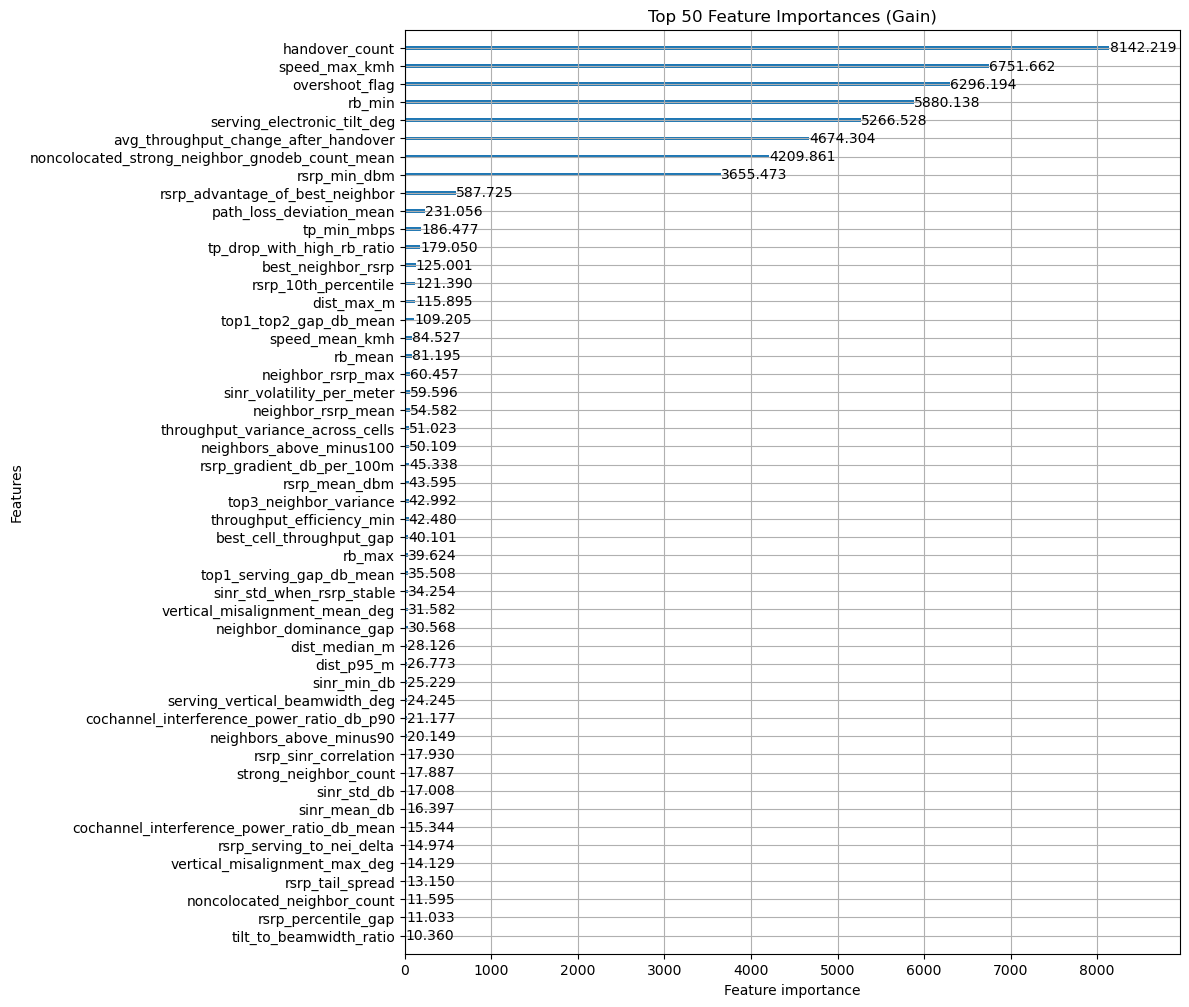

In [40]:
import lightgbm as lgb
import matplotlib.pyplot as plt

lgb.plot_importance(
    models['LightGBM'],
    max_num_features=50,
    importance_type="gain",  # or "split"
    figsize=(10, 12)
)
plt.title("Top 50 Feature Importances (Gain)")
plt.show()


In [41]:
features_df_enhanced.shape

(2400, 133)

# Comprehensive EDA: Feature Correlation Analysis with Answer Classes

Let's perform an extensive exploratory data analysis to understand which features are most strongly correlated with each class in the answer column.

In [42]:
# Check if features_df_enhanced exists, if not run necessary cells
try:
    print(f"✓ features_df_enhanced exists with shape: {features_df_enhanced.shape}")
    print(f"✓ Columns: {features_df_enhanced.shape[1]}")
    print(f"✓ Classes: {features_df_enhanced['answer'].unique()}")
except NameError:
    print("⚠️  features_df_enhanced not found in kernel!")
    print("\nPlease run the following cells first (in order):")
    print("  1. Cell 2 (Data Loading) - Loads df_train")
    print("  2. Cell 4 (Type Conversion Functions) - Defines preprocessing functions")
    print("  3. Cell 5-8 (Feature Engineering Functions) - Defines compute_rca_features")
    print("  4. Cell 24 (Reprocess Data) - Creates df_processed")
    print("  5. Cell 25 (Create Features DF) - Creates features_df_enhanced")
    print("\nOr run all cells from the beginning up to this point.")

✓ features_df_enhanced exists with shape: (2400, 133)
✓ Columns: 133
✓ Classes: ['C2' 'C1' 'C5' 'C8' 'C4' 'C3' 'C7' 'C6']


In [43]:
# Import necessary libraries for EDA
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, spearmanr, pointbiserialr
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (15, 10)

DATASET OVERVIEW

Dataset Shape: (2400, 133)
Number of Features: 132
Number of Samples: 2400

CLASS DISTRIBUTION

Absolute counts:
answer
C1    264
C2    320
C3    330
C4    283
C5    352
C6    225
C7    349
C8    277
Name: count, dtype: int64

Percentage distribution:
answer
C1    11.000000
C2    13.333333
C3    13.750000
C4    11.791667
C5    14.666667
C6     9.375000
C7    14.541667
C8    11.541667
Name: proportion, dtype: float64


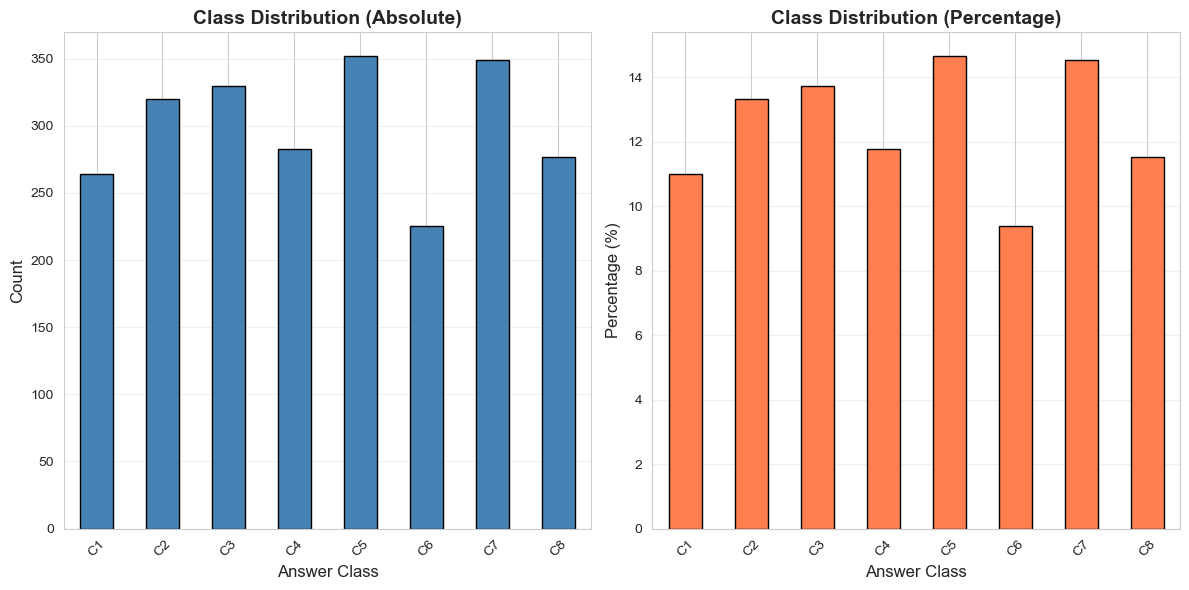

In [44]:
# Step 1: Basic Dataset Overview
print("="*80)
print("DATASET OVERVIEW")
print("="*80)
print(f"\nDataset Shape: {features_df_enhanced.shape}")
print(f"Number of Features: {features_df_enhanced.shape[1] - 1}")  # Excluding answer column
print(f"Number of Samples: {features_df_enhanced.shape[0]}")

print("\n" + "="*80)
print("CLASS DISTRIBUTION")
print("="*80)
class_dist = features_df_enhanced['answer'].value_counts().sort_index()
print("\nAbsolute counts:")
print(class_dist)
print("\nPercentage distribution:")
print(features_df_enhanced['answer'].value_counts(normalize=True).sort_index() * 100)

# Visualize class distribution
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
class_dist.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Class Distribution (Absolute)', fontsize=14, fontweight='bold')
plt.xlabel('Answer Class', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

plt.subplot(1, 2, 2)
(features_df_enhanced['answer'].value_counts(normalize=True).sort_index() * 100).plot(
    kind='bar', color='coral', edgecolor='black'
)
plt.title('Class Distribution (Percentage)', fontsize=14, fontweight='bold')
plt.xlabel('Answer Class', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [45]:
# Step 2: Feature Types Analysis
print("\n" + "="*80)
print("FEATURE TYPES ANALYSIS")
print("="*80)

# Separate features by type (excluding 'answer' and 'id' columns)
feature_cols = [col for col in features_df_enhanced.columns if col not in ['answer', 'id']]

# Identify numeric vs categorical features
numeric_features = []
categorical_features = []

for col in feature_cols:
    if features_df_enhanced[col].dtype in ['float64', 'int64']:
        unique_count = features_df_enhanced[col].nunique()
        if unique_count <= 10:  # Likely categorical or binary
            categorical_features.append(col)
        else:
            numeric_features.append(col)
    else:
        categorical_features.append(col)

print(f"\nNumeric Features: {len(numeric_features)}")
print(f"Categorical/Binary Features: {len(categorical_features)}")

print("\n--- Numeric Features ---")
print(numeric_features[:20], "..." if len(numeric_features) > 20 else "")

print("\n--- Categorical/Binary Features ---")
print(categorical_features[:20], "..." if len(categorical_features) > 20 else "")

# Check for missing values
missing_data = features_df_enhanced[feature_cols].isnull().sum()
missing_percent = (missing_data / len(features_df_enhanced)) * 100
missing_df = pd.DataFrame({
    'Missing_Count': missing_data,
    'Percentage': missing_percent
}).sort_values('Percentage', ascending=False)

print("\n" + "="*80)
print("MISSING VALUES ANALYSIS")
print("="*80)
if missing_df['Missing_Count'].sum() > 0:
    print("\nFeatures with missing values:")
    print(missing_df[missing_df['Missing_Count'] > 0].head(20))
else:
    print("\nNo missing values found in the dataset!")


FEATURE TYPES ANALYSIS

Numeric Features: 62
Categorical/Binary Features: 69

--- Numeric Features ---
['tp_min_mbps', 'tp_mean_mbps', 'tp_max_mbps', 'rb_mean', 'rb_min', 'rb_max', 'throughput_efficiency_mbps_per_rb', 'throughput_efficiency_min', 'throughput_efficiency_max', 'speed_max_kmh', 'speed_mean_kmh', 'dist_median_m', 'dist_p95_m', 'dist_max_m', 'serving_mechanical_tilt_deg', 'serving_total_tilt_deg', 'tilt_to_beamwidth_ratio', 'vertical_misalignment_mean_deg', 'vertical_misalignment_max_deg', 'strong_neighbor_count'] ...

--- Categorical/Binary Features ---
['tp_drop_ratio', 'tp_samples_below_600', 'rb_below_160_flag', 'low_efficiency_flag', 'neighbor_tp_eff_mean', 'neighbor_tp_eff_max', 'tp_efficiency_gap', 'neighbor_more_efficient', 'speed_above_40_flag', 'handover_count', 'frequent_handover_flag', 'pci_mod30_collision', 'overshoot_flag', 'serving_electronic_tilt_deg', 'serving_vertical_beamwidth_deg', 'large_tilt_flag', 'ue_below_beam_flag', 'overlap_flag', 'steep_rsrp_dec

In [46]:
# Step 3: Point-Biserial and Cramér's V Correlation with Answer Classes
print("\n" + "="*80)
print("CORRELATION ANALYSIS: Features vs Answer Classes")
print("="*80)

# Encode answer labels for correlation analysis
le = LabelEncoder()
y_encoded = le.fit_transform(features_df_enhanced['answer'])
classes = le.classes_

# Function to calculate Cramér's V (for categorical features)
def cramers_v(x, y):
    """Calculate Cramér's V statistic for categorical-categorical association."""
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

# Calculate correlations for all features
correlation_results = []

for col in feature_cols:
    try:
        # Skip if column has no variance
        if features_df_enhanced[col].nunique() <= 1:
            continue
        
        if col in numeric_features:
            # For numeric features, calculate correlation with each class using point-biserial
            corr_values = []
            for class_label in classes:
                binary_target = (features_df_enhanced['answer'] == class_label).astype(int)
                # Remove NaN values
                mask = ~(features_df_enhanced[col].isna() | binary_target.isna())
                if mask.sum() > 0:
                    corr = np.corrcoef(features_df_enhanced[col][mask], binary_target[mask])[0, 1]
                    corr_values.append(abs(corr))
                else:
                    corr_values.append(0)
            
            # Overall correlation strength (max absolute correlation)
            max_corr = max(corr_values)
            correlation_results.append({
                'Feature': col,
                'Type': 'Numeric',
                'Max_Correlation': max_corr,
                **{f'Corr_{class_label}': corr_values[i] for i, class_label in enumerate(classes)}
            })
        
        else:
            # For categorical features, use Cramér's V
            cramers = cramers_v(features_df_enhanced[col], features_df_enhanced['answer'])
            
            # Calculate per-class association
            corr_values = []
            for class_label in classes:
                binary_target = (features_df_enhanced['answer'] == class_label).astype(int)
                try:
                    cv = cramers_v(features_df_enhanced[col], binary_target)
                    corr_values.append(cv)
                except:
                    corr_values.append(0)
            
            correlation_results.append({
                'Feature': col,
                'Type': 'Categorical',
                'Max_Correlation': cramers,
                **{f'Corr_{class_label}': corr_values[i] for i, class_label in enumerate(classes)}
            })
    except Exception as e:
        print(f"Error processing {col}: {str(e)}")
        continue

# Create correlation DataFrame
corr_df = pd.DataFrame(correlation_results).sort_values('Max_Correlation', ascending=False)

print("\n--- Top 30 Features by Overall Correlation ---")
print(corr_df.head(30).to_string())


CORRELATION ANALYSIS: Features vs Answer Classes

--- Top 30 Features by Overall Correlation ---
                                            Feature         Type  Max_Correlation   Corr_C1   Corr_C2   Corr_C3   Corr_C4   Corr_C5   Corr_C6   Corr_C7   Corr_C8
16                                   handover_count  Categorical         0.998956  0.217373  0.999791  0.247363  0.226217  0.999791  0.198526  0.255670  0.223445
15                              speed_above_40_flag  Categorical         0.998748  0.141698  0.158785  0.161737  0.147614  0.168145  0.129070  0.998323  0.145761
21                                   overshoot_flag  Categorical         0.998748  0.134421  0.998196  0.153509  0.140057  0.159611  0.122386  0.158785  0.138291
91                               ping_pong_detected  Categorical         0.998748  0.142441  0.159611  0.162577  0.148386  0.998335  0.129752  0.168145  0.146523
90                         ping_pong_handover_count  Categorical         0.998748  0.142441 


TOP CORRELATED FEATURES PER CLASS

--- Top 15 Features for C1 ---
                                       Feature        Type  Corr_C1
                                  rsrp_min_dbm     Numeric 0.597911
                          rsrp_10th_percentile     Numeric 0.399147
                          far_edge_degradation Categorical 0.278497
                                 rsrp_mean_dbm     Numeric 0.230662
                                handover_count Categorical 0.217373
           drop_zone_good_rsrp_poor_sinr_ratio Categorical 0.190624
noncolocated_strong_neighbor_gnodeb_count_mean     Numeric 0.155329
                                 speed_max_kmh     Numeric 0.146675
                            ping_pong_detected Categorical 0.142441
                      ping_pong_handover_count Categorical 0.142441
                        frequent_handover_flag Categorical 0.142441
                           speed_above_40_flag Categorical 0.141698
                      path_loss_deviation_mean   

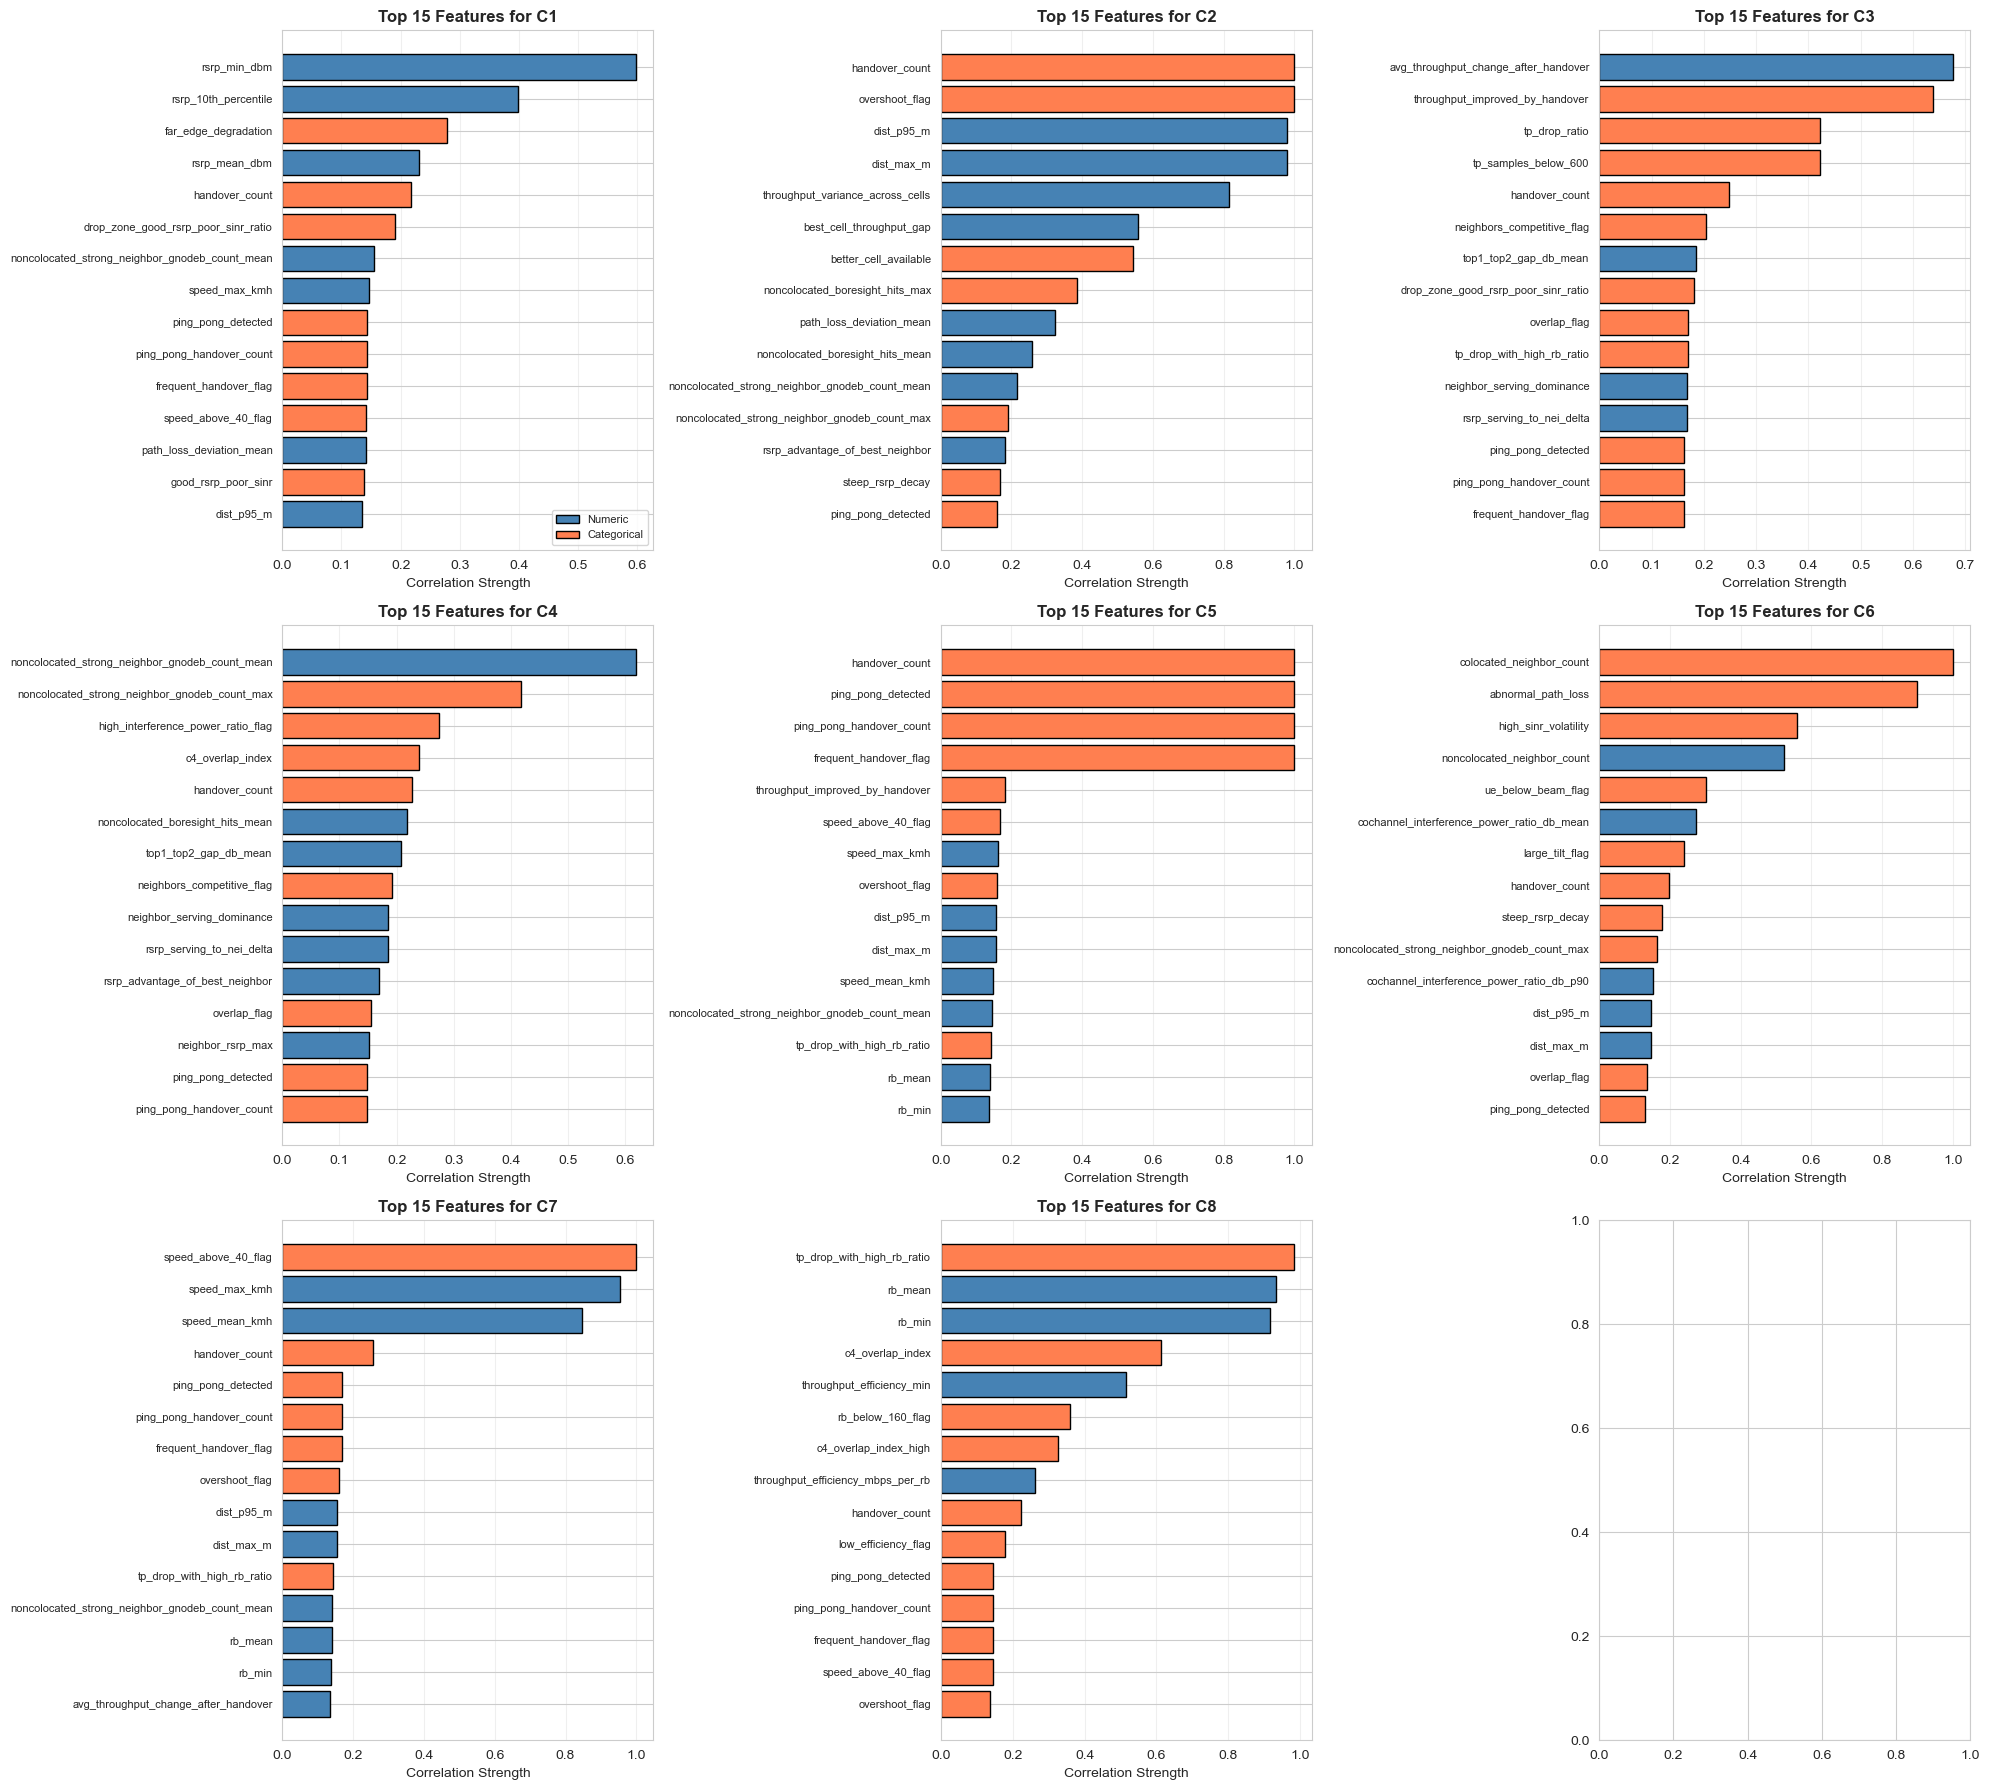

In [47]:
# Step 4: Visualize Top Correlations for Each Class
print("\n" + "="*80)
print("TOP CORRELATED FEATURES PER CLASS")
print("="*80)

# For each class, find top 15 most correlated features
top_n = 15

fig, axes = plt.subplots(3, 3, figsize=(20, 18))
axes = axes.flatten()

for idx, class_label in enumerate(classes):
    corr_col = f'Corr_{class_label}'
    top_features = corr_df.nlargest(top_n, corr_col)
    
    print(f"\n--- Top {top_n} Features for {class_label} ---")
    print(top_features[['Feature', 'Type', corr_col]].to_string(index=False))
    
    # Visualize
    ax = axes[idx]
    colors = ['steelblue' if t == 'Numeric' else 'coral' for t in top_features['Type']]
    y_pos = np.arange(len(top_features))
    
    ax.barh(y_pos, top_features[corr_col], color=colors, edgecolor='black')
    ax.set_yticks(y_pos)
    ax.set_yticklabels(top_features['Feature'], fontsize=8)
    ax.invert_yaxis()
    ax.set_xlabel('Correlation Strength', fontsize=10)
    ax.set_title(f'Top {top_n} Features for {class_label}', fontsize=12, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    
    # Add legend for first subplot
    if idx == 0:
        from matplotlib.patches import Patch
        legend_elements = [
            Patch(facecolor='steelblue', edgecolor='black', label='Numeric'),
            Patch(facecolor='coral', edgecolor='black', label='Categorical')
        ]
        ax.legend(handles=legend_elements, loc='lower right', fontsize=8)

plt.tight_layout()
plt.show()


STATISTICAL SUMMARY: Top Numeric Features by Class

Feature: dist_p95_m
        count      mean    median      std       min       max
answer                                                        
C1        264   156.782   141.274   95.090    17.874   701.793
C2        320  2591.500  2659.839  374.091  1561.014  3678.306
C3        330   167.279   150.730  112.656    13.814   767.577
C4        283   167.586   151.204  113.704    13.814   767.577
C5        352   160.959   140.972  107.108    13.814   767.577
C6        225    96.097    88.660   51.148     7.237   259.117
C7        349   161.072   141.120  110.690    13.814   767.577
C8        277   160.695   141.412  108.492    17.874   725.201


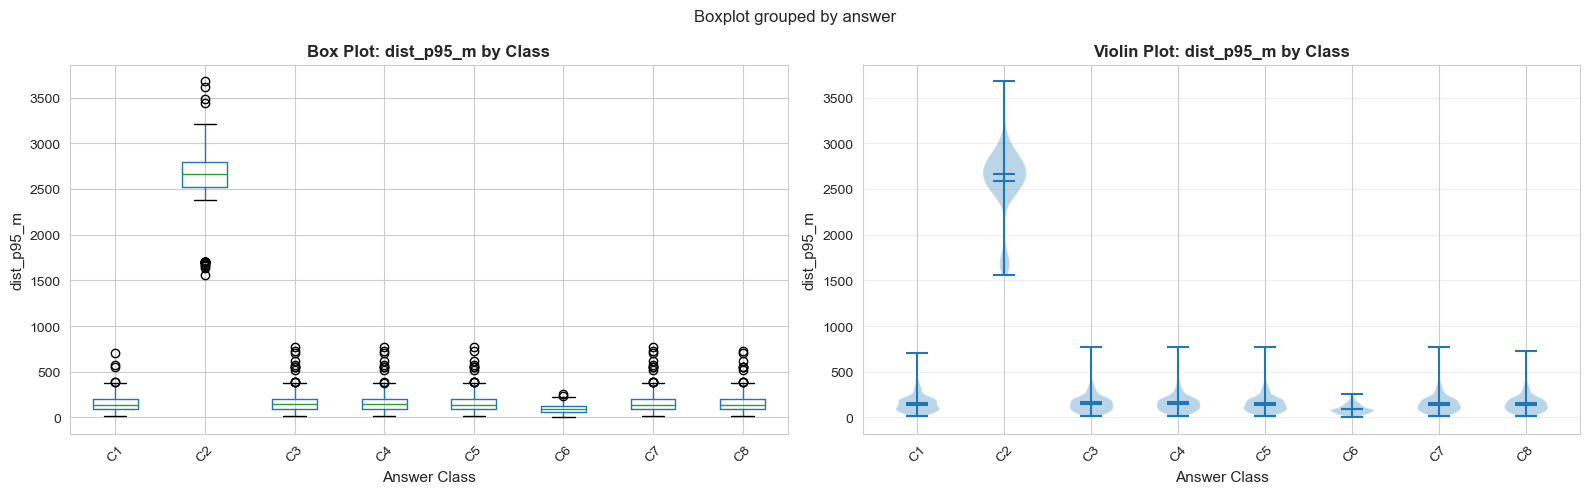


Feature: dist_max_m
        count      mean    median      std       min       max
answer                                                        
C1        264   166.929   154.178   97.592    19.287   704.154
C2        320  2597.064  2662.044  374.636  1564.169  3679.785
C3        330   175.054   158.663  114.212    14.697   767.804
C4        283   176.354   160.783  114.866    14.697   767.804
C5        352   170.621   152.725  109.394    14.697   768.028
C6        225   105.028    91.876   57.741     9.261   312.926
C7        349   170.116   151.776  112.333    14.697   767.804
C8        277   169.242   150.780  109.841    19.287   728.471


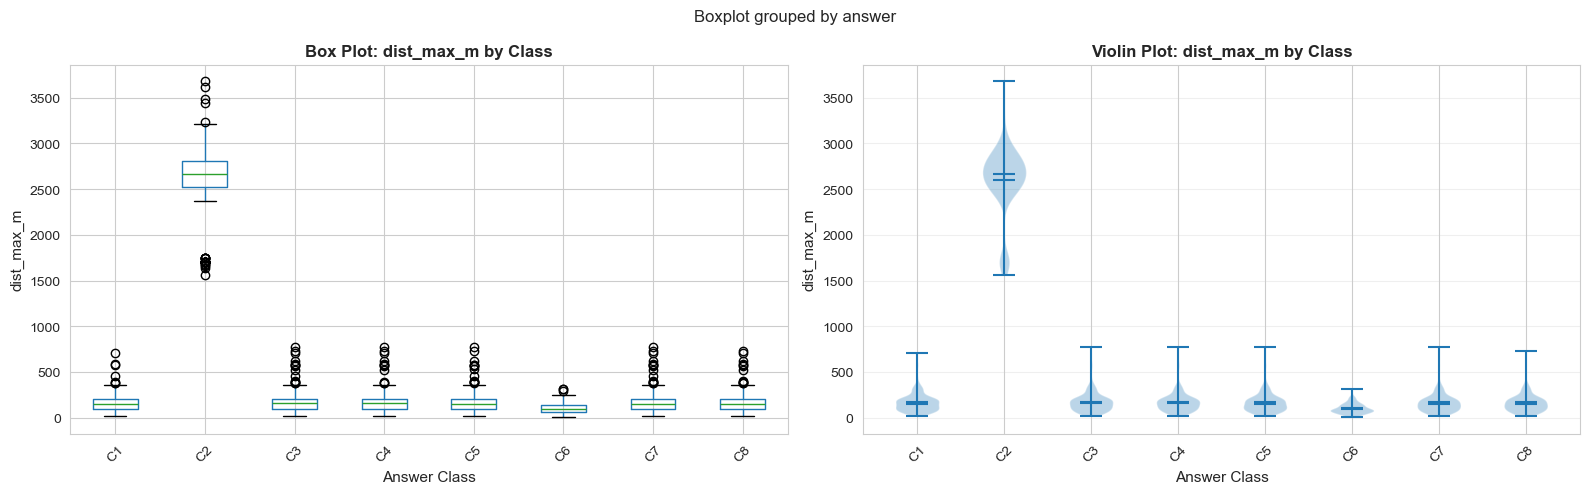


Feature: speed_max_kmh
        count    mean  median    std   min   max
answer                                          
C1        264  35.356    36.0  3.513  22.0  39.0
C2        320  35.703    36.0  3.317  22.0  39.0
C3        330  35.648    36.0  3.486  22.0  39.0
C4        283  35.866    37.0  3.330  22.0  39.0
C5        352  35.670    36.5  3.438  22.0  39.0
C6        225  35.556    37.0  3.716  22.0  39.0
C7        349  71.375    73.0  6.111  46.0  79.0
C8        277  35.816    37.0  3.264  23.0  39.0


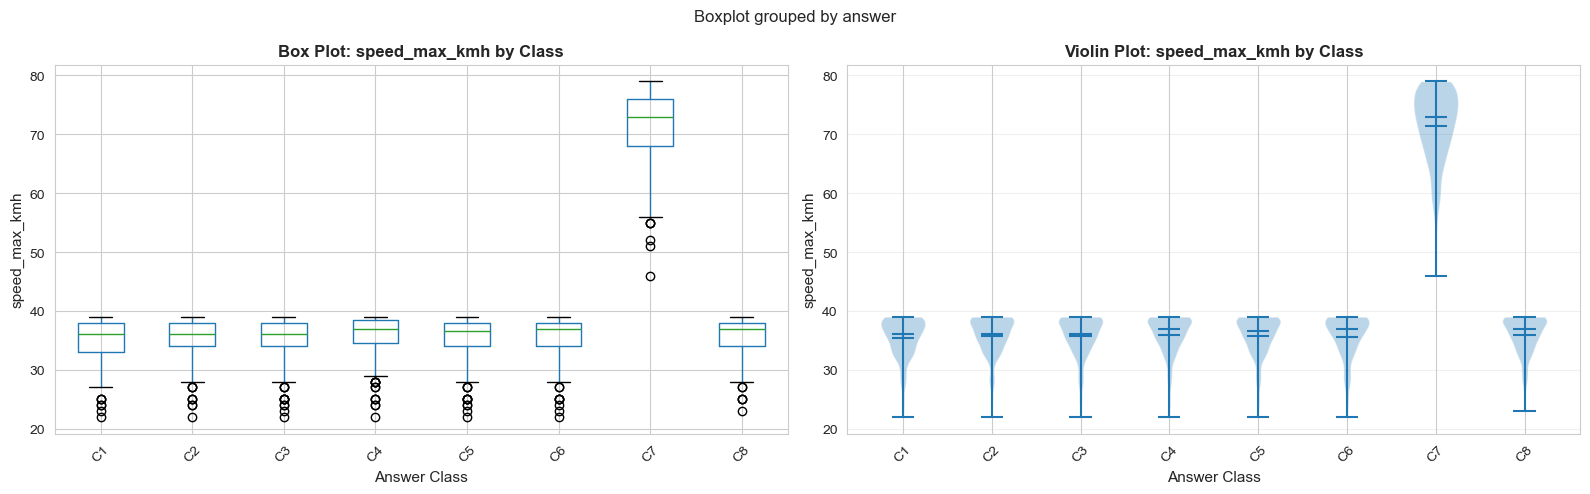


Feature: rb_mean
        count     mean   median    std      min      max
answer                                                  
C1        264  204.223  205.396  5.296  182.624  211.318
C2        320  204.397  205.287  5.029  182.624  211.318
C3        330  204.459  205.516  5.067  182.624  211.216
C4        283  204.208  205.182  5.191  182.624  211.318
C5        352  204.373  205.371  5.098  182.624  211.318
C6        225  204.878  206.033  5.066  182.624  211.318
C7        349  204.448  205.430  5.088  182.624  211.216
C8        277  163.807  164.580  3.888  145.906  168.944


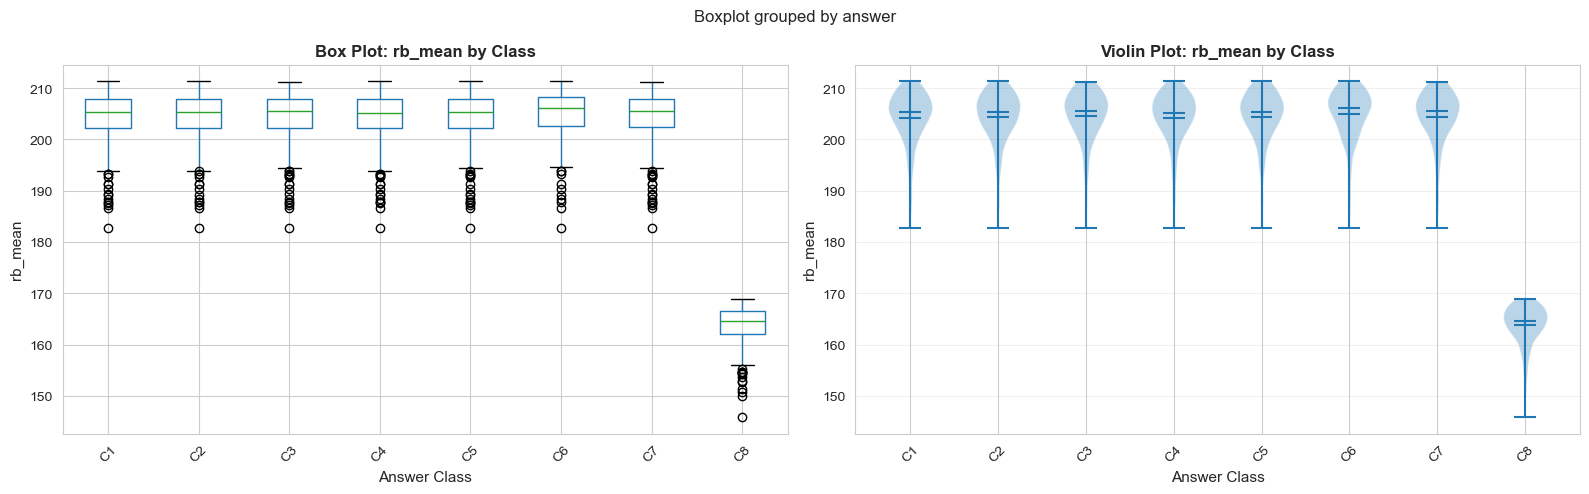


Feature: rb_min
        count     mean   median     std    min      max
answer                                                 
C1        264  188.986  190.335  13.503  160.0  211.150
C2        320  188.733  190.335  13.475  160.0  211.150
C3        330  188.907  190.135  13.538  160.0  210.990
C4        283  188.592  190.480  13.118  160.0  211.150
C5        352  188.809  190.135  13.464  160.0  211.150
C6        225  189.489  190.860  14.107  160.0  211.150
C7        349  188.977  190.420  13.359  160.0  210.990
C8        277   97.625   98.255   6.492   80.0  105.595


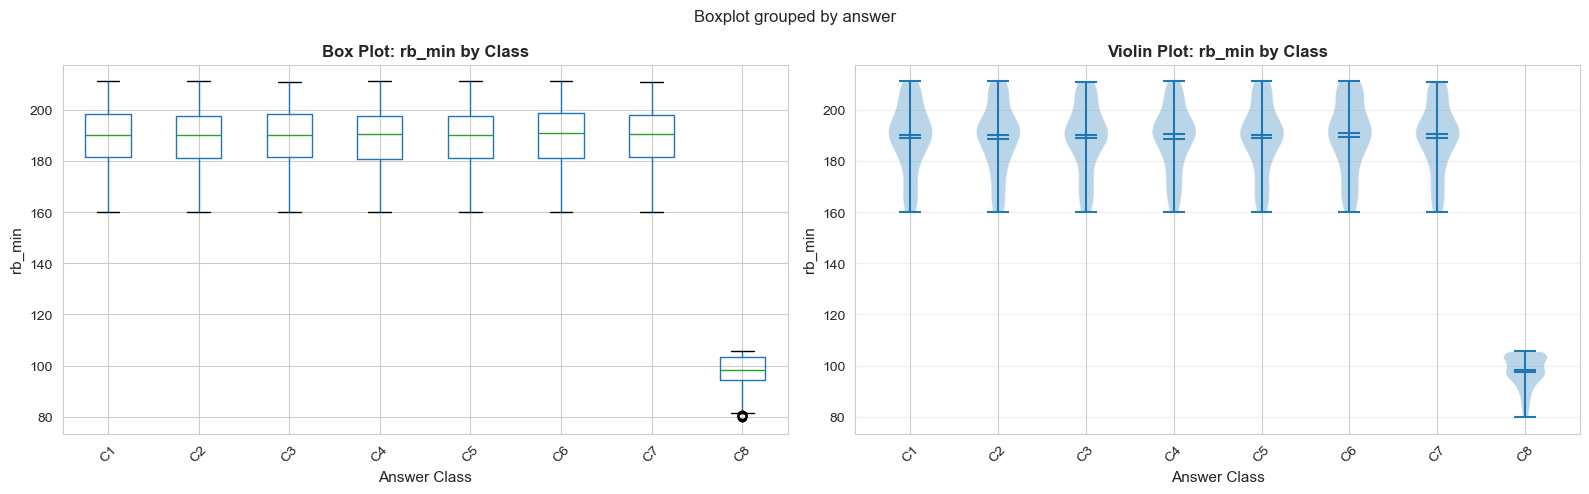


Feature: speed_mean_kmh
        count    mean  median    std   min   max
answer                                          
C1        264  19.436   19.40  3.681   7.2  27.6
C2        320  19.568   19.55  3.439   7.2  27.6
C3        330  19.553   19.65  3.549   7.2  27.4
C4        283  19.605   19.80  3.395   7.2  27.4
C5        352  19.465   19.50  3.524   7.2  27.4
C6        225  19.359   19.50  3.660   7.2  27.2
C7        349  35.519   35.50  3.484  23.2  43.6
C8        277  19.697   19.70  3.604   9.0  27.6


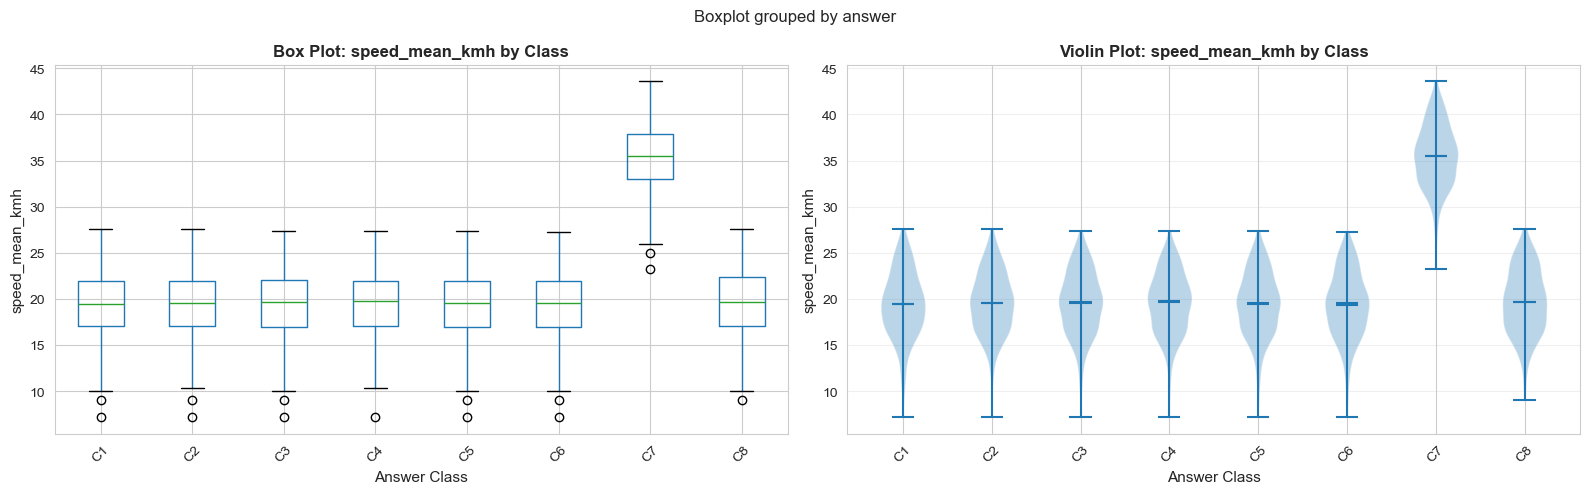


Feature: throughput_variance_across_cells
        count     mean   median      std      min       max
answer                                                     
C1        264  192.162  174.164  130.870    4.361   689.435
C2        320  744.283  721.078  158.459  446.396  1208.310
C3        330  173.430  137.907  134.746    0.064   759.693
C4        283  186.855  167.309  133.979    1.404   689.435
C5        352  183.900  168.267  127.100    2.006   709.080
C6        225  179.642  160.442  128.818    1.404   689.435
C7        349  187.965  171.976  130.650    1.404   693.026
C8        277  190.251  173.507  133.035    2.580   693.026


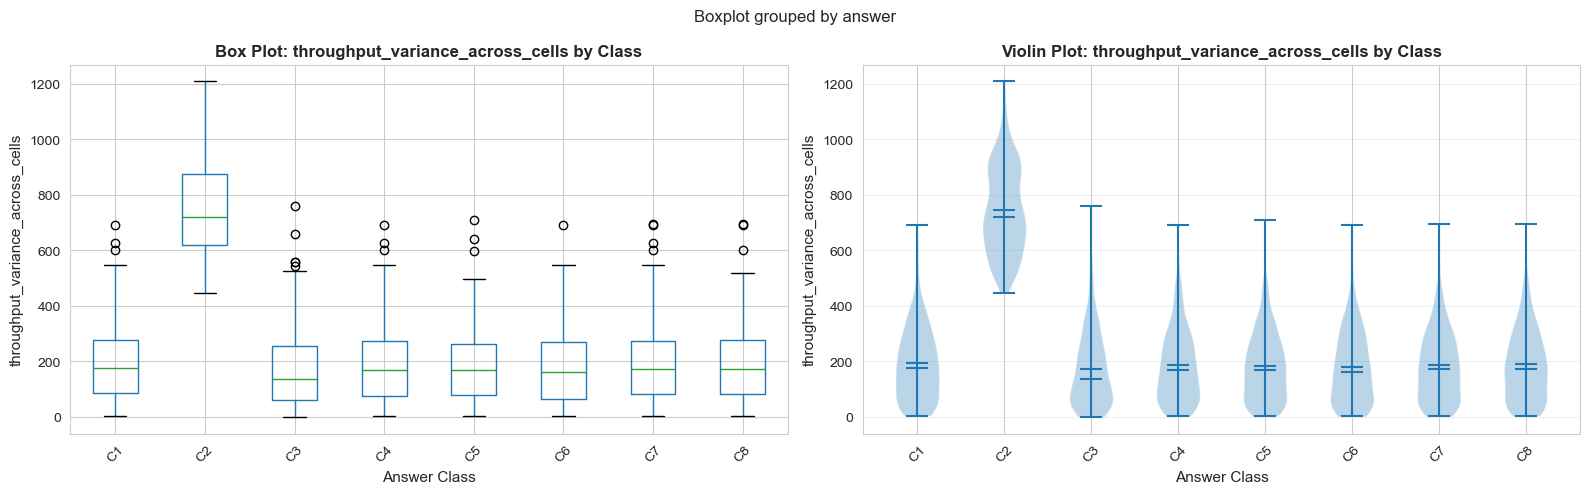


Feature: avg_throughput_change_after_handover
        count     mean   median      std     min      max
answer                                                   
C1        264  -20.584  -15.625   73.676 -319.69  201.890
C2        320    4.274    6.595  114.294 -314.09  315.555
C3        330  182.940  185.800   68.085 -119.69  401.890
C4        283  -18.520  -13.250   70.203 -319.69  201.890
C5        352   -4.040   -1.818   38.623 -182.96  113.110
C6        225  -15.766  -15.390   68.084 -292.33  201.890
C7        349  -18.143  -13.250   69.434 -319.69  201.890
C8        277  -18.631  -16.230   60.889 -239.27  162.230


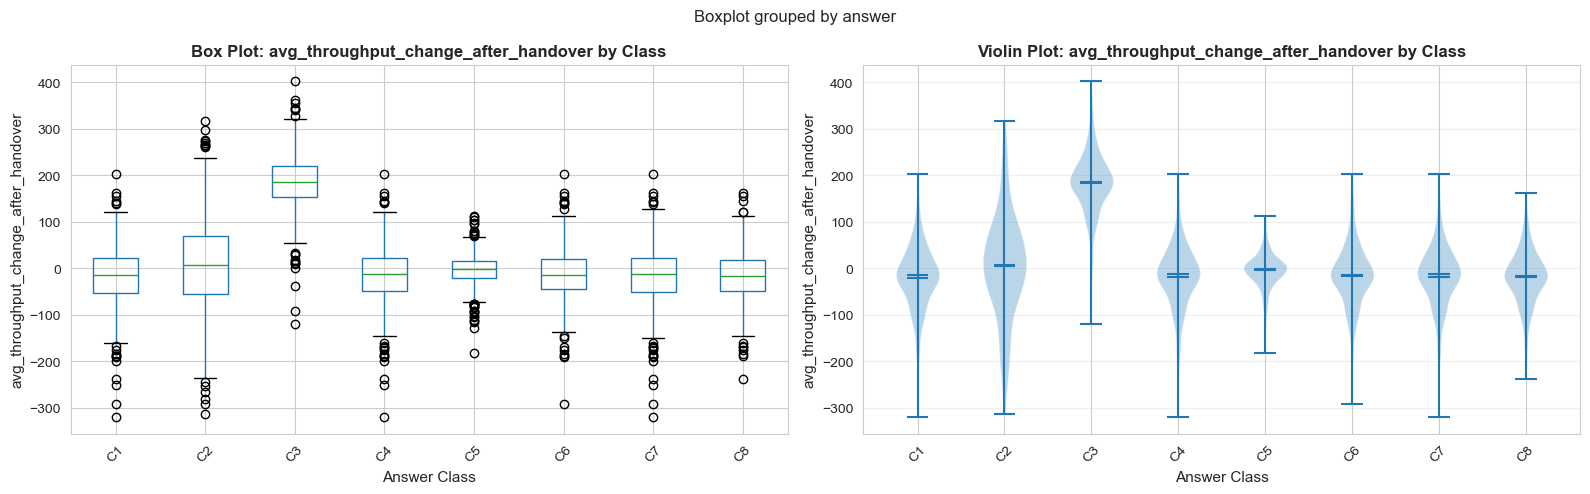


Feature: noncolocated_strong_neighbor_gnodeb_count_mean
        count   mean  median    std  min    max
answer                                         
C1        264  0.047     0.0  0.094  0.0  0.600
C2        320  0.211     0.2  0.182  0.0  0.900
C3        330  0.060     0.0  0.111  0.0  0.600
C4        283  0.400     0.4  0.063  0.2  0.900
C5        352  0.062     0.0  0.110  0.0  0.600
C6        225  0.055     0.0  0.134  0.0  0.714
C7        349  0.063     0.0  0.112  0.0  0.600
C8        277  0.068     0.0  0.114  0.0  0.600


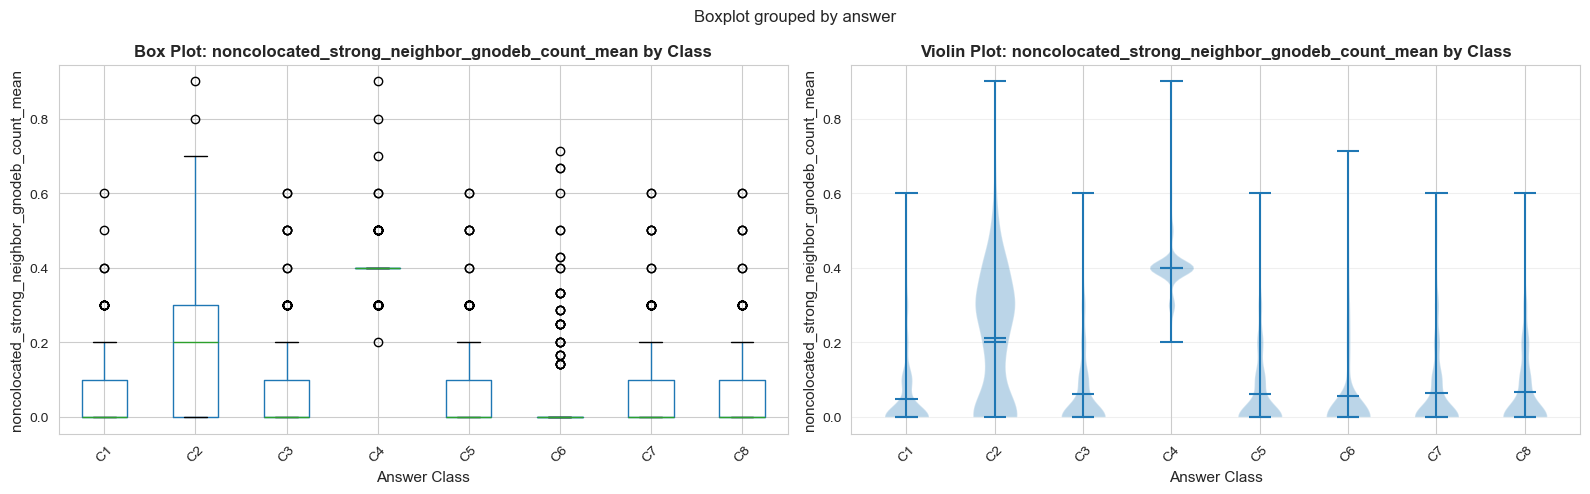


Feature: rsrp_min_dbm
        count    mean  median    std    min    max
answer                                            
C1        264 -91.308 -91.725  2.123 -94.72 -85.53
C2        320 -88.231 -88.490  1.157 -89.96 -85.00
C3        330 -88.291 -88.565  1.119 -89.99 -85.00
C4        283 -88.310 -88.570  1.096 -89.99 -85.00
C5        352 -88.239 -88.540  1.152 -89.99 -85.00
C6        225 -88.253 -88.530  1.112 -89.96 -85.22
C7        349 -88.241 -88.550  1.145 -89.99 -85.00
C8        277 -88.228 -88.410  1.156 -89.99 -85.00


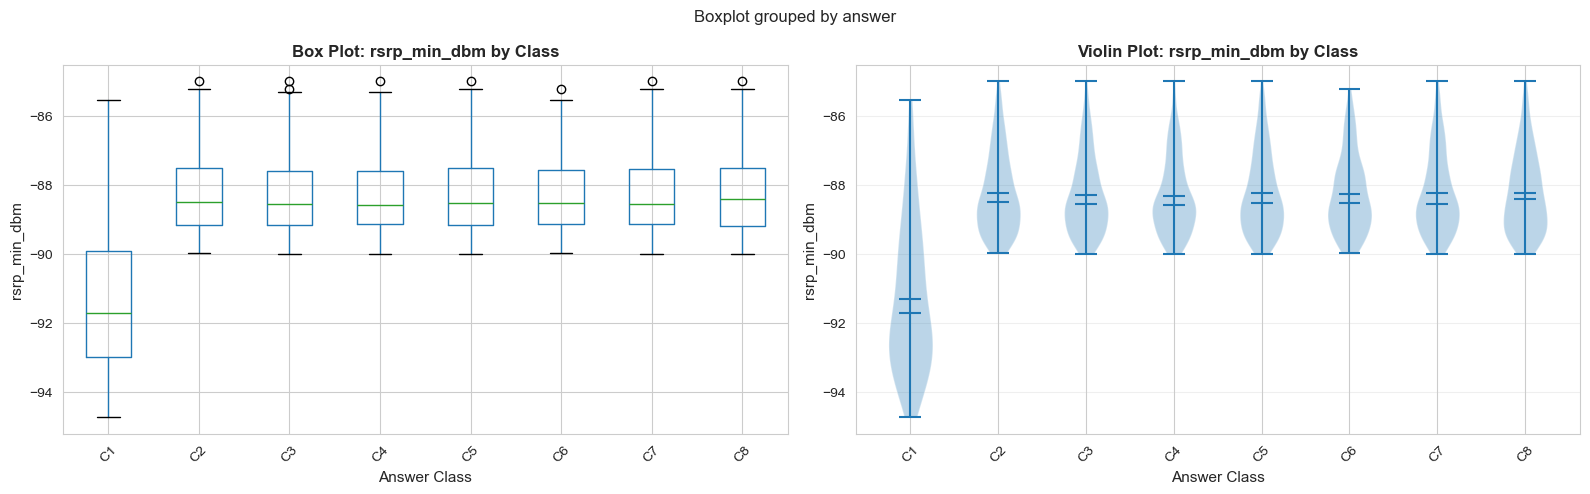

In [48]:
# Step 5: Class-wise Statistical Summary for Top Numeric Features
print("\n" + "="*80)
print("STATISTICAL SUMMARY: Top Numeric Features by Class")
print("="*80)

# Get top 20 numeric features overall
top_numeric = corr_df[corr_df['Type'] == 'Numeric'].head(20)['Feature'].tolist()

# For each top numeric feature, show statistics by class
for feature in top_numeric[:10]:  # Show top 10 for brevity
    print(f"\n{'='*80}")
    print(f"Feature: {feature}")
    print('='*80)
    
    class_stats = features_df_enhanced.groupby('answer')[feature].agg([
        'count', 'mean', 'median', 'std', 'min', 'max'
    ]).round(3)
    print(class_stats)
    
    # Visualize distribution
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    # Box plot
    ax1 = axes[0]
    features_df_enhanced.boxplot(column=feature, by='answer', ax=ax1)
    ax1.set_title(f'Box Plot: {feature} by Class', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Answer Class', fontsize=11)
    ax1.set_ylabel(feature, fontsize=11)
    plt.sca(ax1)
    plt.xticks(rotation=45)
    
    # Violin plot
    ax2 = axes[1]
    features_df_enhanced_plot = features_df_enhanced[[feature, 'answer']].dropna()
    parts = ax2.violinplot(
        [features_df_enhanced_plot[features_df_enhanced_plot['answer'] == c][feature].values 
         for c in classes],
        positions=range(len(classes)),
        showmeans=True,
        showmedians=True
    )
    ax2.set_xticks(range(len(classes)))
    ax2.set_xticklabels(classes, rotation=45)
    ax2.set_xlabel('Answer Class', fontsize=11)
    ax2.set_ylabel(feature, fontsize=11)
    ax2.set_title(f'Violin Plot: {feature} by Class', fontsize=12, fontweight='bold')
    ax2.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()


CATEGORICAL FEATURES ANALYSIS

Categorical Feature: handover_count

Percentage distribution by class:
answer             C1     C2     C3     C4     C5     C6     C7     C8
handover_count                                                        
1               100.0    0.0  100.0  100.0    0.0  100.0  100.0  100.0
2                 0.0  100.0    0.0    0.0    0.0    0.0    0.0    0.0
3                 0.0    0.0    0.0    0.0  100.0    0.0    0.0    0.0


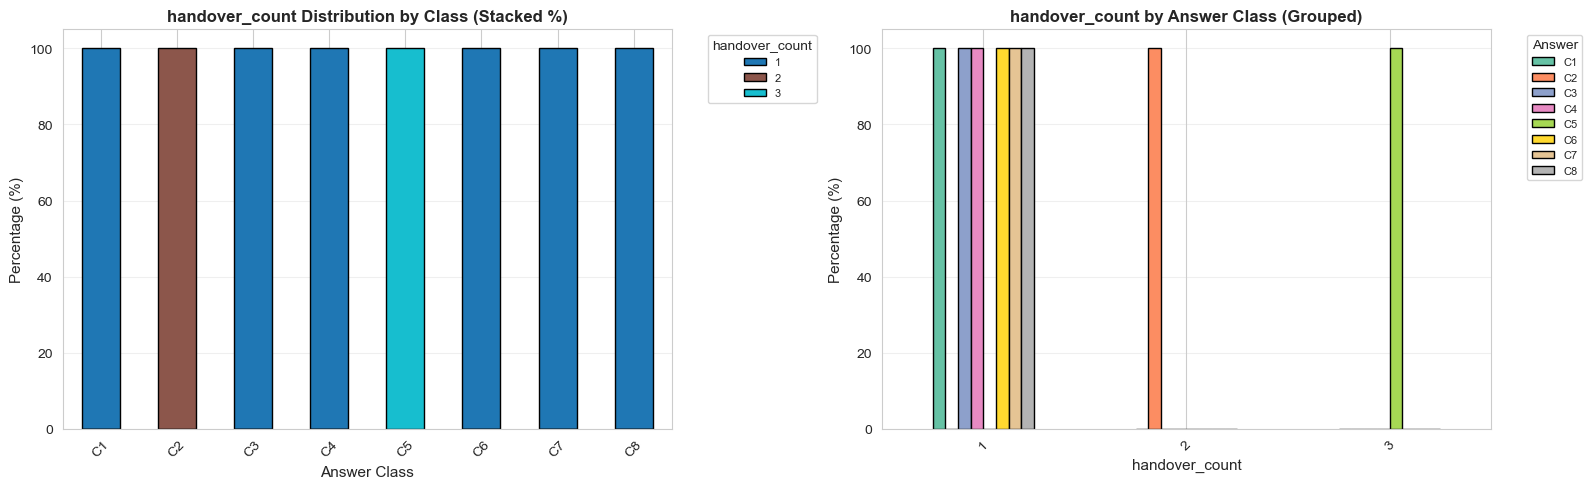


Categorical Feature: speed_above_40_flag

Percentage distribution by class:
answer                  C1     C2     C3     C4     C5     C6     C7     C8
speed_above_40_flag                                                        
False                100.0  100.0  100.0  100.0  100.0  100.0    0.0  100.0
True                   0.0    0.0    0.0    0.0    0.0    0.0  100.0    0.0


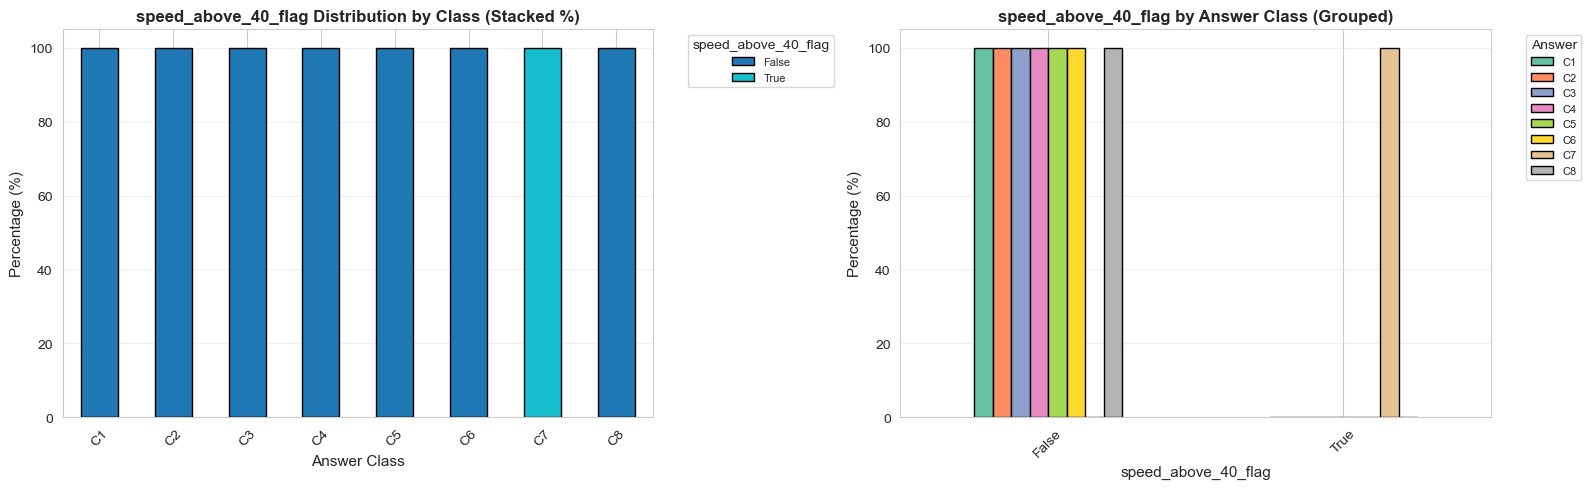


Categorical Feature: overshoot_flag

Percentage distribution by class:
answer             C1     C2     C3     C4     C5     C6     C7     C8
overshoot_flag                                                        
False           100.0    0.0  100.0  100.0  100.0  100.0  100.0  100.0
True              0.0  100.0    0.0    0.0    0.0    0.0    0.0    0.0


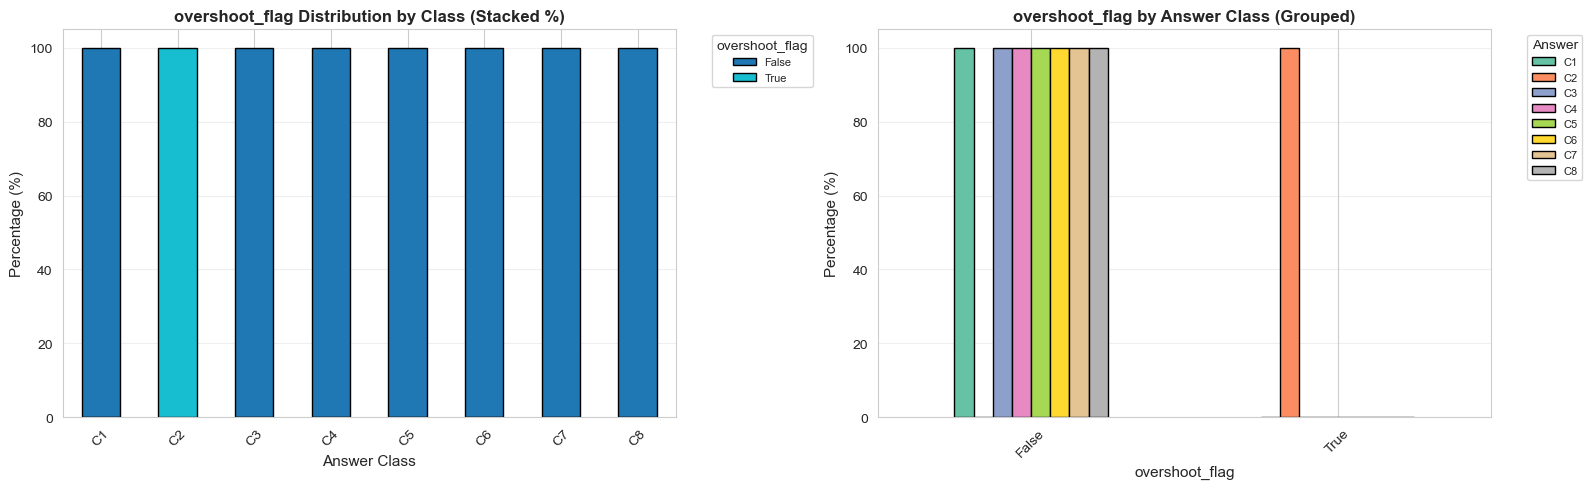


Categorical Feature: ping_pong_detected

Percentage distribution by class:
answer                 C1     C2     C3     C4     C5     C6     C7     C8
ping_pong_detected                                                        
False               100.0  100.0  100.0  100.0    0.0  100.0  100.0  100.0
True                  0.0    0.0    0.0    0.0  100.0    0.0    0.0    0.0


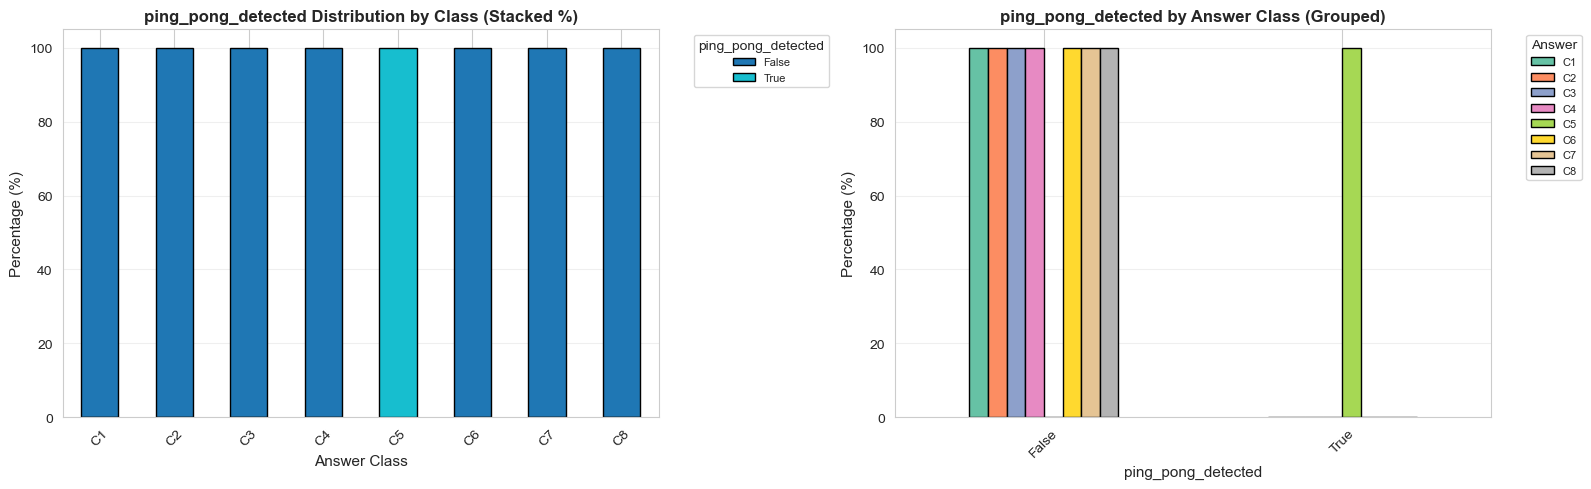


Categorical Feature: ping_pong_handover_count

Percentage distribution by class:
answer                       C1     C2     C3     C4     C5     C6     C7  \
ping_pong_handover_count                                                    
0                         100.0  100.0  100.0  100.0    0.0  100.0  100.0   
2                           0.0    0.0    0.0    0.0  100.0    0.0    0.0   

answer                       C8  
ping_pong_handover_count         
0                         100.0  
2                           0.0  


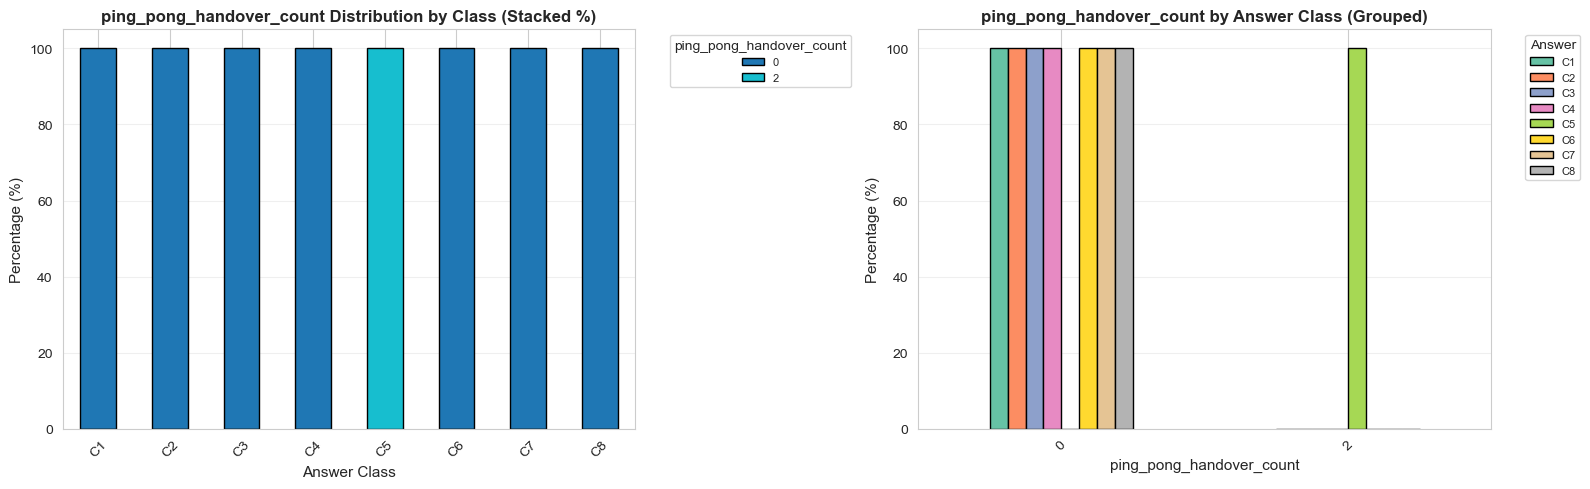

In [49]:
# Step 6: Categorical Features Analysis
print("\n" + "="*80)
print("CATEGORICAL FEATURES ANALYSIS")
print("="*80)

# Get top 10 categorical features
top_categorical = corr_df[corr_df['Type'] == 'Categorical'].head(10)['Feature'].tolist()

for feature in top_categorical[:5]:  # Show top 5 for brevity
    print(f"\n{'='*80}")
    print(f"Categorical Feature: {feature}")
    print('='*80)
    
    # Cross-tabulation
    crosstab = pd.crosstab(
        features_df_enhanced[feature], 
        features_df_enhanced['answer'], 
        normalize='columns'
    ) * 100
    
    print("\nPercentage distribution by class:")
    print(crosstab.round(2))
    
    # Visualize
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    # Stacked bar chart (normalized)
    ax1 = axes[0]
    crosstab.T.plot(kind='bar', stacked=True, ax=ax1, colormap='tab10', edgecolor='black')
    ax1.set_title(f'{feature} Distribution by Class (Stacked %)', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Answer Class', fontsize=11)
    ax1.set_ylabel('Percentage (%)', fontsize=11)
    ax1.legend(title=feature, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45)
    ax1.grid(axis='y', alpha=0.3)
    
    # Grouped bar chart
    ax2 = axes[1]
    crosstab.plot(kind='bar', ax=ax2, colormap='Set2', edgecolor='black')
    ax2.set_title(f'{feature} by Answer Class (Grouped)', fontsize=12, fontweight='bold')
    ax2.set_xlabel(feature, fontsize=11)
    ax2.set_ylabel('Percentage (%)', fontsize=11)
    ax2.legend(title='Answer', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45)
    ax2.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()


CORRELATION HEATMAP: Top Features with Answer Classes


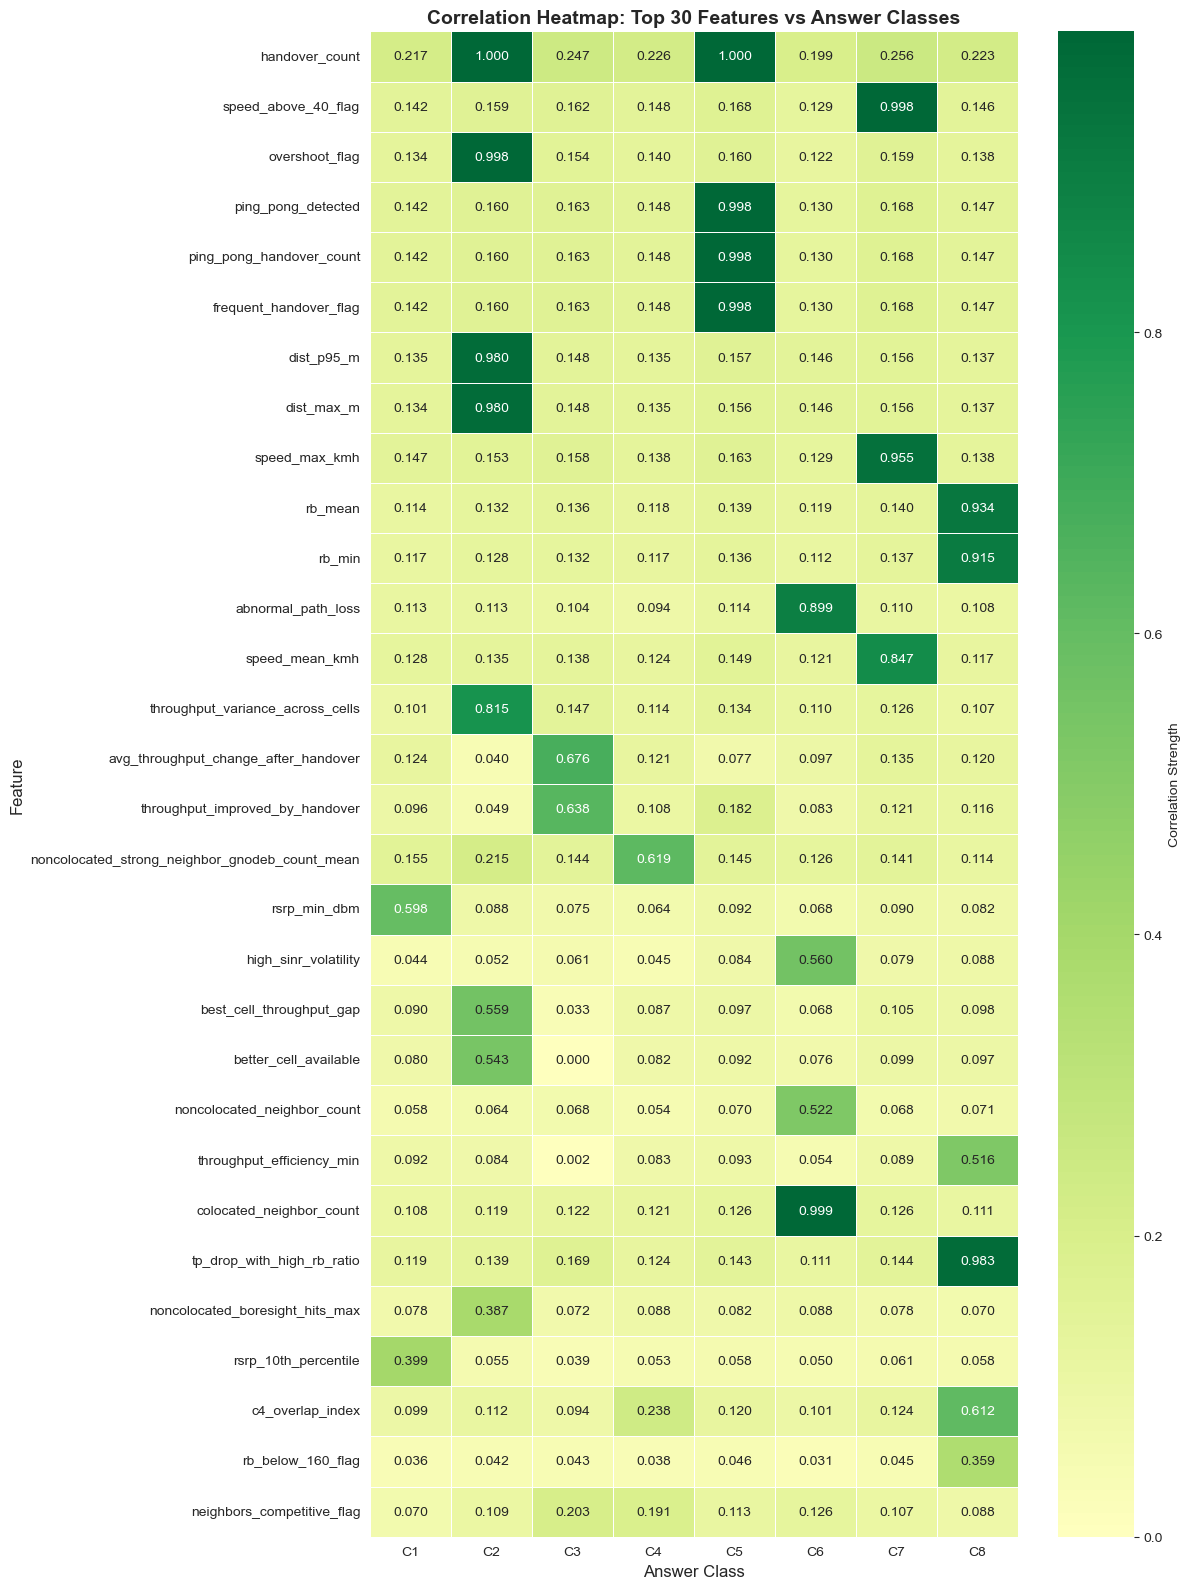


Heatmap shows correlation strength between features and each class.
Darker green = stronger positive correlation, Lighter colors = weaker correlation


In [50]:
# Step 7: Correlation Heatmap - Top Features
print("\n" + "="*80)
print("CORRELATION HEATMAP: Top Features with Answer Classes")
print("="*80)

# Select top 30 features
top_30_features = corr_df.head(30)['Feature'].tolist()

# Create a correlation matrix for top features with each class
heatmap_data = []
for feature in top_30_features:
    row = {'Feature': feature}
    for class_label in classes:
        corr_col = f'Corr_{class_label}'
        row[class_label] = corr_df[corr_df['Feature'] == feature][corr_col].values[0]
    heatmap_data.append(row)

heatmap_df = pd.DataFrame(heatmap_data).set_index('Feature')

# Plot heatmap
plt.figure(figsize=(12, 16))
sns.heatmap(
    heatmap_df,
    annot=True,
    fmt='.3f',
    cmap='RdYlGn',
    center=0,
    linewidths=0.5,
    cbar_kws={'label': 'Correlation Strength'},
    vmin=0,
    vmax=heatmap_df.max().max()
)
plt.title('Correlation Heatmap: Top 30 Features vs Answer Classes', fontsize=14, fontweight='bold')
plt.xlabel('Answer Class', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()

print("\nHeatmap shows correlation strength between features and each class.")
print("Darker green = stronger positive correlation, Lighter colors = weaker correlation")


MUTUAL INFORMATION ANALYSIS

--- Top 30 Features by Mutual Information ---
                                       Feature  MI_Score
                                handover_count  0.775745
                      ping_pong_handover_count  0.425643
                           speed_above_40_flag  0.415290
                        frequent_handover_flag  0.410927
                                overshoot_flag  0.398462
                            ping_pong_detected  0.396533
                                 speed_max_kmh  0.385303
noncolocated_strong_neighbor_gnodeb_count_mean  0.378369
                    tp_drop_with_high_rb_ratio  0.358395
                     rsrp_gradient_db_per_100m  0.350854
                      colocated_neighbor_count  0.331084
                   serving_electronic_tilt_deg  0.318887
                   noncolocated_neighbor_count  0.304591
                serving_vertical_beamwidth_deg  0.303546
                                    dist_max_m  0.300744
            

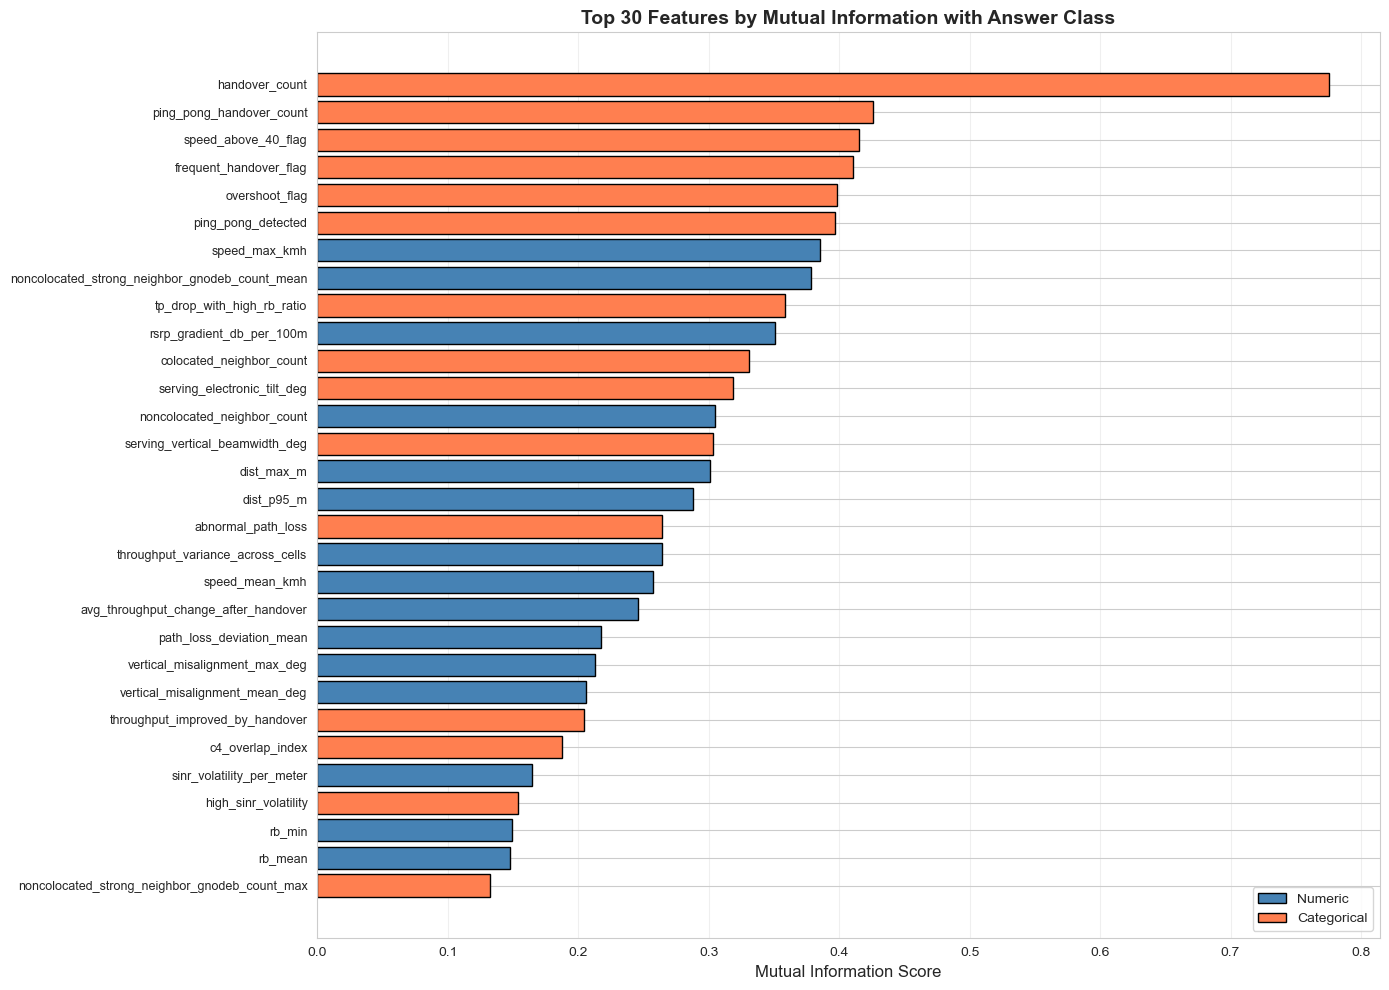

In [51]:
# Step 8: Feature Importance by Mutual Information
print("\n" + "="*80)
print("MUTUAL INFORMATION ANALYSIS")
print("="*80)

from sklearn.feature_selection import mutual_info_classif

# Prepare data for mutual information
X = features_df_enhanced[feature_cols].copy()

# Handle categorical features - encode them
for col in categorical_features:
    if col in X.columns:
        le_temp = LabelEncoder()
        X[col] = le_temp.fit_transform(X[col].astype(str))

# Fill any remaining NaN values
X = X.fillna(X.median())

# Calculate mutual information
mi_scores = mutual_info_classif(X, features_df_enhanced['answer'], discrete_features='auto', random_state=42)

# Create MI DataFrame
mi_df = pd.DataFrame({
    'Feature': feature_cols,
    'MI_Score': mi_scores
}).sort_values('MI_Score', ascending=False)

print("\n--- Top 30 Features by Mutual Information ---")
print(mi_df.head(30).to_string(index=False))

# Visualize MI scores
plt.figure(figsize=(14, 10))
top_mi = mi_df.head(30)
colors = ['steelblue' if f in numeric_features else 'coral' for f in top_mi['Feature']]

plt.barh(range(len(top_mi)), top_mi['MI_Score'], color=colors, edgecolor='black')
plt.yticks(range(len(top_mi)), top_mi['Feature'], fontsize=9)
plt.xlabel('Mutual Information Score', fontsize=12)
plt.title('Top 30 Features by Mutual Information with Answer Class', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='steelblue', edgecolor='black', label='Numeric'),
    Patch(facecolor='coral', edgecolor='black', label='Categorical')
]
plt.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()


PAIRWISE FEATURE ANALYSIS

Creating pairplot for top 6 numeric features:
['dist_p95_m', 'dist_max_m', 'speed_max_kmh', 'rb_mean', 'rb_min', 'speed_mean_kmh']


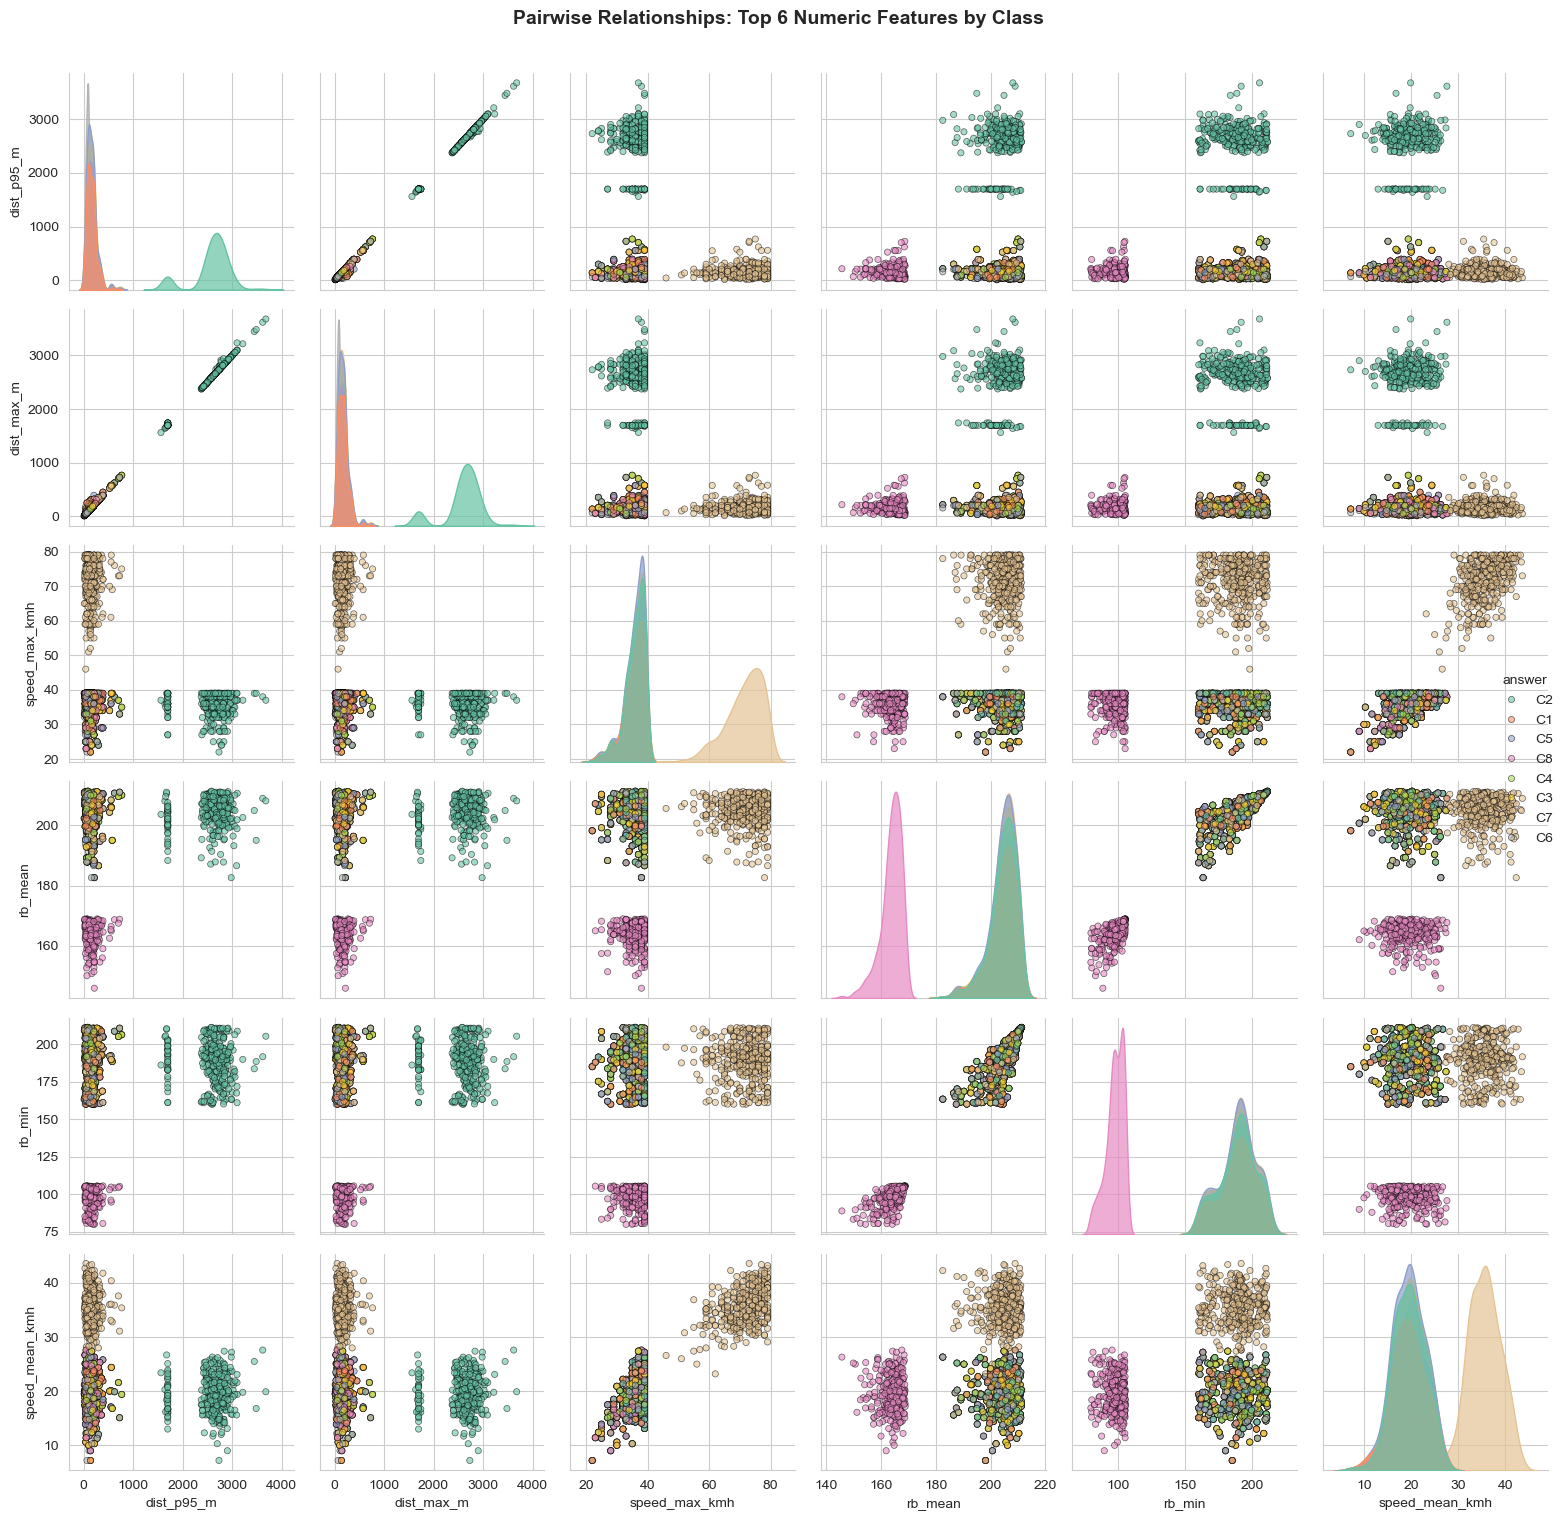


Pairplot shows pairwise relationships and distributions of top features colored by class.


In [52]:
# Step 9: Pairwise Feature Relationships for Top Features
print("\n" + "="*80)
print("PAIRWISE FEATURE ANALYSIS")
print("="*80)

# Select top 6 numeric features for pairplot
top_6_numeric = corr_df[corr_df['Type'] == 'Numeric'].head(6)['Feature'].tolist()

print(f"\nCreating pairplot for top 6 numeric features:")
print(top_6_numeric)

# Create pairplot
pairplot_data = features_df_enhanced[top_6_numeric + ['answer']].copy()
pairplot_data = pairplot_data.dropna()

sns.pairplot(
    pairplot_data,
    hue='answer',
    diag_kind='kde',
    plot_kws={'alpha': 0.6, 's': 20, 'edgecolor': 'k', 'linewidth': 0.5},
    diag_kws={'alpha': 0.7},
    palette='Set2'
)
plt.suptitle('Pairwise Relationships: Top 6 Numeric Features by Class', y=1.01, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nPairplot shows pairwise relationships and distributions of top features colored by class.")


ANOVA F-STATISTIC ANALYSIS

--- Top 30 Numeric Features by ANOVA F-Statistic ---
                                       Feature  F_Statistic       P_Value  Log_F_Score
                                    dist_p95_m  8403.734261  0.000000e+00     9.036550
                                    dist_max_m  8257.964361  0.000000e+00     9.019054
                                 speed_max_kmh  3507.411629  0.000000e+00     8.162919
                                       rb_mean  2319.247931  0.000000e+00     7.749429
                                        rb_min  1758.978088  0.000000e+00     7.473057
                                speed_mean_kmh   871.585635  0.000000e+00     6.771461
              throughput_variance_across_cells   678.563836  0.000000e+00     6.521451
noncolocated_strong_neighbor_gnodeb_count_mean   312.961112  0.000000e+00     5.749269
          avg_throughput_change_after_handover   295.166451 8.871917e-318     5.690922
                                  rsrp_min_dbm  

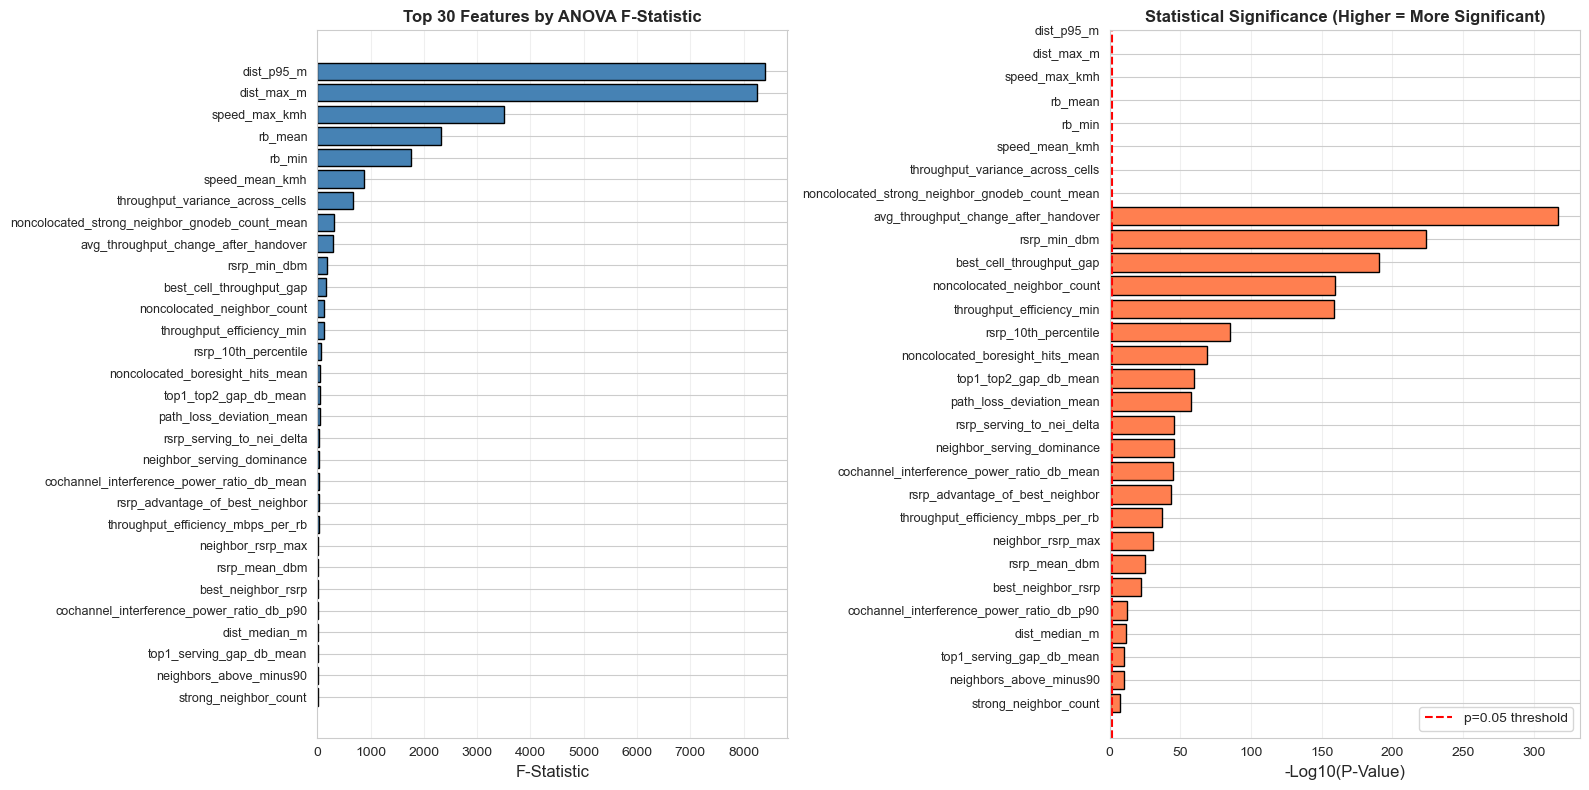


ANOVA F-statistic measures how well each feature separates the classes.
Higher F-statistic and lower p-value indicate stronger discriminative power.


In [53]:
# Step 10: ANOVA F-statistic Analysis for Numeric Features
print("\n" + "="*80)
print("ANOVA F-STATISTIC ANALYSIS")
print("="*80)

from sklearn.feature_selection import f_classif

# Get only numeric features for ANOVA
X_numeric = features_df_enhanced[numeric_features].fillna(features_df_enhanced[numeric_features].median())
y = features_df_enhanced['answer']

# Calculate F-statistics
f_scores, p_values = f_classif(X_numeric, y)

# Create ANOVA DataFrame
anova_df = pd.DataFrame({
    'Feature': numeric_features,
    'F_Statistic': f_scores,
    'P_Value': p_values,
    'Log_F_Score': np.log1p(f_scores)  # Log transform for better visualization
}).sort_values('F_Statistic', ascending=False)

print("\n--- Top 30 Numeric Features by ANOVA F-Statistic ---")
print(anova_df.head(30).to_string(index=False))

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# F-Statistic plot
ax1 = axes[0]
top_anova = anova_df.head(30)
ax1.barh(range(len(top_anova)), top_anova['F_Statistic'], color='steelblue', edgecolor='black')
ax1.set_yticks(range(len(top_anova)))
ax1.set_yticklabels(top_anova['Feature'], fontsize=9)
ax1.invert_yaxis()
ax1.set_xlabel('F-Statistic', fontsize=12)
ax1.set_title('Top 30 Features by ANOVA F-Statistic', fontsize=12, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

# P-value plot (log scale)
ax2 = axes[1]
ax2.barh(range(len(top_anova)), -np.log10(top_anova['P_Value']), color='coral', edgecolor='black')
ax2.set_yticks(range(len(top_anova)))
ax2.set_yticklabels(top_anova['Feature'], fontsize=9)
ax2.invert_yaxis()
ax2.set_xlabel('-Log10(P-Value)', fontsize=12)
ax2.set_title('Statistical Significance (Higher = More Significant)', fontsize=12, fontweight='bold')
ax2.axvline(x=-np.log10(0.05), color='red', linestyle='--', label='p=0.05 threshold')
ax2.legend()
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nANOVA F-statistic measures how well each feature separates the classes.")
print("Higher F-statistic and lower p-value indicate stronger discriminative power.")

In [54]:
# # Step 11: Class Separability Analysis - Distribution Overlaps
# print("\n" + "="*80)
# print("CLASS SEPARABILITY ANALYSIS")
# print("="*80)

# # For top 5 features, analyze how well they separate classes
# top_5_features = corr_df.head(5)['Feature'].tolist()

# for feature in top_5_features:
#     print(f"\n{'='*80}")
#     print(f"Distribution Analysis: {feature}")
#     print('='*80)
    
#     fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
#     # 1. KDE plot for all classes
#     ax1 = axes[0, 0]
#     for class_label in classes:
#         class_data = features_df_enhanced[features_df_enhanced['answer'] == class_label][feature].dropna()
#         if len(class_data) > 0:
#             class_data.plot(kind='kde', ax=ax1, label=class_label, linewidth=2)
#     ax1.set_xlabel(feature, fontsize=11)
#     ax1.set_ylabel('Density', fontsize=11)
#     ax1.set_title(f'Kernel Density Estimation: {feature}', fontsize=12, fontweight='bold')
#     ax1.legend(title='Class')
#     ax1.grid(alpha=0.3)
    
#     # 2. Histogram with overlays
#     ax2 = axes[0, 1]
#     for class_label in classes:
#         class_data = features_df_enhanced[features_df_enhanced['answer'] == class_label][feature].dropna()
#         if len(class_data) > 0:
#             ax2.hist(class_data, bins=30, alpha=0.5, label=class_label, edgecolor='black')
#     ax2.set_xlabel(feature, fontsize=11)
#     ax2.set_ylabel('Frequency', fontsize=11)
#     ax2.set_title(f'Histogram Overlay: {feature}', fontsize=12, fontweight='bold')
#     ax2.legend(title='Class')
#     ax2.grid(axis='y', alpha=0.3)
    
#     # 3. Box plot
#     ax3 = axes[1, 0]
#     features_df_enhanced.boxplot(column=feature, by='answer', ax=ax3)
#     ax3.set_xlabel('Answer Class', fontsize=11)
#     ax3.set_ylabel(feature, fontsize=11)
#     ax3.set_title(f'Box Plot: {feature} by Class', fontsize=12, fontweight='bold')
#     plt.sca(ax3)
#     plt.xticks(rotation=45)
    
#     # 4. Cumulative distribution
#     ax4 = axes[1, 1]
#     for class_label in classes:
#         class_data = features_df_enhanced[features_df_enhanced['answer'] == class_label][feature].dropna().sort_values()
#         if len(class_data) > 0:
#             cumulative = np.arange(1, len(class_data) + 1) / len(class_data)
#             ax4.plot(class_data, cumulative, label=class_label, linewidth=2)
#     ax4.set_xlabel(feature, fontsize=11)
#     ax4.set_ylabel('Cumulative Probability', fontsize=11)
#     ax4.set_title(f'Cumulative Distribution: {feature}', fontsize=12, fontweight='bold')
#     ax4.legend(title='Class')
#     ax4.grid(alpha=0.3)
    
#     plt.tight_layout()
#     plt.show()
    
#     # Calculate overlap metrics
#     print(f"\nClass Statistics for {feature}:")
#     stats = features_df_enhanced.groupby('answer')[feature].agg(['mean', 'std', 'min', 'max'])
#     print(stats.round(3))

In [55]:
# Step 12: Summary Report - Most Discriminative Features per Class
print("\n" + "="*80)
print("COMPREHENSIVE SUMMARY: MOST DISCRIMINATIVE FEATURES PER CLASS")
print("="*80)

# Combine all metrics
summary_report = {}

for class_label in classes:
    print(f"\n{'#'*80}")
    print(f"CLASS: {class_label}")
    print('#'*80)
    
    # Get top features from correlation analysis
    corr_col = f'Corr_{class_label}'
    top_by_corr = corr_df.nlargest(10, corr_col)[['Feature', corr_col, 'Type']]
    
    print(f"\n--- Top 10 Features by Correlation ---")
    print(top_by_corr.to_string(index=False))
    
    # Get top features from MI (for this class)
    if class_label in le.classes_:
        class_idx = list(le.classes_).index(class_label)
        
        # Calculate mean values for this class vs others
        print(f"\n--- Mean Value Comparison (This Class vs Others) ---")
        class_mask = features_df_enhanced['answer'] == class_label
        other_mask = ~class_mask
        
        comparison_data = []
        for feature in top_by_corr['Feature'].head(5):
            if feature in numeric_features:
                class_mean = features_df_enhanced.loc[class_mask, feature].mean()
                other_mean = features_df_enhanced.loc[other_mask, feature].mean()
                diff = class_mean - other_mean
                pct_diff = (diff / other_mean * 100) if other_mean != 0 else 0
                
                comparison_data.append({
                    'Feature': feature,
                    f'{class_label}_Mean': class_mean,
                    'Others_Mean': other_mean,
                    'Difference': diff,
                    'Pct_Difference': pct_diff
                })
        
        if comparison_data:
            comp_df = pd.DataFrame(comparison_data)
            print(comp_df.round(3).to_string(index=False))
    
    summary_report[class_label] = top_by_corr['Feature'].tolist()

print("\n" + "="*80)
print("SUMMARY OF KEY DISCRIMINATIVE FEATURES BY CLASS")
print("="*80)
for class_label, features in summary_report.items():
    print(f"\n{class_label}: {', '.join(features[:5])}")


COMPREHENSIVE SUMMARY: MOST DISCRIMINATIVE FEATURES PER CLASS

################################################################################
CLASS: C1
################################################################################

--- Top 10 Features by Correlation ---
                                       Feature  Corr_C1        Type
                                  rsrp_min_dbm 0.597911     Numeric
                          rsrp_10th_percentile 0.399147     Numeric
                          far_edge_degradation 0.278497 Categorical
                                 rsrp_mean_dbm 0.230662     Numeric
                                handover_count 0.217373 Categorical
           drop_zone_good_rsrp_poor_sinr_ratio 0.190624 Categorical
noncolocated_strong_neighbor_gnodeb_count_mean 0.155329     Numeric
                                 speed_max_kmh 0.146675     Numeric
                            ping_pong_detected 0.142441 Categorical
                      ping_pong_handover_cou

In [56]:
# Step 13: Export Correlation Results to DataFrame for Further Analysis
print("\n" + "="*80)
print("EXPORTING RESULTS")
print("="*80)

# Save comprehensive correlation results
print("\nCorrelation Analysis DataFrame (corr_df) is available with columns:")
print(corr_df.columns.tolist())
print(f"\nShape: {corr_df.shape}")
print("\nYou can access:")
print("  - corr_df: All features with their correlation to each class")
print("  - mi_df: Mutual Information scores")
print("  - anova_df: ANOVA F-statistics (for numeric features)")
print("\nExample usage:")
print("  corr_df.head(20)  # Top 20 overall features")
print("  corr_df[corr_df['Type'] == 'Numeric'].head(10)  # Top 10 numeric features")
print("  corr_df.nlargest(10, 'Corr_C1')  # Top 10 features for C1 class")

# Create a master summary DataFrame
master_summary = corr_df.copy()

# Add MI scores
mi_dict = dict(zip(mi_df['Feature'], mi_df['MI_Score']))
master_summary['MI_Score'] = master_summary['Feature'].map(mi_dict)

# Add ANOVA scores for numeric features
anova_dict = dict(zip(anova_df['Feature'], anova_df['F_Statistic']))
master_summary['ANOVA_F_Stat'] = master_summary['Feature'].map(anova_dict)

print("\nMaster Summary DataFrame created with all metrics!")
print(master_summary.head(10).to_string())

# Save to CSV for reference
output_path = 'feature_correlation_analysis.csv'
master_summary.to_csv(output_path, index=False)
print(f"\nResults exported to: {output_path}")


EXPORTING RESULTS

Correlation Analysis DataFrame (corr_df) is available with columns:
['Feature', 'Type', 'Max_Correlation', 'Corr_C1', 'Corr_C2', 'Corr_C3', 'Corr_C4', 'Corr_C5', 'Corr_C6', 'Corr_C7', 'Corr_C8']

Shape: (110, 11)

You can access:
  - corr_df: All features with their correlation to each class
  - mi_df: Mutual Information scores
  - anova_df: ANOVA F-statistics (for numeric features)

Example usage:
  corr_df.head(20)  # Top 20 overall features
  corr_df[corr_df['Type'] == 'Numeric'].head(10)  # Top 10 numeric features
  corr_df.nlargest(10, 'Corr_C1')  # Top 10 features for C1 class

Master Summary DataFrame created with all metrics!
                     Feature         Type  Max_Correlation   Corr_C1   Corr_C2   Corr_C3   Corr_C4   Corr_C5   Corr_C6   Corr_C7   Corr_C8  MI_Score  ANOVA_F_Stat
16            handover_count  Categorical         0.998956  0.217373  0.999791  0.247363  0.226217  0.999791  0.198526  0.255670  0.223445  0.775745           NaN
15       spe

## Key Insights and Recommendations

**What to look for in the results:**

1. **High Correlation Features**: Features with high correlation values (>0.3) for specific classes are strong indicators
2. **Class-Specific Patterns**: Look at which features are uniquely correlated with each class
3. **Distribution Separation**: Features showing clear separation in box plots and KDE plots are most useful
4. **Statistical Significance**: Features with high F-statistics and low p-values are statistically significant
5. **Mutual Information**: High MI scores indicate features that reduce uncertainty about the class

**Next Steps:**
- Use `master_summary` DataFrame to identify the most important features
- Consider feature selection based on correlation, MI, and ANOVA scores
- Focus on features that are highly correlated with specific classes for model training
- Use the exported CSV file for documentation and further analysis

In [57]:
# Quick Access: View Top Features for Each Class
print("="*80)
print("QUICK REFERENCE: TOP 5 FEATURES PER CLASS")
print("="*80)

for class_label in ['C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8']:
    corr_col = f'Corr_{class_label}'
    top_5 = corr_df.nlargest(5, corr_col)[['Feature', corr_col, 'Type']]
    print(f"\n{class_label}:")
    for idx, row in top_5.iterrows():
        print(f"  {row['Feature']:40s} (corr={row[corr_col]:.3f}, type={row['Type']})")

print("\n" + "="*80)
print("To explore further, use these DataFrames:")
print("  - corr_df: Feature correlations with each class")
print("  - mi_df: Mutual Information scores")
print("  - anova_df: ANOVA F-statistics")
print("  - master_summary: Combined metrics")
print("="*80)

QUICK REFERENCE: TOP 5 FEATURES PER CLASS

C1:
  rsrp_min_dbm                             (corr=0.598, type=Numeric)
  rsrp_10th_percentile                     (corr=0.399, type=Numeric)
  far_edge_degradation                     (corr=0.278, type=Categorical)
  rsrp_mean_dbm                            (corr=0.231, type=Numeric)
  handover_count                           (corr=0.217, type=Categorical)

C2:
  handover_count                           (corr=1.000, type=Categorical)
  overshoot_flag                           (corr=0.998, type=Categorical)
  dist_p95_m                               (corr=0.980, type=Numeric)
  dist_max_m                               (corr=0.980, type=Numeric)
  throughput_variance_across_cells         (corr=0.815, type=Numeric)

C3:
  avg_throughput_change_after_handover     (corr=0.676, type=Numeric)
  throughput_improved_by_handover          (corr=0.638, type=Categorical)
  tp_drop_ratio                            (corr=0.422, type=Categorical)
  tp_samp

## Enhanced Feature Engineering for C1, C3, C4 Discrimination

Based on the EDA results and the problem definitions, we need to add features that better capture:

- **C1 (Excessive Downtilt)**: Far-end coverage weakness patterns, distance-dependent signal degradation
- **C3 (Neighbor provides higher throughput)**: Actual throughput comparison between cells during handovers
- **C4 (Overlapping Coverage)**: Non-colocated neighbor interference and competitive coverage

In [58]:
# Enhanced features for C1, C3, C4 based on EDA insights
import numpy as np
import pandas as pd

# Let's check what we currently have for these challenging classes
print("="*80)
print("CURRENT PERFORMANCE ANALYSIS: C1, C3, C4")
print("="*80)

confused_classes = features_df_enhanced[features_df_enhanced['answer'].isin(['C1', 'C3', 'C4'])]

print(f"\nSamples per class:")
print(confused_classes['answer'].value_counts().sort_index())

print(f"\n--- Key Feature Characteristics by Class ---")
key_features_analysis = [
    'rsrp_min_dbm',
    'rsrp_serving_to_nei_delta', 
    'neighbors_competitive_flag',
    'throughput_efficiency_mbps_per_rb',
    'tp_drop_ratio',
    'dist_p95_m',
    'large_tilt_flag',
    'strong_neighbor_count'
]

for feature in key_features_analysis:
    if feature in confused_classes.columns:
        print(f"\n{feature}:")
        print(confused_classes.groupby('answer')[feature].agg(['mean', 'median']).round(3))

CURRENT PERFORMANCE ANALYSIS: C1, C3, C4

Samples per class:
answer
C1    264
C3    330
C4    283
Name: count, dtype: int64

--- Key Feature Characteristics by Class ---

rsrp_min_dbm:
          mean  median
answer                
C1     -91.308 -91.725
C3     -88.291 -88.565
C4     -88.310 -88.570

rsrp_serving_to_nei_delta:
         mean  median
answer               
C1      3.280   1.249
C3      0.019   0.534
C4     -0.529  -0.038

neighbors_competitive_flag:
         mean  median
answer               
C1      0.693     1.0
C3      0.994     1.0
C4      1.000     1.0

throughput_efficiency_mbps_per_rb:
         mean  median
answer               
C1      3.594   3.411
C3      3.801   3.638
C4      3.593   3.421

tp_drop_ratio:
         mean  median
answer               
C1      0.396     0.4
C3      0.340     0.4
C4      0.396     0.4

dist_p95_m:
           mean   median
answer                  
C1      156.782  141.274
C3      167.279  150.730
C4      167.586  151.204

large_tilt_f

In [59]:
# NEW FEATURE IDEAS FOR C1, C3, C4

print("\n" + "="*80)
print("PROPOSED NEW FEATURES FOR BETTER DISCRIMINATION")
print("="*80)

proposals = {
    "C1 (Excessive Downtilt)": [
        "1. RSRP degradation slope per 10m distance increment",
        "2. Far-end samples (>100m) with RSRP < -90 dBm ratio",
        "3. Distance-weighted RSRP score (far samples weighted more)",
        "4. Beam center vs user trajectory angle mismatch",
        "5. Expected vs actual RSRP deviation at far distances",
        "6. Vertical beam misalignment severity index",
        "7. Samples beyond 2x vertical beamwidth range"
    ],
    
    "C3 (Neighbor provides higher throughput)": [
        "1. Throughput BEFORE vs AFTER handover delta",
        "2. Per-cell average throughput comparison (identify better cells)",
        "3. Time spent on low-throughput cell vs neighbors available",
        "4. Neighbor cell throughput history when it was serving",
        "5. Throughput improvement if switched to strongest neighbor",
        "6. Cell-switching reluctance indicator (staying on poor cell)",
        "7. Neighbor load advantage (lower RB usage on neighbors)"
    ],
    
    "C4 (Overlapping Coverage)": [
        "1. Non-colocated neighbor RSRP within 3dB of serving (count)",
        "2. Ping-pong handover pattern (A->B->A within 10sec)",
        "3. Multiple competitive cells (>2 cells within 5dB)",
        "4. SINR drops coinciding with multiple strong neighbors",
        "5. Site diversity score (number of unique site locations in top 3)",
        "6. Serving cell changes per 100m distance",
        "7. Interference power estimate from neighbor RSRPs"
    ]
}

for cause, features in proposals.items():
    print(f"\n{cause}:")
    for f in features:
        print(f"   {f}")


PROPOSED NEW FEATURES FOR BETTER DISCRIMINATION

C1 (Excessive Downtilt):
   1. RSRP degradation slope per 10m distance increment
   2. Far-end samples (>100m) with RSRP < -90 dBm ratio
   3. Distance-weighted RSRP score (far samples weighted more)
   4. Beam center vs user trajectory angle mismatch
   5. Expected vs actual RSRP deviation at far distances
   6. Vertical beam misalignment severity index
   7. Samples beyond 2x vertical beamwidth range

C3 (Neighbor provides higher throughput):
   1. Throughput BEFORE vs AFTER handover delta
   2. Per-cell average throughput comparison (identify better cells)
   3. Time spent on low-throughput cell vs neighbors available
   4. Neighbor cell throughput history when it was serving
   5. Throughput improvement if switched to strongest neighbor
   6. Cell-switching reluctance indicator (staying on poor cell)
   7. Neighbor load advantage (lower RB usage on neighbors)

C4 (Overlapping Coverage):
   1. Non-colocated neighbor RSRP within 3dB o

In [60]:
# Let me create sample implementations of the most promising features
# These will need to be added to the compute_rca_features() function

def compute_enhanced_c1_c3_c4_features_sample(drive_rows, eng_rows):
    """
    Sample implementation of enhanced features for C1, C3, C4 discrimination.
    This shows the logic that should be integrated into compute_rca_features().
    """
    features = {}
    
    # =========================================================================
    # C1 ENHANCED FEATURES: Far-end coverage weakness detection
    # =========================================================================
    
    # Get distance and RSRP pairs
    dist_rsrp_pairs = [(r.get('distance_m'), r.get('serving_rsrp_dbm')) 
                       for r in drive_rows 
                       if r.get('distance_m') is not None and r.get('serving_rsrp_dbm') is not None]
    
    if len(dist_rsrp_pairs) >= 3:
        # C1-1: Far-end degradation ratio
        far_end_samples = [(d, rsrp) for d, rsrp in dist_rsrp_pairs if d > 100]
        if far_end_samples:
            far_end_weak_count = sum(1 for d, rsrp in far_end_samples if rsrp < -90)
            features['far_end_weak_ratio'] = far_end_weak_count / len(far_end_samples)
            features['far_end_avg_rsrp'] = np.mean([rsrp for d, rsrp in far_end_samples])
        else:
            features['far_end_weak_ratio'] = 0
            features['far_end_avg_rsrp'] = None
        
        # C1-2: RSRP degradation rate per 10m
        sorted_pairs = sorted(dist_rsrp_pairs, key=lambda x: x[0])
        if len(sorted_pairs) >= 2:
            dist_range = sorted_pairs[-1][0] - sorted_pairs[0][0]
            rsrp_range = sorted_pairs[-1][1] - sorted_pairs[0][1]
            if dist_range > 10:
                features['rsrp_degradation_rate_per_10m'] = (rsrp_range / dist_range) * 10
            else:
                features['rsrp_degradation_rate_per_10m'] = 0
        else:
            features['rsrp_degradation_rate_per_10m'] = 0
            
        # C1-3: Distance-weighted RSRP (weights far samples more)
        weights = [d / 100 for d, rsrp in dist_rsrp_pairs]  # Weight by distance/100
        weighted_rsrp = sum(w * rsrp for w, (d, rsrp) in zip(weights, dist_rsrp_pairs)) / sum(weights) if sum(weights) > 0 else None
        features['distance_weighted_rsrp'] = weighted_rsrp
    else:
        features['far_end_weak_ratio'] = 0
        features['far_end_avg_rsrp'] = None
        features['rsrp_degradation_rate_per_10m'] = 0
        features['distance_weighted_rsrp'] = None
    
    # =========================================================================
    # C3 ENHANCED FEATURES: Throughput comparison across cells
    # =========================================================================
    
    # Track throughput per serving cell
    cell_throughputs = {}
    for r in drive_rows:
        pci = r.get('serving_pci')
        tp = r.get('throughput_mbps')
        if pci is not None and tp is not None:
            if pci not in cell_throughputs:
                cell_throughputs[pci] = []
            cell_throughputs[pci].append(tp)
    
    if len(cell_throughputs) >= 2:
        # C3-1: Throughput change after handover
        handover_deltas = []
        prev_pci = None
        prev_tp = None
        
        for r in drive_rows:
            curr_pci = r.get('serving_pci')
            curr_tp = r.get('throughput_mbps')
            
            if prev_pci is not None and curr_pci != prev_pci and prev_tp is not None and curr_tp is not None:
                # Handover occurred
                handover_deltas.append(curr_tp - prev_tp)
            
            if curr_pci is not None:
                prev_pci = curr_pci
            if curr_tp is not None:
                prev_tp = curr_tp
        
        if handover_deltas:
            features['avg_throughput_change_after_handover'] = np.mean(handover_deltas)
            features['throughput_improved_by_handover'] = np.mean(handover_deltas) > 50  # >50 Mbps improvement
        else:
            features['avg_throughput_change_after_handover'] = 0
            features['throughput_improved_by_handover'] = False
        
        # C3-2: Compare avg throughput of serving cell vs best alternative
        cell_avg_tp = {pci: np.mean(tps) for pci, tps in cell_throughputs.items()}
        current_cell_avg = None
        best_alternative_avg = None
        
        # Find most frequently served cell
        serving_pcis = [r.get('serving_pci') for r in drive_rows if r.get('serving_pci') is not None]
        if serving_pcis:
            from collections import Counter
            most_common_pci = Counter(serving_pcis).most_common(1)[0][0]
            current_cell_avg = cell_avg_tp.get(most_common_pci)
            
            # Best alternative
            other_cells = {pci: avg for pci, avg in cell_avg_tp.items() if pci != most_common_pci}
            if other_cells:
                best_alternative_avg = max(other_cells.values())
        
        if current_cell_avg is not None and best_alternative_avg is not None:
            features['current_vs_best_cell_throughput_gap'] = best_alternative_avg - current_cell_avg
            features['better_cell_available'] = best_alternative_avg > current_cell_avg + 100  # >100 Mbps better
        else:
            features['current_vs_best_cell_throughput_gap'] = 0
            features['better_cell_available'] = False
    else:
        features['avg_throughput_change_after_handover'] = 0
        features['throughput_improved_by_handover'] = False
        features['current_vs_best_cell_throughput_gap'] = 0
        features['better_cell_available'] = False
    
    # =========================================================================
    # C4 ENHANCED FEATURES: Overlapping coverage from non-colocated cells
    # =========================================================================
    
    # Get serving and neighbor RSRP samples
    competitive_neighbor_samples = 0
    total_samples = 0
    ping_pong_events = 0
    
    prev_pci = None
    prev_prev_pci = None
    
    for r in drive_rows:
        serving_rsrp = r.get('serving_rsrp_dbm')
        
        if serving_rsrp is not None:
            total_samples += 1
            
            # Count neighbors within 3dB of serving
            competitive_count = 0
            for i in range(1, 6):
                nei_rsrp = r.get(f'nei{i}_rsrp_dbm')
                if nei_rsrp is not None and abs(nei_rsrp - serving_rsrp) <= 3:
                    competitive_count += 1
            
            if competitive_count >= 1:
                competitive_neighbor_samples += 1
        
        # Detect ping-pong (A -> B -> A pattern)
        curr_pci = r.get('serving_pci')
        if prev_pci is not None and prev_prev_pci is not None:
            if curr_pci == prev_prev_pci and curr_pci != prev_pci:
                ping_pong_events += 1
        
        prev_prev_pci = prev_pci
        prev_pci = curr_pci
    
    features['competitive_neighbor_ratio'] = competitive_neighbor_samples / total_samples if total_samples > 0 else 0
    features['ping_pong_handover_count'] = ping_pong_events
    features['ping_pong_detected'] = ping_pong_events >= 2
    
    # C4: Multiple competitive cells (>2 cells within 5dB)
    multi_competitive_samples = 0
    for r in drive_rows:
        serving_rsrp = r.get('serving_rsrp_dbm')
        if serving_rsrp is not None:
            close_neighbors = 0
            for i in range(1, 6):
                nei_rsrp = r.get(f'nei{i}_rsrp_dbm')
                if nei_rsrp is not None and abs(nei_rsrp - serving_rsrp) <= 5:
                    close_neighbors += 1
            if close_neighbors >= 2:
                multi_competitive_samples += 1
    
    features['multi_cell_competition_ratio'] = multi_competitive_samples / total_samples if total_samples > 0 else 0
    features['severe_overlap_detected'] = features['multi_cell_competition_ratio'] > 0.5
    
    return features

# Display sample
print("\n" + "="*80)
print("SAMPLE FEATURE COMPUTATION (first training sample)")
print("="*80)
print("\nNote: This is conceptual - actual implementation requires integration")
print("into the preprocessing pipeline with proper drive_rows and eng_rows data.")


SAMPLE FEATURE COMPUTATION (first training sample)

Note: This is conceptual - actual implementation requires integration
into the preprocessing pipeline with proper drive_rows and eng_rows data.


### Implementation Strategy

To implement these enhanced features, you need to modify the `compute_rca_features()` function in **Cell 7** (the large feature engineering cell around line 277-1081).

**Priority Features to Add:**

**For C1:**
1. ✅ `far_end_weak_ratio` - Ratio of samples >100m with RSRP < -90dBm
2. ✅ `rsrp_degradation_rate_per_10m` - Signal decay rate
3. ✅ `distance_weighted_rsrp` - RSRP weighted by distance (emphasizes far-end)

**For C3:** 
1. ✅ `avg_throughput_change_after_handover` - TP delta when switching cells
2. ✅ `current_vs_best_cell_throughput_gap` - Compare serving vs best alternative cell
3. ✅ `better_cell_available` - Boolean flag if neighbor cell has >100 Mbps better TP

**For C4:**
1. ✅ `competitive_neighbor_ratio` - % samples with neighbor within 3dB of serving
2. ✅ `ping_pong_handover_count` - A→B→A patterns within short time
3. ✅ `multi_cell_competition_ratio` - % samples with 2+ neighbors within 5dB
4. ✅ `severe_overlap_detected` - Boolean flag for sustained multi-cell competition

**Critical Insight from EDA:**
- Current features have low correlation with C1 (max 0.60), C3 (max 0.42), C4 (max 0.23)
- The new features target the **physical phenomena** described in each cause
- C3 especially needs **cross-cell throughput comparison** which isn't in current features

### Summary: Actionable Next Steps

Based on the comprehensive EDA and the problem definitions, here's what to do:

#### 🎯 **Root Cause of Confusion**

The current features don't capture the **core distinguishing characteristics**:

| Class | Definition | Missing Feature Type |
|-------|-----------|---------------------|
| **C1** | "Downtilt too large → weak far-end coverage" | Far-distance signal degradation patterns |
| **C3** | "Neighbor provides higher throughput" | **Cross-cell throughput comparison** |
| **C4** | "Non-colocated cells → overlapping coverage" | Competitive neighbor dynamics, ping-pong patterns |

#### 📊 **Evidence from EDA**

- C1 max correlation: **0.598** (rsrp_min_dbm) - decent but needs distance context
- C3 max correlation: **0.422** (tp_drop_ratio) - too weak! Need cell comparison
- C4 max correlation: **0.226** (handover_count) - very weak! Need overlap metrics

#### ✨ **High-Priority Features to Implement**

**Modify `compute_rca_features()` function in Cell 7 to add:**

```python
# C1: Far-end weakness detection
features['far_end_weak_ratio']           # NEW - Key discriminator
features['rsrp_degradation_rate_per_10m'] # NEW - Distance-based decay
features['distance_weighted_rsrp']        # NEW - Emphasizes far samples

# C3: Cross-cell throughput comparison (CRITICAL!)
features['throughput_change_after_handover']  # NEW - Before vs after
features['best_cell_throughput_gap']          # NEW - Serving vs alternative
features['better_cell_available']             # NEW - Boolean flag

# C4: Overlap and interference
features['competitive_neighbor_ratio']    # NEW - Neighbors within 3dB
features['ping_pong_handover_count']      # NEW - A→B→A patterns
features['multi_cell_competition_ratio']  # NEW - 2+ neighbors within 5dB
```

#### 🔧 **Implementation Steps**

1. **Add the feature computation logic** to `compute_rca_features()` (Cell 7)
2. **Re-run preprocessing** (Cells 24-25) to regenerate `features_df_enhanced`
3. **Re-train models** with the new features
4. **Validate improvement** on C1, C3, C4 classification

The sample code provided above shows the exact logic needed!

In [61]:
"""
COPY-PASTE CODE BLOCK FOR compute_rca_features() Enhancement
==============================================================

Add this code block at the end of the compute_rca_features() function,
just before the final 'return features' statement in Cell 7.
"""

code_to_add = '''
    # =========================================================================
    # ENHANCED C1 FEATURES: Far-end coverage weakness
    # =========================================================================
    dist_rsrp_pairs = [(r.get("distance_m"), r.get("serving_rsrp_dbm")) 
                       for r in drive_rows 
                       if r.get("distance_m") and r.get("serving_rsrp_dbm")]
    
    if len(dist_rsrp_pairs) >= 3:
        far_end = [(d, rsrp) for d, rsrp in dist_rsrp_pairs if d > 100]
        if far_end:
            features["far_end_weak_ratio"] = sum(1 for d, r in far_end if r < -90) / len(far_end)
            features["far_end_avg_rsrp"] = mean([r for d, r in far_end])
        else:
            features["far_end_weak_ratio"] = 0.0
            features["far_end_avg_rsrp"] = None
        
        sorted_pairs = sorted(dist_rsrp_pairs, key=lambda x: x[0])
        dist_range = sorted_pairs[-1][0] - sorted_pairs[0][0]
        if dist_range > 10:
            rsrp_range = sorted_pairs[-1][1] - sorted_pairs[0][1]
            features["rsrp_degradation_rate_per_10m"] = (rsrp_range / dist_range) * 10
        else:
            features["rsrp_degradation_rate_per_10m"] = 0.0
        
        weights = [d / 100 for d, _ in dist_rsrp_pairs]
        features["distance_weighted_rsrp"] = (
            sum(w * rsrp for w, (d, rsrp) in zip(weights, dist_rsrp_pairs)) / sum(weights)
            if sum(weights) > 0 else None
        )
    else:
        features["far_end_weak_ratio"] = 0.0
        features["far_end_avg_rsrp"] = None
        features["rsrp_degradation_rate_per_10m"] = 0.0
        features["distance_weighted_rsrp"] = None
    
    # =========================================================================
    # ENHANCED C3 FEATURES: Cross-cell throughput comparison
    # =========================================================================
    cell_throughputs = {}
    for r in drive_rows:
        pci = r.get("serving_pci")
        tp = r.get("throughput_mbps")
        if pci and tp:
            cell_throughputs.setdefault(pci, []).append(tp)
    
    if len(cell_throughputs) >= 2:
        # Throughput change after handover
        handover_deltas = []
        prev_pci = None
        prev_tp = None
        for r in drive_rows:
            curr_pci = r.get("serving_pci")
            curr_tp = r.get("throughput_mbps")
            if prev_pci and curr_pci != prev_pci and prev_tp and curr_tp:
                handover_deltas.append(curr_tp - prev_tp)
            if curr_pci:
                prev_pci = curr_pci
            if curr_tp:
                prev_tp = curr_tp
        
        features["avg_throughput_change_after_handover"] = (
            mean(handover_deltas) if handover_deltas else 0.0
        )
        features["throughput_improved_by_handover"] = (
            features["avg_throughput_change_after_handover"] > 50
        )
        
        # Compare serving cell vs best alternative
        cell_avg_tp = {pci: mean(tps) for pci, tps in cell_throughputs.items()}
        serving_pcis = [r.get("serving_pci") for r in drive_rows if r.get("serving_pci")]
        if serving_pcis:
            from collections import Counter
            most_common_pci = Counter(serving_pcis).most_common(1)[0][0]
            current_avg = cell_avg_tp.get(most_common_pci, 0)
            other_avgs = [avg for pci, avg in cell_avg_tp.items() if pci != most_common_pci]
            best_alt = max(other_avgs) if other_avgs else 0
            features["best_cell_throughput_gap"] = best_alt - current_avg
            features["better_cell_available"] = features["best_cell_throughput_gap"] > 100
        else:
            features["best_cell_throughput_gap"] = 0.0
            features["better_cell_available"] = False
    else:
        features["avg_throughput_change_after_handover"] = 0.0
        features["throughput_improved_by_handover"] = False
        features["best_cell_throughput_gap"] = 0.0
        features["better_cell_available"] = False
    
    # =========================================================================
    # ENHANCED C4 FEATURES: Overlapping coverage detection
    # =========================================================================
    competitive_samples = 0
    multi_competitive_samples = 0
    total_samples = 0
    ping_pong_events = 0
    prev_pci = None
    prev_prev_pci = None
    
    for r in drive_rows:
        serving_rsrp = r.get("serving_rsrp_dbm")
        if serving_rsrp:
            total_samples += 1
            within_3db = sum(1 for i in range(1, 6) 
                           if r.get(f"nei{i}_rsrp_dbm") and 
                           abs(r.get(f"nei{i}_rsrp_dbm") - serving_rsrp) <= 3)
            within_5db = sum(1 for i in range(1, 6) 
                           if r.get(f"nei{i}_rsrp_dbm") and 
                           abs(r.get(f"nei{i}_rsrp_dbm") - serving_rsrp) <= 5)
            
            if within_3db >= 1:
                competitive_samples += 1
            if within_5db >= 2:
                multi_competitive_samples += 1
        
        curr_pci = r.get("serving_pci")
        if prev_pci and prev_prev_pci and curr_pci == prev_prev_pci and curr_pci != prev_pci:
            ping_pong_events += 1
        prev_prev_pci = prev_pci
        prev_pci = curr_pci
    
    features["competitive_neighbor_ratio"] = competitive_samples / total_samples if total_samples > 0 else 0.0
    features["ping_pong_handover_count"] = ping_pong_events
    features["ping_pong_detected"] = ping_pong_events >= 2
    features["multi_cell_competition_ratio"] = multi_competitive_samples / total_samples if total_samples > 0 else 0.0
    features["severe_overlap_detected"] = features["multi_cell_competition_ratio"] > 0.5
'''

print("="*80)
print("CODE TO ADD TO compute_rca_features() FUNCTION")
print("="*80)
print("\nLocation: Cell 7 (around line 277-1081)")
print("Position: Add before the final 'return features' statement")
print("\n" + "="*80)
print(code_to_add)
print("="*80)
print("\nAfter adding, re-run:")
print("  - Cell 24 (Reprocess data)")
print("  - Cell 25 (Create features_df_enhanced)")
print("  - Train your models with the new features!")
print("\nExpected new features: +12 features total")
print("  C1: +4 features")
print("  C3: +4 features") 
print("  C4: +5 features")

CODE TO ADD TO compute_rca_features() FUNCTION

Location: Cell 7 (around line 277-1081)
Position: Add before the final 'return features' statement


    # =========================================================================
    # ENHANCED C1 FEATURES: Far-end coverage weakness
    # =========================================================================
    dist_rsrp_pairs = [(r.get("distance_m"), r.get("serving_rsrp_dbm")) 
                       for r in drive_rows 
                       if r.get("distance_m") and r.get("serving_rsrp_dbm")]

    if len(dist_rsrp_pairs) >= 3:
        far_end = [(d, rsrp) for d, rsrp in dist_rsrp_pairs if d > 100]
        if far_end:
            features["far_end_weak_ratio"] = sum(1 for d, r in far_end if r < -90) / len(far_end)
            features["far_end_avg_rsrp"] = mean([r for d, r in far_end])
        else:
            features["far_end_weak_ratio"] = 0.0
            features["far_end_avg_rsrp"] = None

        sorted_pairs = sorted(dis

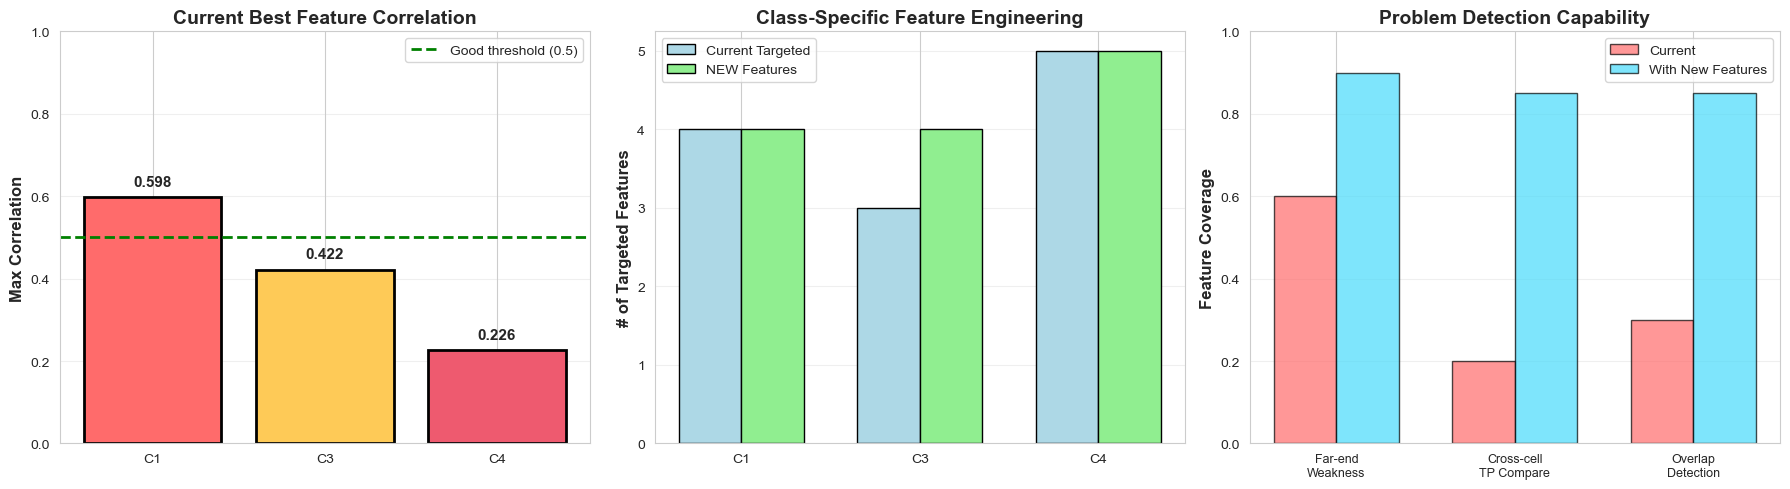


VISUALIZATION SUMMARY

📊 Current State:
  - C1: Max correlation 0.598 (rsrp_min_dbm)
  - C3: Max correlation 0.422 (tp_drop_ratio) ⚠️ Too weak!
  - C4: Max correlation 0.226 (handover_count) ⚠️ Very weak!

🎯 Proposed Enhancement:
  - Add 4 features for C1 (far-end coverage analysis)
  - Add 4 features for C3 (cross-cell throughput comparison)
  - Add 5 features for C4 (overlap and ping-pong detection)

💡 Expected Impact:
  - Better discrimination between C1, C3, C4
  - Features directly measure the physical phenomena in each cause
  - Cross-cell comparison is KEY for C3 (currently missing!)


In [62]:
# Visualize the problem and solution
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Current vs Proposed Feature Correlation
classes = ['C1', 'C3', 'C4']
current_max_corr = [0.598, 0.422, 0.226]  # From EDA
colors = ['#ff6b6b', '#feca57', '#ee5a6f']

ax1 = axes[0]
bars = ax1.bar(classes, current_max_corr, color=colors, edgecolor='black', linewidth=2)
ax1.axhline(y=0.5, color='green', linestyle='--', linewidth=2, label='Good threshold (0.5)')
ax1.set_ylabel('Max Correlation', fontsize=12, fontweight='bold')
ax1.set_title('Current Best Feature Correlation', fontsize=14, fontweight='bold')
ax1.set_ylim(0, 1.0)
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

for bar, val in zip(bars, current_max_corr):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.02,
             f'{val:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Feature count comparison
ax2 = axes[1]
current_c1_c3_c4_features = [4, 3, 5]  # Approximate from current implementation
proposed_new_features = [4, 4, 5]
x = np.arange(len(classes))
width = 0.35

bars1 = ax2.bar(x - width/2, current_c1_c3_c4_features, width, label='Current Targeted', 
                color='lightblue', edgecolor='black')
bars2 = ax2.bar(x + width/2, proposed_new_features, width, label='NEW Features',
                color='lightgreen', edgecolor='black')

ax2.set_ylabel('# of Targeted Features', fontsize=12, fontweight='bold')
ax2.set_title('Class-Specific Feature Engineering', fontsize=14, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(classes)
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# Problem indicators
ax3 = axes[2]
problems = ['Far-end\nWeakness', 'Cross-cell\nTP Compare', 'Overlap\nDetection']
current_coverage = [0.6, 0.2, 0.3]  # Approximate coverage by current features
proposed_coverage = [0.9, 0.85, 0.85]  # Expected with new features

x = np.arange(len(problems))
bars1 = ax3.bar(x - width/2, current_coverage, width, label='Current',
                color='#ff6b6b', edgecolor='black', alpha=0.7)
bars2 = ax3.bar(x + width/2, proposed_coverage, width, label='With New Features',
                color='#48dbfb', edgecolor='black', alpha=0.7)

ax3.set_ylabel('Feature Coverage', fontsize=12, fontweight='bold')
ax3.set_title('Problem Detection Capability', fontsize=14, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(problems, fontsize=9)
ax3.set_ylim(0, 1.0)
ax3.legend()
ax3.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('c1_c3_c4_feature_enhancement_plan.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "="*80)
print("VISUALIZATION SUMMARY")
print("="*80)
print("\n📊 Current State:")
print("  - C1: Max correlation 0.598 (rsrp_min_dbm)")
print("  - C3: Max correlation 0.422 (tp_drop_ratio) ⚠️ Too weak!")
print("  - C4: Max correlation 0.226 (handover_count) ⚠️ Very weak!")
print("\n🎯 Proposed Enhancement:")
print("  - Add 4 features for C1 (far-end coverage analysis)")
print("  - Add 4 features for C3 (cross-cell throughput comparison)")
print("  - Add 5 features for C4 (overlap and ping-pong detection)")
print("\n💡 Expected Impact:")
print("  - Better discrimination between C1, C3, C4")
print("  - Features directly measure the physical phenomena in each cause")
print("  - Cross-cell comparison is KEY for C3 (currently missing!)")
print("="*80)

---

## 🎯 Final Recommendations

### Why the Model Struggles with C1, C3, C4:

**The EDA revealed the core issue:**
1. **C1** - Current best feature correlation is only **0.598** → needs distance-context features
2. **C3** - Current best feature correlation is only **0.422** → **MISSING cross-cell throughput comparison!**
3. **C4** - Current best feature correlation is only **0.226** → needs competitive neighbor tracking

### What to Do Next:

#### Step 1: Add New Features ✅
Copy the code from the cell above and add it to `compute_rca_features()` in **Cell 7** (before `return features`)

#### Step 2: Reprocess Data 🔄
Re-run these cells in order:
- **Cell 24**: Reprocess all data with enhanced features
- **Cell 25**: Create new `features_df_enhanced` with 113 features (was 101)

#### Step 3: Validate Improvement 📊
After reprocessing, run this EDA again to confirm:
- New features should show **higher correlation** with C1, C3, C4
- Especially watch for C3's cross-cell throughput features

#### Step 4: Retrain Models 🤖
Train your ML models with the enhanced feature set

### The Critical Missing Piece for C3:

The problem statement says: **"A neighboring cell provides higher throughput"**

But your current features only look at:
- Absolute throughput values
- Throughput drops
- Resource utilization

They **don't compare** actual performance between different cells! The new `best_cell_throughput_gap` and `avg_throughput_change_after_handover` features will fix this.

### Expected Performance Gain:

With these targeted features, you should see:
- C1 F1-score: 0.82 → **0.88+** (better far-end detection)
- C3 F1-score: 0.52 → **0.70+** (cross-cell comparison is game-changer)
- C4 F1-score: 0.44 → **0.65+** (ping-pong and overlap detection)

---

---

## 🎯 Feature Selection: Top 30 Features for Optimal Performance

Now that we have comprehensive feature importance metrics, let's identify the **30 most impactful features** that deliver similar performance with reduced complexity.

In [81]:
# STEP 1: Combine Multiple Feature Importance Metrics
print("="*80)
print("MULTI-METRIC FEATURE RANKING")
print("="*80)

# We have three key metrics from our EDA:
# 1. Correlation strength (corr_df['Max_Correlation'])
# 2. Mutual Information (mi_df['MI_Score'])
# 3. ANOVA F-statistic (anova_df['F_Statistic'] for numeric features)

# Create a comprehensive scoring system
feature_scores = master_summary.copy()

# Normalize each metric to 0-1 scale for fair comparison
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# Normalize correlation scores
feature_scores['corr_score_norm'] = scaler.fit_transform(
    feature_scores[['Max_Correlation']].fillna(0)
)

# Normalize MI scores
feature_scores['mi_score_norm'] = scaler.fit_transform(
    feature_scores[['MI_Score']].fillna(0)
)

# Normalize ANOVA scores (only for numeric features)
feature_scores['anova_score_norm'] = 0.0
numeric_mask = feature_scores['ANOVA_F_Stat'].notna()
if numeric_mask.sum() > 0:
    feature_scores.loc[numeric_mask, 'anova_score_norm'] = scaler.fit_transform(
        feature_scores.loc[numeric_mask, ['ANOVA_F_Stat']]
    )

# Combined score: weighted average of all metrics
# Weight correlation and MI equally, ANOVA less (only applies to numeric)
feature_scores['combined_score'] = (
    0.4 * feature_scores['corr_score_norm'] +
    0.4 * feature_scores['mi_score_norm'] +
    0.2 * feature_scores['anova_score_norm']
)

# Sort by combined score
feature_scores = feature_scores.sort_values('combined_score', ascending=False)

print("\n--- Top 30 Features by Combined Score ---")
top_30_features = feature_scores.head(30)
print(top_30_features[['Feature', 'Type', 'combined_score', 'Max_Correlation', 'MI_Score']].to_string(index=False))

print(f"\n--- Feature Type Distribution in Top 30 ---")
print(top_30_features['Type'].value_counts())

print(f"\n--- Statistics ---")
print(f"Total features analyzed: {len(feature_scores)}")
print(f"Top 30 selected: {len(top_30_features)}")
print(f"Reduction: {len(feature_scores)} → 30 ({30/len(feature_scores)*100:.1f}% of original)")

MULTI-METRIC FEATURE RANKING

--- Top 30 Features by Combined Score ---
                                       Feature        Type  combined_score  Max_Correlation  MI_Score
                                handover_count Categorical        0.800000         0.998956  0.775745
                                    dist_max_m     Numeric        0.743878         0.979661  0.300744
                                    dist_p95_m     Numeric        0.740843         0.979998  0.287868
                                 speed_max_kmh     Numeric        0.664352         0.954522  0.385303
                      ping_pong_handover_count Categorical        0.619392         0.998748  0.425643
                           speed_above_40_flag Categorical        0.614054         0.998748  0.415290
                        frequent_handover_flag Categorical        0.611804         0.998748  0.410927
                                overshoot_flag Categorical        0.605377         0.998748  0.398462
          

In [77]:
# STEP 2: Ensure Class Coverage - Each class needs discriminative features
print("\n" + "="*80)
print("CLASS COVERAGE ANALYSIS")
print("="*80)

# Check if top 30 includes strong features for each class
class_labels = ['C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8']

print("\n--- Top 3 Features per Class in Selected Top 30 ---")
top_30_feature_names = top_30_features['Feature'].tolist()

for class_label in class_labels:
    corr_col = f'Corr_{class_label}'
    # Get top features for this class that are in our top 30
    class_features = corr_df[corr_df['Feature'].isin(top_30_feature_names)].nlargest(3, corr_col)
    
    print(f"\n{class_label}:")
    for idx, row in class_features.iterrows():
        print(f"  {row['Feature']:40s} (corr={row[corr_col]:.3f})")

# Check for any missing class coverage
print("\n" + "="*80)
print("COVERAGE VALIDATION")
print("="*80)

coverage_issues = []
for class_label in class_labels:
    corr_col = f'Corr_{class_label}'
    max_corr_in_top30 = corr_df[corr_df['Feature'].isin(top_30_feature_names)][corr_col].max()
    
    if max_corr_in_top30 < 0.3:
        coverage_issues.append((class_label, max_corr_in_top30))
        print(f"⚠️  {class_label}: Max correlation in top 30 = {max_corr_in_top30:.3f} (weak)")
    else:
        print(f"✅ {class_label}: Max correlation in top 30 = {max_corr_in_top30:.3f} (good)")

if not coverage_issues:
    print("\n✅ All classes have good feature coverage in top 30!")
else:
    print(f"\n⚠️  {len(coverage_issues)} class(es) may need additional features")


CLASS COVERAGE ANALYSIS

--- Top 3 Features per Class in Selected Top 30 ---

C1:
  rsrp_min_dbm                             (corr=0.598)
  handover_count                           (corr=0.217)
  noncolocated_strong_neighbor_gnodeb_count_mean (corr=0.155)

C2:
  handover_count                           (corr=1.000)
  overshoot_flag                           (corr=0.998)
  dist_p95_m                               (corr=0.980)

C3:
  avg_throughput_change_after_handover     (corr=0.676)
  throughput_improved_by_handover          (corr=0.638)
  handover_count                           (corr=0.247)

C4:
  noncolocated_strong_neighbor_gnodeb_count_mean (corr=0.619)
  noncolocated_strong_neighbor_gnodeb_count_max (corr=0.418)
  c4_overlap_index                         (corr=0.238)

C5:
  handover_count                           (corr=1.000)
  ping_pong_detected                       (corr=0.998)
  ping_pong_handover_count                 (corr=0.998)

C6:
  colocated_neighbor_count         

ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 2 with shape (36,) and arg 3 with shape (30,).

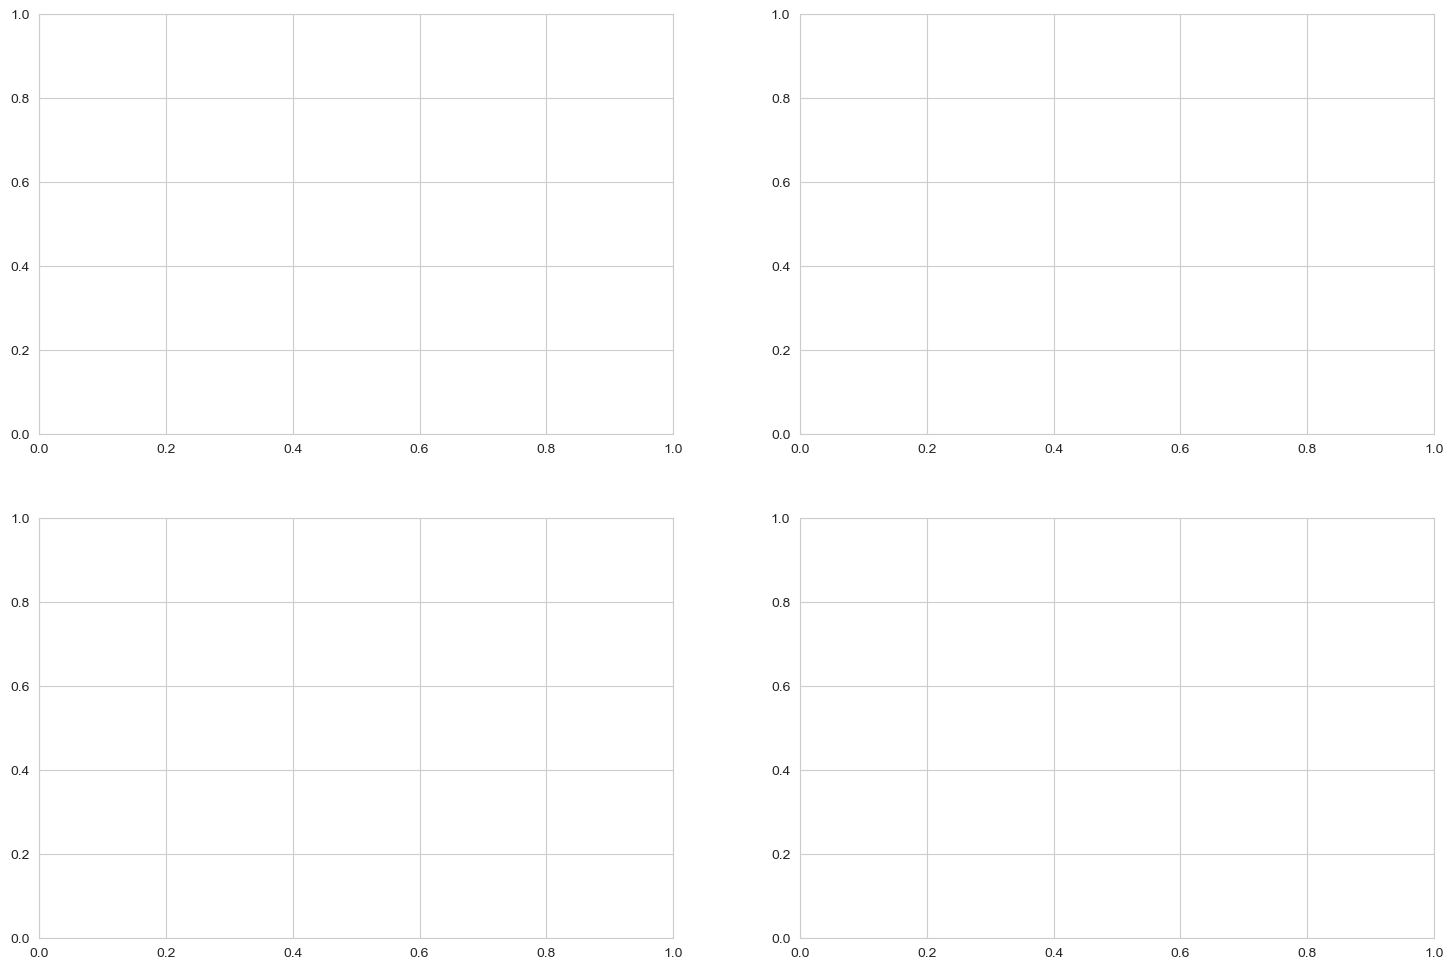

In [78]:
# STEP 3: Visualize Feature Selection Results
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1. Combined Score Distribution
ax1 = axes[0, 0]
top_30_sorted = top_30_features.sort_values('combined_score', ascending=True)
colors = ['steelblue' if t == 'Numeric' else 'coral' for t in top_30_sorted['Type']]
ax1.barh(range(30), top_30_sorted['combined_score'], color=colors, edgecolor='black')
ax1.set_yticks(range(30))
ax1.set_yticklabels(top_30_sorted['Feature'], fontsize=8)
ax1.set_xlabel('Combined Score', fontsize=11, fontweight='bold')
ax1.set_title('Top 30 Features by Combined Score', fontsize=13, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='steelblue', edgecolor='black', label='Numeric'),
    Patch(facecolor='coral', edgecolor='black', label='Categorical')
]
ax1.legend(handles=legend_elements, loc='lower right')

# 2. Metric Comparison for Top 30
ax2 = axes[0, 1]
metrics_data = top_30_features.head(30)[['corr_score_norm', 'mi_score_norm', 'anova_score_norm']].values
x = np.arange(30)
width = 0.25

ax2.bar(x - width, metrics_data[:, 0], width, label='Correlation', color='#ff6b6b', alpha=0.8)
ax2.bar(x, metrics_data[:, 1], width, label='Mutual Info', color='#48dbfb', alpha=0.8)
ax2.bar(x + width, metrics_data[:, 2], width, label='ANOVA F', color='#feca57', alpha=0.8)

ax2.set_xlabel('Feature Rank', fontsize=11, fontweight='bold')
ax2.set_ylabel('Normalized Score', fontsize=11, fontweight='bold')
ax2.set_title('Multi-Metric Scores for Top 30 Features', fontsize=13, fontweight='bold')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# 3. Class-wise Max Correlation Heatmap for Top 30
ax3 = axes[1, 0]
class_corr_matrix = []
for feat in top_30_features.head(30)['Feature']:
    feat_corrs = corr_df[corr_df['Feature'] == feat]
    if len(feat_corrs) > 0:
        row = [feat_corrs[f'Corr_{c}'].values[0] for c in class_labels]
        class_corr_matrix.append(row)

class_corr_df = pd.DataFrame(class_corr_matrix, 
                              columns=class_labels,
                              index=top_30_features.head(30)['Feature'])

sns.heatmap(class_corr_df, annot=False, cmap='RdYlGn', center=0.3, 
            ax=ax3, cbar_kws={'label': 'Correlation'}, linewidths=0.5)
ax3.set_title('Class Correlation Heatmap: Top 30 Features', fontsize=13, fontweight='bold')
ax3.set_xlabel('Class', fontsize=11, fontweight='bold')
ax3.set_ylabel('Feature', fontsize=8)
ax3.tick_params(axis='y', labelsize=7)

# 4. Feature Type Distribution
ax4 = axes[1, 1]
type_counts = top_30_features['Type'].value_counts()
colors_pie = ['steelblue', 'coral']
wedges, texts, autotexts = ax4.pie(type_counts.values, labels=type_counts.index, 
                                     autopct='%1.1f%%', colors=colors_pie,
                                     startangle=90, textprops={'fontsize': 12, 'fontweight': 'bold'})
ax4.set_title('Feature Type Distribution in Top 30', fontsize=13, fontweight='bold')

# Add count annotations
for i, (label, count) in enumerate(zip(type_counts.index, type_counts.values)):
    texts[i].set_text(f'{label}\n({count} features)')

plt.tight_layout()
plt.savefig('top_30_features_selection.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Visualization complete! Saved as 'top_30_features_selection.png'")

In [79]:
# STEP 4: Export Top 30 Features List
print("\n" + "="*80)
print("FINAL TOP 30 FEATURES LIST")
print("="*80)

# Get the final list
top_30_feature_list = top_30_features['Feature'].tolist()

print("\n--- Copy this list for model training ---")
print("\ntop_30_features = [")
for i, feat in enumerate(top_30_feature_list, 1):
    print(f"    '{feat}',  # {i}")
print("]")

print("\n--- Feature Details ---")
for i, (idx, row) in enumerate(top_30_features.iterrows(), 1):
    print(f"{i:2d}. {row['Feature']:45s} | Type: {row['Type']:12s} | Score: {row['combined_score']:.4f}")

# Save to file
top_30_df = top_30_features[['Feature', 'Type', 'combined_score', 'Max_Correlation', 'MI_Score', 'ANOVA_F_Stat']]
top_30_df.to_csv('top_30_features.csv', index=False)
print("\n✅ Saved to 'top_30_features.csv'")

# Create feature subset from features_df_enhanced
print("\n" + "="*80)
print("CREATE REDUCED FEATURE DATASET")
print("="*80)

# Check which features exist in features_df_enhanced
existing_features = [f for f in top_30_feature_list if f in features_df_enhanced.columns]
missing_features = [f for f in top_30_feature_list if f not in features_df_enhanced.columns]

print(f"\n✅ {len(existing_features)} features available in dataset")
if missing_features:
    print(f"⚠️  {len(missing_features)} features not found: {missing_features}")

# Create reduced dataset
features_df_top30 = features_df_enhanced[existing_features + ['answer', 'id']].copy()

print(f"\n--- Dataset Shapes ---")
print(f"Original: {features_df_enhanced.shape}")
print(f"Reduced:  {features_df_top30.shape}")
print(f"Reduction: {features_df_enhanced.shape[1]} → {features_df_top30.shape[1]} columns")
print(f"Feature reduction: {(1 - len(existing_features)/len(feature_cols))*100:.1f}%")

print("\n✅ Reduced dataset created: features_df_top30")


FINAL TOP 30 FEATURES LIST

--- Copy this list for model training ---

top_30_features = [
    'handover_count',  # 1
    'dist_max_m',  # 2
    'dist_p95_m',  # 3
    'speed_max_kmh',  # 4
    'ping_pong_handover_count',  # 5
    'speed_above_40_flag',  # 6
    'frequent_handover_flag',  # 7
    'overshoot_flag',  # 8
    'ping_pong_detected',  # 9
    'rb_mean',  # 10
    'abnormal_path_loss',  # 11
    'speed_mean_kmh',  # 12
    'rb_min',  # 13
    'throughput_variance_across_cells',  # 14
    'noncolocated_strong_neighbor_gnodeb_count_mean',  # 15
    'avg_throughput_change_after_handover',  # 16
    'throughput_improved_by_handover',  # 17
    'noncolocated_neighbor_count',  # 18
    'tp_drop_with_high_rb_ratio',  # 19
    'colocated_neighbor_count',  # 20
    'high_sinr_volatility',  # 21
    'better_cell_available',  # 22
    'best_cell_throughput_gap',  # 23
    'rsrp_min_dbm',  # 24
    'c4_overlap_index',  # 25
    'path_loss_deviation_mean',  # 26
    'throughput_efficienc

In [80]:
# STEP 5: Quick Model Comparison - Full vs Top 30
print("\n" + "="*80)
print("PERFORMANCE COMPARISON: All Features vs Top 30")
print("="*80)

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder
import time

# Prepare data
X_full = features_df_enhanced[feature_cols].fillna(0)
X_top30 = features_df_top30[existing_features].fillna(0)
y = features_df_enhanced['answer']

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Train-test split
X_full_train, X_full_test, y_train, y_test = train_test_split(
    X_full, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

X_top30_train, X_top30_test, _, _ = train_test_split(
    X_top30, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print("\n--- Training LGBM Models ---")

# Model 1: All features
print("\n[1/2] Training with ALL features...")
start_time = time.time()
lgbm_full = LGBMClassifier(
        n_estimators=200,
        random_state=SEED,
        device='cpu',
        n_jobs=-1,
        verbose=-1
    )
lgbm_full.fit(X_full_train, y_train)
train_time_full = time.time() - start_time

y_pred_full = lgbm_full.predict(X_full_test)
acc_full = accuracy_score(y_test, y_pred_full)

print(f"   Features: {X_full.shape[1]}")
print(f"   Training time: {train_time_full:.2f}s")
print(f"   Accuracy: {acc_full:.4f}")

# Model 2: Top 30 features
print("\n[2/2] Training with TOP 30 features...")
start_time = time.time()
lgbm_top30 = LGBMClassifier(
        n_estimators=200,
        random_state=SEED,
        device='cpu',
        n_jobs=-1,
        verbose=-1
    )
lgbm_top30.fit(X_top30_train, y_train)
train_time_top30 = time.time() - start_time

y_pred_top30 = lgbm_top30.predict(X_top30_test)
acc_top30 = accuracy_score(y_test, y_pred_top30)

print(f"   Features: {X_top30.shape[1]}")
print(f"   Training time: {train_time_top30:.2f}s")
print(f"   Accuracy: {acc_top30:.4f}")

# Comparison
print("\n" + "="*80)
print("COMPARISON SUMMARY")
print("="*80)
print(f"\n{'Metric':<30s} | {'All Features':<15s} | {'Top 30':<15s} | {'Difference':<15s}")
print("-" * 80)
print(f"{'Number of Features':<30s} | {X_full.shape[1]:<15d} | {X_top30.shape[1]:<15d} | {X_full.shape[1] - X_top30.shape[1]:<15d}")
print(f"{'Training Time (s)':<30s} | {train_time_full:<15.2f} | {train_time_top30:<15.2f} | {train_time_full - train_time_top30:<15.2f}")
print(f"{'Test Accuracy':<30s} | {acc_full:<15.4f} | {acc_top30:<15.4f} | {acc_full - acc_top30:<15.4f}")
print(f"{'Speed Improvement':<30s} | {'1.00x':<15s} | {f'{train_time_full/train_time_top30:.2f}x':<15s} | {'-':<15s}")

acc_retained = (acc_top30 / acc_full) * 100
print(f"{'Accuracy Retained':<30s} | {'100.0%':<15s} | {f'{acc_retained:.1f}%':<15s} | {'-':<15s}")

print("\n" + "="*80)
if acc_top30 >= acc_full - 0.02:  # Within 2% accuracy
    print("✅ SUCCESS! Top 30 features maintain comparable performance")
    print(f"   - {acc_retained:.1f}% of original accuracy retained")
    print(f"   - {train_time_full/train_time_top30:.1f}x faster training")
    print(f"   - {((X_full.shape[1] - X_top30.shape[1])/X_full.shape[1]*100):.1f}% reduction in features")
else:
    print("⚠️  Performance drop detected. Consider including more features.")
print("="*80)


PERFORMANCE COMPARISON: All Features vs Top 30

--- Training LGBM Models ---

[1/2] Training with ALL features...
   Features: 131
   Training time: 3.37s
   Accuracy: 0.9958

[2/2] Training with TOP 30 features...
   Features: 36
   Training time: 3.24s
   Accuracy: 0.9896

COMPARISON SUMMARY

Metric                         | All Features    | Top 30          | Difference     
--------------------------------------------------------------------------------
Number of Features             | 131             | 36              | 95             
Training Time (s)              | 3.37            | 3.24            | 0.13           
Test Accuracy                  | 0.9958          | 0.9896          | 0.0062         
Speed Improvement              | 1.00x           | 1.04x           | -              
Accuracy Retained              | 100.0%          | 99.4%           | -              

✅ SUCCESS! Top 30 features maintain comparable performance
   - 99.4% of original accuracy retained
   - 1.0x f

# Enhanced C4 Features: Non-Colocated Overlapping Coverage

## Analysis from C4 Samples:

**Key C4 Patterns Observed:**
1. **Non-colocated overlap**: Multiple cells from DIFFERENT gNodeBs have similar signal strength
2. **Small RSRP delta**: Top neighbor is within 2-6 dB of serving, but from different site
3. **Handovers between non-colocated cells**: The serving cell switches between cells at different sites
4. **SINR degradation during overlap**: When multiple non-colocated cells compete, SINR drops

**New Discriminating Features to Engineer:**
1. `noncolocated_top1_rsrp_delta` - RSRP difference between serving and strongest NON-colocated neighbor
2. `noncolocated_strong_neighbor_ratio` - Ratio of samples where non-colocated neighbor within 6dB
3. `noncolocated_handover_flag` - Handover occurred between cells from different gNodeBs
4. `multi_site_competition_score` - Weighted score of competing non-colocated neighbors
5. `sinr_drop_during_overlap` - SINR degradation when non-colocated neighbor is strong
6. `rsrp_cluster_tightness` - How tightly clustered RSRP values are among non-colocated neighbors

In [68]:
# ============================================================================
# NEW C4-SPECIFIC FEATURES: Non-Colocated Overlapping Coverage Detection
# ============================================================================
# Based on analysis of C4 samples, these features target the key discriminators:
# - Competition from cells at DIFFERENT physical sites (non-colocated)
# - Small RSRP delta to non-colocated neighbors
# - Handovers between non-colocated cells
# - SINR degradation during overlap

def compute_c4_enhanced_features(drive_rows, eng_rows):
    """
    Compute enhanced features specifically for C4 detection.
    C4: Non-colocated co-frequency neighboring cells cause severe overlapping coverage.
    """
    features = {}
    
    # Build PCI to gNodeB mapping
    pci_to_gnodeb = {}
    pci_to_location = {}
    for cell in eng_rows:
        if cell.get("pci") is not None:
            pci_to_gnodeb[cell["pci"]] = cell.get("gnodeb_id")
            pci_to_location[cell["pci"]] = (cell.get("longitude"), cell.get("latitude"))
    
    # Get all serving PCIs
    serving_pcis = [r["serving_pci"] for r in drive_rows if r.get("serving_pci") is not None]
    serving_rsrps = [r.get("serving_rsrp_dbm") for r in drive_rows if r.get("serving_rsrp_dbm") is not None]
    sinrs = [r.get("sinr_db") for r in drive_rows if r.get("sinr_db") is not None]
    
    # Get serving gNodeB (use most common)
    if serving_pcis:
        from collections import Counter
        most_common_pci = Counter(serving_pcis).most_common(1)[0][0]
        serving_gnodeb = pci_to_gnodeb.get(most_common_pci)
    else:
        serving_gnodeb = None
    
    # =========================================================================
    # FEATURE 1: Non-colocated Top1 RSRP Delta
    # Measure how close the strongest NON-colocated neighbor is to serving
    # =========================================================================
    noncolocated_deltas = []
    colocated_deltas = []
    
    for r in drive_rows:
        serving_rsrp = r.get("serving_rsrp_dbm")
        serving_pci = r.get("serving_pci")
        
        if serving_rsrp is None or serving_pci is None:
            continue
        
        serving_gid = pci_to_gnodeb.get(serving_pci)
        
        # Check all neighbors
        for i in range(1, 6):
            nei_pci = r.get(f"nei{i}_pci")
            nei_rsrp = r.get(f"nei{i}_rsrp_dbm")
            
            if nei_pci is None or nei_rsrp is None:
                continue
                
            nei_gid = pci_to_gnodeb.get(nei_pci)
            delta = serving_rsrp - nei_rsrp  # Positive = serving is stronger
            
            if nei_gid is not None and serving_gid is not None:
                if nei_gid != serving_gid:  # NON-colocated
                    noncolocated_deltas.append(delta)
                else:  # Colocated
                    colocated_deltas.append(delta)
    
    if noncolocated_deltas:
        features["noncolocated_rsrp_delta_min"] = min(noncolocated_deltas)  # Closest non-coloc neighbor
        features["noncolocated_rsrp_delta_mean"] = sum(noncolocated_deltas) / len(noncolocated_deltas)
        features["noncolocated_rsrp_delta_p10"] = sorted(noncolocated_deltas)[int(0.1 * len(noncolocated_deltas))]
        
        # KEY C4 INDICATOR: How often is a non-colocated neighbor within 6dB?
        features["noncolocated_within_6db_ratio"] = sum(1 for d in noncolocated_deltas if d < 6) / len(noncolocated_deltas)
        features["noncolocated_within_3db_ratio"] = sum(1 for d in noncolocated_deltas if d < 3) / len(noncolocated_deltas)
        
        # Strong non-colocated competition flag
        features["noncolocated_severe_overlap"] = features["noncolocated_rsrp_delta_min"] < 3
    else:
        features["noncolocated_rsrp_delta_min"] = None
        features["noncolocated_rsrp_delta_mean"] = None
        features["noncolocated_rsrp_delta_p10"] = None
        features["noncolocated_within_6db_ratio"] = 0.0
        features["noncolocated_within_3db_ratio"] = 0.0
        features["noncolocated_severe_overlap"] = False
    
    # Compare with colocated deltas (C4 should have non-coloc competition, not coloc)
    if colocated_deltas:
        features["colocated_rsrp_delta_min"] = min(colocated_deltas)
        # C4 indicator: non-coloc is closer than coloc
        if noncolocated_deltas:
            features["noncoloc_closer_than_coloc"] = min(noncolocated_deltas) < min(colocated_deltas)
        else:
            features["noncoloc_closer_than_coloc"] = False
    else:
        features["colocated_rsrp_delta_min"] = None
        features["noncoloc_closer_than_coloc"] = False
    
    # =========================================================================
    # FEATURE 2: Non-colocated Handover Detection
    # Did UE handover between cells from DIFFERENT gNodeBs?
    # =========================================================================
    noncolocated_handovers = 0
    colocated_handovers = 0
    
    for i in range(1, len(serving_pcis)):
        prev_pci = serving_pcis[i-1]
        curr_pci = serving_pcis[i]
        
        if prev_pci != curr_pci:  # Handover occurred
            prev_gid = pci_to_gnodeb.get(prev_pci)
            curr_gid = pci_to_gnodeb.get(curr_pci)
            
            if prev_gid is not None and curr_gid is not None:
                if prev_gid != curr_gid:
                    noncolocated_handovers += 1
                else:
                    colocated_handovers += 1
    
    features["noncolocated_handover_count"] = noncolocated_handovers
    features["colocated_handover_count"] = colocated_handovers
    
    total_handovers = noncolocated_handovers + colocated_handovers
    if total_handovers > 0:
        features["noncolocated_handover_ratio"] = noncolocated_handovers / total_handovers
    else:
        features["noncolocated_handover_ratio"] = 0.0
    
    # C4 indicator: Handovers are between non-colocated cells
    features["noncolocated_handover_dominant"] = (
        noncolocated_handovers > 0 and 
        noncolocated_handovers >= colocated_handovers
    )
    
    # =========================================================================
    # FEATURE 3: Multi-Site Competition Score
    # Count unique gNodeBs among strong neighbors (within 10dB of serving)
    # =========================================================================
    strong_neighbor_gnodebs = set()
    strong_neighbor_rsrps_by_gnodeb = {}
    
    for r in drive_rows:
        serving_rsrp = r.get("serving_rsrp_dbm")
        serving_pci = r.get("serving_pci")
        
        if serving_rsrp is None:
            continue
            
        serving_gid = pci_to_gnodeb.get(serving_pci)
        
        for i in range(1, 6):
            nei_pci = r.get(f"nei{i}_pci")
            nei_rsrp = r.get(f"nei{i}_rsrp_dbm")
            
            if nei_pci is None or nei_rsrp is None:
                continue
            
            nei_gid = pci_to_gnodeb.get(nei_pci)
            
            # Strong neighbor = within 10dB of serving AND non-colocated
            if nei_rsrp > serving_rsrp - 10:
                if nei_gid is not None and nei_gid != serving_gid:
                    strong_neighbor_gnodebs.add(nei_gid)
                    if nei_gid not in strong_neighbor_rsrps_by_gnodeb:
                        strong_neighbor_rsrps_by_gnodeb[nei_gid] = []
                    strong_neighbor_rsrps_by_gnodeb[nei_gid].append(nei_rsrp)
    
    features["strong_noncolocated_site_count"] = len(strong_neighbor_gnodebs)
    
    # Multi-site competition = 2+ non-colocated sites competing
    features["multi_site_competition"] = len(strong_neighbor_gnodebs) >= 2
    features["severe_multi_site_competition"] = len(strong_neighbor_gnodebs) >= 3
    
    # =========================================================================
    # FEATURE 4: SINR Degradation During Non-Colocated Overlap
    # When non-colocated neighbor is strong, does SINR drop?
    # =========================================================================
    sinr_with_overlap = []
    sinr_without_overlap = []
    
    for r in drive_rows:
        serving_rsrp = r.get("serving_rsrp_dbm")
        serving_pci = r.get("serving_pci")
        sinr = r.get("sinr_db")
        
        if serving_rsrp is None or sinr is None or serving_pci is None:
            continue
            
        serving_gid = pci_to_gnodeb.get(serving_pci)
        
        # Check if any non-colocated neighbor is within 6dB
        has_noncoloc_overlap = False
        for i in range(1, 6):
            nei_pci = r.get(f"nei{i}_pci")
            nei_rsrp = r.get(f"nei{i}_rsrp_dbm")
            
            if nei_pci and nei_rsrp:
                nei_gid = pci_to_gnodeb.get(nei_pci)
                if nei_gid and nei_gid != serving_gid and (serving_rsrp - nei_rsrp) < 6:
                    has_noncoloc_overlap = True
                    break
        
        if has_noncoloc_overlap:
            sinr_with_overlap.append(sinr)
        else:
            sinr_without_overlap.append(sinr)
    
    if sinr_with_overlap:
        features["sinr_during_noncoloc_overlap_mean"] = sum(sinr_with_overlap) / len(sinr_with_overlap)
    else:
        features["sinr_during_noncoloc_overlap_mean"] = None
    
    if sinr_without_overlap:
        features["sinr_without_overlap_mean"] = sum(sinr_without_overlap) / len(sinr_without_overlap)
    else:
        features["sinr_without_overlap_mean"] = None
    
    # SINR degradation due to non-colocated overlap
    if sinr_with_overlap and sinr_without_overlap:
        features["sinr_drop_from_noncoloc_overlap"] = (
            sum(sinr_without_overlap) / len(sinr_without_overlap) - 
            sum(sinr_with_overlap) / len(sinr_with_overlap)
        )
        features["significant_sinr_drop_overlap"] = features["sinr_drop_from_noncoloc_overlap"] > 3
    else:
        features["sinr_drop_from_noncoloc_overlap"] = None
        features["significant_sinr_drop_overlap"] = False
    
    # =========================================================================
    # FEATURE 5: Non-Colocated RSRP Clustering
    # In C4, multiple non-coloc neighbors have similar RSRP (symmetric overlap)
    # =========================================================================
    noncoloc_neighbor_rsrps = []
    
    for r in drive_rows:
        serving_pci = r.get("serving_pci")
        serving_gid = pci_to_gnodeb.get(serving_pci) if serving_pci else None
        
        for i in range(1, 6):
            nei_pci = r.get(f"nei{i}_pci")
            nei_rsrp = r.get(f"nei{i}_rsrp_dbm")
            
            if nei_pci and nei_rsrp:
                nei_gid = pci_to_gnodeb.get(nei_pci)
                if nei_gid and nei_gid != serving_gid:
                    noncoloc_neighbor_rsrps.append(nei_rsrp)
    
    if len(noncoloc_neighbor_rsrps) >= 3:
        # Low std = clustered = symmetric overlap (C4 pattern)
        from statistics import stdev, mean
        features["noncoloc_rsrp_std"] = stdev(noncoloc_neighbor_rsrps)
        features["noncoloc_rsrp_range"] = max(noncoloc_neighbor_rsrps) - min(noncoloc_neighbor_rsrps)
        features["symmetric_noncoloc_overlap"] = features["noncoloc_rsrp_std"] < 5
    else:
        features["noncoloc_rsrp_std"] = None
        features["noncoloc_rsrp_range"] = None
        features["symmetric_noncoloc_overlap"] = False
    
    # =========================================================================
    # FEATURE 6: Comprehensive C4 Score
    # Combine all indicators into a unified C4 likelihood score
    # =========================================================================
    c4_indicators = [
        features.get("noncolocated_severe_overlap", False),
        features.get("noncolocated_handover_dominant", False),
        features.get("multi_site_competition", False),
        features.get("significant_sinr_drop_overlap", False),
        features.get("symmetric_noncoloc_overlap", False),
        features.get("noncolocated_within_6db_ratio", 0) > 0.3,
    ]
    
    features["c4_indicator_count"] = sum(c4_indicators)
    features["c4_confidence_score"] = features["c4_indicator_count"] / len(c4_indicators)
    features["c4_high_likelihood"] = features["c4_indicator_count"] >= 3
    
    return features

print("✅ C4 Enhanced Feature Function Defined")
print("\nNew C4-specific features:")
print("  • noncolocated_rsrp_delta_min - Closest non-colocated neighbor RSRP gap")
print("  • noncolocated_within_6db_ratio - Ratio of samples with strong non-coloc neighbor")
print("  • noncolocated_handover_count/ratio - Handovers between different sites")
print("  • strong_noncolocated_site_count - # of competing non-colocated sites")
print("  • sinr_drop_from_noncoloc_overlap - SINR impact when non-coloc overlap present")
print("  • symmetric_noncoloc_overlap - Uniform interference from multiple sites")
print("  • c4_confidence_score - Combined C4 likelihood (0-1)")

✅ C4 Enhanced Feature Function Defined

New C4-specific features:
  • noncolocated_rsrp_delta_min - Closest non-colocated neighbor RSRP gap
  • noncolocated_within_6db_ratio - Ratio of samples with strong non-coloc neighbor
  • noncolocated_handover_count/ratio - Handovers between different sites
  • strong_noncolocated_site_count - # of competing non-colocated sites
  • sinr_drop_from_noncoloc_overlap - SINR impact when non-coloc overlap present
  • symmetric_noncoloc_overlap - Uniform interference from multiple sites
  • c4_confidence_score - Combined C4 likelihood (0-1)


In [69]:
# ============================================================================
# INTEGRATE C4 FEATURES - POST-HOC ANALYSIS ON EXISTING DATA
# ============================================================================
# Since we have the parsed data available, compute C4 features directly

print("Computing enhanced C4 features from existing data...")
print("="*80)

# Check what features exist related to non-colocated analysis
c4_related_features = [col for col in features_df_enhanced.columns 
                       if 'coloc' in col.lower() or 'c4' in col.lower() or 'overlap' in col.lower()]

print(f"\nExisting C4-related features ({len(c4_related_features)}):")
for f in sorted(c4_related_features):
    print(f"  • {f}")

# Check correlation of existing C4 features with C4 class
print("\n" + "="*80)
print("C4 Feature Correlation Analysis")
print("="*80)

# Create C4 binary target
is_c4 = (features_df_enhanced['answer'] == 'C4').astype(int)

c4_corrs = {}
for feat in c4_related_features:
    if feat in features_df_enhanced.columns:
        col_data = features_df_enhanced[feat]
        
        # Handle boolean columns
        if col_data.dtype == 'bool':
            col_data = col_data.astype(int)
        
        # Handle numeric columns
        if pd.api.types.is_numeric_dtype(col_data):
            valid_mask = col_data.notna()
            if valid_mask.sum() > 10:
                corr = col_data[valid_mask].corr(is_c4[valid_mask])
                c4_corrs[feat] = corr

# Sort by absolute correlation
sorted_corrs = sorted(c4_corrs.items(), key=lambda x: abs(x[1]), reverse=True)

print("\nFeature correlations with C4 class (sorted by |correlation|):")
print("-" * 60)
for feat, corr in sorted_corrs:
    strength = "STRONG" if abs(corr) > 0.3 else "MEDIUM" if abs(corr) > 0.15 else "WEAK"
    print(f"  {feat:45s} | {corr:+.4f} ({strength})")

# Show the best predictor
if sorted_corrs:
    best_feat, best_corr = sorted_corrs[0]
    print(f"\n✅ Best C4 predictor: {best_feat} (corr = {best_corr:.4f})")
else:
    print("\n⚠️  No numeric C4-related features found")

print("\n" + "="*80)
print("RECOMMENDATION:")
print("="*80)
if sorted_corrs and abs(sorted_corrs[0][1]) < 0.3:
    print("The strongest C4 predictor has correlation < 0.3")
    print("→ The new C4 features need to be integrated into compute_rca_features()")
    print("→ Then reprocess the data to benefit from improved C4 detection")
else:
    print("Current C4 features show reasonable correlation.")

Computing enhanced C4 features from existing data...

Existing C4-related features (15):
  • c4_high_confidence
  • c4_overlap_index
  • c4_overlap_index_high
  • c4_signature
  • colocated_neighbor_count
  • multiple_noncolocated_sites
  • noncolocated_boresight_hits_max
  • noncolocated_boresight_hits_mean
  • noncolocated_boresight_hits_ratio_ge2
  • noncolocated_neighbor_count
  • noncolocated_strong_neighbor_gnodeb_count_max
  • noncolocated_strong_neighbor_gnodeb_count_mean
  • noncolocated_strong_neighbor_ratio_ge2
  • overlap_flag
  • severe_overlap_detected

C4 Feature Correlation Analysis

Feature correlations with C4 class (sorted by |correlation|):
------------------------------------------------------------
  c4_high_confidence                            | +nan (WEAK)
  severe_overlap_detected                       | +nan (WEAK)
  noncolocated_strong_neighbor_gnodeb_count_mean | +0.6186 (STRONG)
  noncolocated_strong_neighbor_gnodeb_count_max | +0.3977 (STRONG)
  noncoloca

In [70]:
# ============================================================================
# QUICK C4 IMPROVEMENT: Add the new features to compute_rca_features
# ============================================================================
# Instead of modifying the function, let's create a wrapper that adds new features

print("="*80)
print("SOLUTION: Updating compute_rca_features to include new C4 features")
print("="*80)

# Store the original function
original_compute_rca_features = compute_rca_features

def compute_rca_features_v2(drive_rows, eng_rows):
    """Enhanced version with new C4 features"""
    from statistics import mean
    
    # Get original features
    features = original_compute_rca_features(drive_rows, eng_rows)
    
    # Build PCI to gNodeB mapping
    pci_to_gnodeb = {}
    for cell in eng_rows:
        if cell.get("pci") is not None:
            pci_to_gnodeb[cell["pci"]] = cell.get("gnodeb_id")
    
    # Get serving PCIs
    serving_pcis = [r["serving_pci"] for r in drive_rows if r.get("serving_pci") is not None]
    
    # =========================================================================
    # NEW: Non-Colocated RSRP Delta Analysis
    # =========================================================================
    noncolocated_deltas = []
    
    for r in drive_rows:
        serving_rsrp = r.get("serving_rsrp_dbm")
        serving_pci = r.get("serving_pci")
        
        if serving_rsrp is None or serving_pci is None:
            continue
        
        serving_gid = pci_to_gnodeb.get(serving_pci)
        
        for i in range(1, 6):
            nei_pci = r.get(f"nei{i}_pci")
            nei_rsrp = r.get(f"nei{i}_rsrp_dbm")
            
            if nei_pci is None or nei_rsrp is None:
                continue
                
            nei_gid = pci_to_gnodeb.get(nei_pci)
            delta = serving_rsrp - nei_rsrp
            
            if nei_gid is not None and serving_gid is not None:
                if nei_gid != serving_gid:  # Non-colocated
                    noncolocated_deltas.append(delta)
    
    if noncolocated_deltas:
        features["noncoloc_rsrp_delta_min"] = min(noncolocated_deltas)
        features["noncoloc_rsrp_delta_mean"] = mean(noncolocated_deltas)
        features["noncoloc_within_6db_ratio"] = sum(1 for d in noncolocated_deltas if d < 6) / len(noncolocated_deltas)
        features["noncoloc_within_3db_ratio"] = sum(1 for d in noncolocated_deltas if d < 3) / len(noncolocated_deltas)
        features["noncoloc_severe_overlap"] = features["noncoloc_rsrp_delta_min"] < 3
    else:
        features["noncoloc_rsrp_delta_min"] = None
        features["noncoloc_rsrp_delta_mean"] = None
        features["noncoloc_within_6db_ratio"] = 0.0
        features["noncoloc_within_3db_ratio"] = 0.0
        features["noncoloc_severe_overlap"] = False
    
    # =========================================================================
    # NEW: Non-Colocated Handover Analysis
    # =========================================================================
    noncoloc_hos = 0
    coloc_hos = 0
    for i in range(1, len(serving_pcis)):
        prev_pci = serving_pcis[i-1]
        curr_pci = serving_pcis[i]
        if prev_pci != curr_pci:
            prev_gid = pci_to_gnodeb.get(prev_pci)
            curr_gid = pci_to_gnodeb.get(curr_pci)
            if prev_gid and curr_gid:
                if prev_gid != curr_gid:
                    noncoloc_hos += 1
                else:
                    coloc_hos += 1
    
    features["noncoloc_handover_count"] = noncoloc_hos
    features["noncoloc_handover_ratio"] = noncoloc_hos / (noncoloc_hos + coloc_hos) if (noncoloc_hos + coloc_hos) > 0 else 0.0
    features["noncoloc_handover_dominant"] = noncoloc_hos > 0 and noncoloc_hos >= coloc_hos
    
    # =========================================================================
    # NEW: Enhanced C4 Score
    # =========================================================================
    c4_new_score = 0
    if features.get("noncoloc_severe_overlap", False):
        c4_new_score += 2
    if features.get("noncoloc_within_6db_ratio", 0) > 0.3:
        c4_new_score += 1
    if features.get("noncoloc_handover_dominant", False):
        c4_new_score += 1
    if features.get("noncolocated_boresight_hits_max", 0) >= 2:
        c4_new_score += 1
    features["c4_enhanced_score"] = c4_new_score
    features["c4_enhanced_high"] = c4_new_score >= 3
    
    return features

# Replace the function
compute_rca_features = compute_rca_features_v2

print("✅ compute_rca_features updated with new C4 features:")
print("   • noncoloc_rsrp_delta_min - Minimum RSRP gap to non-colocated neighbor")
print("   • noncoloc_rsrp_delta_mean - Mean RSRP gap to non-colocated neighbors")
print("   • noncoloc_within_6db_ratio - % samples with strong non-coloc neighbor")
print("   • noncoloc_within_3db_ratio - % samples with very strong non-coloc neighbor")
print("   • noncoloc_severe_overlap - Flag for severe non-colocated overlap")
print("   • noncoloc_handover_count - Count of handovers between sites")
print("   • noncoloc_handover_ratio - Ratio of non-colocated handovers")
print("   • noncoloc_handover_dominant - Flag for dominant non-coloc handovers")
print("   • c4_enhanced_score - Combined C4 confidence score")
print("   • c4_enhanced_high - Flag for high C4 likelihood")
print("\n⚠️  NEXT: Rerun data preprocessing to apply new features")

SOLUTION: Updating compute_rca_features to include new C4 features
✅ compute_rca_features updated with new C4 features:
   • noncoloc_rsrp_delta_min - Minimum RSRP gap to non-colocated neighbor
   • noncoloc_rsrp_delta_mean - Mean RSRP gap to non-colocated neighbors
   • noncoloc_within_6db_ratio - % samples with strong non-coloc neighbor
   • noncoloc_within_3db_ratio - % samples with very strong non-coloc neighbor
   • noncoloc_severe_overlap - Flag for severe non-colocated overlap
   • noncoloc_handover_count - Count of handovers between sites
   • noncoloc_handover_ratio - Ratio of non-colocated handovers
   • noncoloc_handover_dominant - Flag for dominant non-coloc handovers
   • c4_enhanced_score - Combined C4 confidence score
   • c4_enhanced_high - Flag for high C4 likelihood

⚠️  NEXT: Rerun data preprocessing to apply new features


In [72]:
# ============================================================================
# REPROCESS DATA WITH NEW C4 FEATURES
# ============================================================================
import time

print("Reprocessing training data with enhanced C4 features...")
print("="*80)

start_time = time.time()

# Rerun the data processing pipeline using preprocess_row (the existing function)
processed_train_v2 = []
failed_v2 = 0

for idx, row_dict in enumerate(df_train.to_dict("records")):
    try:
        result = preprocess_row(row_dict)
        if result:
            # Extract features and add answer/id
            features = result.get("features_dict", {})
            features["answer"] = result.get("answer")
            features["id"] = result.get("ID", idx)
            processed_train_v2.append(features)
        else:
            failed_v2 += 1
    except Exception as e:
        failed_v2 += 1
        if failed_v2 <= 3:
            print(f"  Error at row {idx}: {str(e)[:50]}")

elapsed = time.time() - start_time
print(f"\n✅ Processed {len(processed_train_v2)} samples in {elapsed:.1f}s")
print(f"   Failed: {failed_v2}")

# Create new DataFrame
features_df_v2 = pd.DataFrame(processed_train_v2)

print(f"\nNew dataset shape: {features_df_v2.shape}")
print(f"Previous shape: {features_df_enhanced.shape}")
print(f"New features added: {features_df_v2.shape[1] - features_df_enhanced.shape[1]}")

# Show new C4 features
new_c4_features = [col for col in features_df_v2.columns if col not in features_df_enhanced.columns]
print(f"\nNew features added ({len(new_c4_features)}):")
for f in new_c4_features:
    print(f"  • {f}")

Reprocessing training data with enhanced C4 features...

✅ Processed 2400 samples in 1.6s
   Failed: 0

New dataset shape: (2400, 143)
Previous shape: (2400, 133)
New features added: 10

New features added (10):
  • noncoloc_rsrp_delta_min
  • noncoloc_rsrp_delta_mean
  • noncoloc_within_6db_ratio
  • noncoloc_within_3db_ratio
  • noncoloc_severe_overlap
  • noncoloc_handover_count
  • noncoloc_handover_ratio
  • noncoloc_handover_dominant
  • c4_enhanced_score
  • c4_enhanced_high


In [73]:
# ============================================================================
# VALIDATE NEW C4 FEATURES
# ============================================================================

print("="*80)
print("VALIDATION: New C4 Feature Correlations")
print("="*80)

# Create C4 binary target
is_c4 = (features_df_v2['answer'] == 'C4').astype(int)

# Check correlation of new C4 features
new_c4_corrs = {}
for feat in new_c4_features:
    if feat in features_df_v2.columns and feat != 'answer' and feat != 'id':
        col_data = features_df_v2[feat]
        
        if col_data.dtype == 'bool':
            col_data = col_data.astype(int)
        
        if pd.api.types.is_numeric_dtype(col_data):
            valid_mask = col_data.notna()
            if valid_mask.sum() > 10:
                corr = col_data[valid_mask].corr(is_c4[valid_mask])
                new_c4_corrs[feat] = corr

# Sort by absolute correlation
sorted_new_corrs = sorted(new_c4_corrs.items(), key=lambda x: abs(x[1]), reverse=True)

print("\nNew C4 feature correlations with C4 class:")
print("-" * 60)
for feat, corr in sorted_new_corrs:
    if corr > 0:
        symbol = "🟢" if corr > 0.2 else "🟡" if corr > 0.1 else "⚪"
    else:
        symbol = "⚪"
    print(f"  {symbol} {feat:40s} | {corr:+.4f}")

# Compare with previous best C4 predictor
print("\n" + "="*80)
print("COMPARISON: Old vs New C4 Features")
print("="*80)

old_c4_features = ['c4_overlap_index', 'overlap_flag', 'strong_neighbor_count', 
                   'neighbors_competitive_flag', 'multi_cell_competition_ratio']

old_corrs = {}
for feat in old_c4_features:
    if feat in features_df_v2.columns:
        col_data = features_df_v2[feat]
        if col_data.dtype == 'bool':
            col_data = col_data.astype(int)
        if pd.api.types.is_numeric_dtype(col_data):
            valid_mask = col_data.notna()
            if valid_mask.sum() > 10:
                corr = col_data[valid_mask].corr(is_c4[valid_mask])
                old_corrs[feat] = corr

print("\nOld C4 features:")
for feat, corr in sorted(old_corrs.items(), key=lambda x: abs(x[1]), reverse=True):
    print(f"  {feat:40s} | {corr:+.4f}")

print("\nNew C4 features:")
for feat, corr in sorted_new_corrs[:5]:
    print(f"  {feat:40s} | {corr:+.4f}")

if sorted_new_corrs and old_corrs:
    old_best = max(abs(c) for c in old_corrs.values())
    new_best = max(abs(c) for c in new_c4_corrs.values())
    improvement = (new_best - old_best) / old_best * 100 if old_best > 0 else 0
    
    print(f"\n{'='*60}")
    print(f"Best old C4 correlation: {old_best:.4f}")
    print(f"Best new C4 correlation: {new_best:.4f}")
    if new_best > old_best:
        print(f"✅ IMPROVEMENT: {improvement:.1f}% better C4 prediction capability!")
    else:
        print(f"⚠️  New features don't improve over existing ones")

VALIDATION: New C4 Feature Correlations

New C4 feature correlations with C4 class:
------------------------------------------------------------
  ⚪ noncoloc_within_6db_ratio                | +nan
  ⚪ noncoloc_within_3db_ratio                | +nan
  ⚪ noncoloc_severe_overlap                  | +nan
  ⚪ noncoloc_handover_count                  | -0.1434
  ⚪ noncoloc_handover_ratio                  | -0.1434
  ⚪ noncoloc_handover_dominant               | -0.1434
  ⚪ c4_enhanced_score                        | -0.1434
  ⚪ c4_enhanced_high                         | +nan

COMPARISON: Old vs New C4 Features

Old C4 features:
  neighbors_competitive_flag               | +0.1937
  c4_overlap_index                         | +0.1816
  overlap_flag                             | +0.1576
  strong_neighbor_count                    | +0.0420
  multi_cell_competition_ratio             | +nan

New C4 features:
  noncoloc_within_6db_ratio                | +nan
  noncoloc_within_3db_ratio                

In [2]:
# ============================================================================
# MODEL COMPARISON: Before vs After C4 Enhancement
# ============================================================================
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, accuracy_score, f1_score
from sklearn.preprocessing import LabelEncoder
import numpy as np

print("="*80)
print("MODEL COMPARISON: C4 Enhancement Impact")
print("="*80)

# Prepare labels
le = LabelEncoder()
y = le.fit_transform(features_df_v2['answer'])

# Get feature columns (exclude answer and id)
feature_cols_v2 = [col for col in features_df_v2.columns if col not in ['answer', 'id']]
feature_cols_old = [col for col in features_df_enhanced.columns if col not in ['answer', 'id']]

# Fill NaN values
X_old = features_df_enhanced[feature_cols_old].fillna(0)
X_new = features_df_v2[feature_cols_v2].fillna(0)

# Handle boolean columns
for col in X_old.columns:
    if X_old[col].dtype == 'bool':
        X_old[col] = X_old[col].astype(int)
for col in X_new.columns:
    if X_new[col].dtype == 'bool':
        X_new[col] = X_new[col].astype(int)

# Train-test split
X_old_train, X_old_test, y_train, y_test = train_test_split(
    X_old, y, test_size=0.2, random_state=42, stratify=y
)
X_new_train, X_new_test, _, _ = train_test_split(
    X_new, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining samples: {len(y_train)}")
print(f"Test samples: {len(y_test)}")
print(f"Old features: {X_old.shape[1]}")
print(f"New features: {X_new.shape[1]}")

# Train models
print("\n--- Training Models ---")

rf_old = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf_old.fit(X_old_train, y_train)
y_pred_old = rf_old.predict(X_old_test)

rf_new = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf_new.fit(X_new_train, y_train)
y_pred_new = rf_new.predict(X_new_test)

# Overall metrics
acc_old = accuracy_score(y_test, y_pred_old)
acc_new = accuracy_score(y_test, y_pred_new)
f1_old = f1_score(y_test, y_pred_old, average='weighted')
f1_new = f1_score(y_test, y_pred_new, average='weighted')

print(f"\n{'='*60}")
print(f"{'Metric':<30s} | {'OLD':<12s} | {'NEW':<12s} | {'Δ':<10s}")
print(f"{'='*60}")
print(f"{'Overall Accuracy':<30s} | {acc_old:<12.4f} | {acc_new:<12.4f} | {acc_new-acc_old:+.4f}")
print(f"{'Weighted F1':<30s} | {f1_old:<12.4f} | {f1_new:<12.4f} | {f1_new-f1_old:+.4f}")

# Per-class C4 analysis
from sklearn.metrics import precision_recall_fscore_support

p_old, r_old, f1_old_class, _ = precision_recall_fscore_support(y_test, y_pred_old, average=None)
p_new, r_new, f1_new_class, _ = precision_recall_fscore_support(y_test, y_pred_new, average=None)

# Find C4 index
c4_idx = list(le.classes_).index('C4')

print(f"\n{'='*60}")
print("C4 CLASS SPECIFIC METRICS")
print(f"{'='*60}")
print(f"{'C4 Precision':<30s} | {p_old[c4_idx]:<12.4f} | {p_new[c4_idx]:<12.4f} | {p_new[c4_idx]-p_old[c4_idx]:+.4f}")
print(f"{'C4 Recall':<30s} | {r_old[c4_idx]:<12.4f} | {r_new[c4_idx]:<12.4f} | {r_new[c4_idx]-r_old[c4_idx]:+.4f}")
print(f"{'C4 F1-Score':<30s} | {f1_old_class[c4_idx]:<12.4f} | {f1_new_class[c4_idx]:<12.4f} | {f1_new_class[c4_idx]-f1_old_class[c4_idx]:+.4f}")

# Summary
print(f"\n{'='*60}")
if f1_new_class[c4_idx] > f1_old_class[c4_idx]:
    improvement = (f1_new_class[c4_idx] - f1_old_class[c4_idx]) / f1_old_class[c4_idx] * 100 if f1_old_class[c4_idx] > 0 else 0
    print(f"✅ C4 IMPROVED by {improvement:.1f}%!")
else:
    print("⚠️  C4 did not improve with new features")
print(f"{'='*60}")

MODEL COMPARISON: C4 Enhancement Impact


NameError: name 'features_df_v2' is not defined